<div style="text-align: center; margin-top: 80px; font-family: 'Times New Roman', serif;">

# **Data Mining Project Report**

### **Sherry Wang, Muhui Wang**

### **11/30/2025**

---

<div style="text-align: center; font-family: 'Times New Roman', serif; margin-top: 20px;">

<h3 style="font-weight: normal; font-size: 22px; line-height: 1.25;">

Analyzing Socioeconomic, Behavioral, and Clinical Determinants of Health Insurance Coverage and Hypertension Risk:
<p style="font-style: italic; font-size: 18px; margin-top: -8px;">
A Data Mining Project Based on NHANES 2021–2023
</p>
</div>

# Contents

**1. Introduction & Problem Statement**

**2. NHANES 2021–2023 Health Care Dataset Preprocessing**  
   2.1 Data Sources  
   2.2 Key Variables Extracted  
   2.3 Variable Renaming and Distinct Value Decode  
   2.4 Check the Data Quality  
   2.5 Handle the Missing Value  
   2.6 Handle the Outliers and Consistency Validation  

**3. Exploratory Data Analysis**  
   3.1 Demographics  
   3.2 Health indicators  
   3.3 Lifestyle  
   3.4 Insurance status  

**4. Association Rules**  
   4.1 Socioeconomic Patterns and Insurance Type   
   4.2 Multi-Domain Determinants & Hypertension
   4.3 Summary of Association Rule Findings  

**5. Classification** 
   5.1 Classification for Insurance Type
   5.2 Hypertension Classification Models  

**6. Clustering**  
   6.1 Study Objective  
   6.2 Feature Selection and Preprocessing  
   6.3 Determining the Number of Clusters  
   6.4 Cluster Summary Table  
   6.5 Cluster Size Distribution  
   6.7 Cluster Validity and Model Quality  
   6.8 Cluster Profiles  
   6.9 Cluster Interpretation  

**7. Conclusion**  
   7.1 Key Findings  
   7.2 Model Performance & Predictive Insights  
   7.3 Public Health Implications  
   7.4 Limitations  
   7.5 Future Directions

# 1. Introduction & Problem Statement
Health inequality remains a persistent challenge in the United States, where **disparities in income, education, and access to care** continue to influence both the availability and quality of **healthcare services**. Despite the expansion of health insurance coverage in recent years, variations in **insurance type**, such as public, private, dual, or none, reflect deeper **socioeconomic divisions**. These structural inequalities often shape individuals’ ability to **access preventive care, manage chronic diseases, and maintain overall well-being**. At the same time, **lifestyle behaviors** such as sleep, exercise, and smoking are known to interact with **social determinants**, jointly contributing to **disparities in chronic conditions** such as obesity, hypertension, and diabetes. Understanding how socioeconomic, behavioral, and health factors interact to produce these inequalities is crucial for improving both **healthcare access and health outcomes across diverse populations**.

This project aims to investigate **how socioeconomic characteristics, lifestyle factors, and physiological indicators collectively influence both health insurance coverage and hypertension risk**. Using data from the *National Health and Nutrition Examination Survey (NHANES) 2021–2023*, we employ data mining techniques to extract meaningful patterns, construct predictive models, and identify distinct health population profiles. By moving beyond descriptive analysis, this project seeks to uncover **interpretable relationships and predictive insights** that illuminate the **mechanisms linking socioeconomic disparities to health outcomes**. To achieve this aim, we define three main objectives:

- **First**, we aim to **identify underlying patterns between socioeconomic variables and insurance coverage types using association rule mining**. Specifically, we examine how combinations of income, education, and demographic characteristics are associated with insurance status (public, private, both, or uninsured). In parallel, we explore how behavioral and physiological factors, such as BMI and sleep duration, relate to chronic hypertension risk. Algorithms including **Apriori** will be utilized to generate interpretable association rules, evaluated through **Support, Confidence, and Lift metrics**.
- **Second**, we aim to **validate these findings and develop predictive models using a set of classification algorithms**. Two prediction tasks are defined:
**(1) predicting insurance type**; and **(2) predicting hypertension risk**.
We will implement and compare **Decision Tree**, **Random Forest**, and **XGBoost** classifiers. Model performance will be evaluated through standard metrics such as **Accuracy**, **Precision**, **Recall**, **F1-score**, **Feature importance**, **Confusion Matrix**, and **ROC-AUC**, testing the models’ ability to capture nonlinear and interactive effects that drive health outcomes.
- **Third**, we aim to **identify subpopulations with distinct health and lifestyle patterns using clustering analysis**. Through K-Prototypes, we seek to uncover meaningful population segments, such as “Healthy and Insured,” “At-Risk Publicly Insured,” or “Uninsured and Unhealthy.” Cluster quality will be assessed using the **Silhouette Score**, **Intra-cluster Variance**, and **Cluster Centroids**, facilitating interpretation of the overall population structure and highlighting groups that warrant targeted health interventions.

The potential applications of this research extend well beyond scientific understanding. The patterns and predictive insights derived from this project can inform public health initiatives and evidence-based policymaking, particularly in identifying uninsured or high-risk populations who could benefit from targeted health education, preventive care, or subsidized insurance programs. Moreover, the findings can assist healthcare providers and policymakers in designing more equitable intervention strategies and allocating resources more efficiently. By uncovering the data-driven mechanisms that underlie health disparities, this project contributes not only to the advancement of data science methodologies, but also to the broader societal goal of promoting fairness, inclusivity, and accessibility within healthcare systems.

# 2. NHANES 2021–2023 Health Care Dataset Preprocessing

## 2.1 Data Sources
- NHANES 2021–2023 official public dataset (17 SAS .XPT modules)
- Loaded and merged via SEQN (a unique sequence number)
- Final shape after merging: 11,933 × 154 variables

## 2.2 Key Variables Extracted
From 154 raw variables → reduced to 21 core analytical variables, including:
- **Demographics**: age, gender, race, education, income-poverty ratio
- **Health measures**: BMI, weight, height, SBP, DBP, A1C, glucose, diabetes status, doctor visit 12 month
- **Lifestyle**: smoking current, smoking ever, physical activity, sleep hours
- **Insurance status**: has health insurance and derived variable insurance_type (Private only /Public only/Both/Uninsured/Unknown) generated through aggregation

## 2.3 Variable Renaming and Distinct Value Decode
- All NHANES codebook variables were remapped to readable names
(e.g., `BMXBMI → bmi`, `LBXGH → a1c`, `SMQ020 → smoking_current`).
- Convert numeric codes into human-readable categories based on the official code dictionary
(e.g., education_map = { `1: "<9th grade"`, `2: "9-11th grade"`, `3: "High school/GED"`, `4: "Some college/AA"`,`5: "College graduate or above"`)

In [6]:
#datasets:https://wwwn.cdc.gov/nchs/nhanes/continuousnhanes/default.aspx?Cycle=2021-2023
#NHANES August 2021-August 2023

import pandas as pd
import numpy as np

path = "/Users/sherrywang/Desktop/Projects/Dataset"

demo = pd.read_sas(path + "/DEMO_L.XPT")
bmx  = pd.read_sas(path + "/BMX_L.XPT")
bpx  = pd.read_sas(path + "/BPXO_L.XPT")
lab  = pd.read_sas(path + "/GHB_L.XPT")
glu  = pd.read_sas(path + "/GLU_L.XPT")
smq  = pd.read_sas(path + "/SMQ_L.XPT")
paq  = pd.read_sas(path + "/PAQ_L.XPT")
slq  = pd.read_sas(path + "/SLQ_L.XPT")
diq  = pd.read_sas(path + "/DIQ_L.XPT")
inq  = pd.read_sas(path + "/INQ_L.XPT")
dbq  = pd.read_sas(path + "/DBQ_L.XPT")
hiq  = pd.read_sas(path + "/HIQ_L.XPT")
hsq  = pd.read_sas(path + "/HSQ_L.XPT")
huq  = pd.read_sas(path + "/HUQ_L.XPT")
ocq  = pd.read_sas(path + "/OCQ_L.XPT")
alq  = pd.read_sas(path + "/ALQ_L.XPT")
agp  = pd.read_sas(path + "/AGP_L.XPT")


dfs = [demo, bmx, bpx, lab, glu, smq, paq, slq, diq, inq, dbq, hiq, hsq, huq, ocq, alq, agp]

nhanes = dfs[0]
for t in dfs[1:]:
    nhanes = nhanes.merge(t, on="SEQN", how="left")
    
print(nhanes.head())
print(nhanes.shape)

for col in nhanes.columns:
#    print(col)

    cols_map = {
    "SEQN": "id",
    "RIDAGEYR": "age",
    "RIAGENDR": "gender",
    "RIDRETH3": "race",
    "DMDEDUC2": "education",
    "INDFMPIR": "income_poverty_ratio", #A ratio of family income to poverty guidelines.
    
    "BMXWT": "weight_kg",
    "BMXHT": "height_cm",
    "BMXBMI": "bmi",
    
    "BPXOSY1": "sbp",
    "BPXODI1": "dbp",
    
    "LBXGH": "a1c",
    "LBXGLU": "glucose",
    
    "SMQ020": "smoking_current",
    "SMQ040": "smoking_ever",
    
    "PAD820": "physical_activity_freq", #About how long {do you/does SP} do these vigorous leisure-time physical activities each time?
    "SLD012": "sleep_hours",
    
    "DIQ010": "diabetes_self_report",
    "HIQ011": "has_health_insurance",
    "HUQ010": "doctor_visit_12m"
}

nhanes = nhanes[list(cols_map.keys())].rename(columns=cols_map)

type(nhanes)
# Gender
gender_map = {
    1: "Male",
    2: "Female"
}

# Race (NHANES RIDRETH3)
race_map = {
    1: "Mexican American",
    2: "Other Hispanic",
    3: "Non-Hispanic White",
    4: "Non-Hispanic Black",
    6: "Non-Hispanic Asian",
    7: "Other Race / Multi"
}

# Education
education_map = {
    1: "<9th grade",
    2: "9-11th grade",
    3: "High school/GED",
    4: "Some college/AA",
    5: "College graduate or above"
}

# Smoking
yesno_map = {
    1: "Yes",
    2: "No",
    7: "Refused",
    9: "Don't know"
}

# Diabetes self report
diabetes_map = {
    1: "Yes",
    2: "No",
    3: "Borderline",
    7: "Refused",
    9: "Don't know"
}

# Health insurance
insurance_map = {
    1: "Insured",
    2: "Not insured",
    7: "Refused",
    9: "Don't know"
}

# Doctor visit in last 12 months
visit_map = {
    1: "Yes",
    2: "No",
    7: "Refused",
    9: "Don't know"
}

nhanes['gender'] = nhanes['gender'].map(gender_map)
nhanes['race'] = nhanes['race'].map(race_map)
nhanes['education'] = nhanes['education'].map(education_map)

nhanes['smoking_current'] = nhanes['smoking_current'].map(yesno_map)
nhanes['smoking_ever'] = nhanes['smoking_ever'].map(yesno_map)

nhanes['diabetes_self_report'] = nhanes['diabetes_self_report'].map(diabetes_map)
nhanes['has_health_insurance'] = nhanes['has_health_insurance'].map(insurance_map)
nhanes['doctor_visit_12m'] = nhanes['doctor_visit_12m'].map(visit_map)

#Add insurance type
hiq_cols = ['SEQN'] + [c for c in hiq.columns if str(c).upper().startswith('HIQ032')]
hiq_32 = hiq[hiq_cols].copy()

nhanes = nhanes.merge(
    hiq_32, left_on='id', right_on='SEQN', how='left', suffixes=('', '_hiq')
)
nhanes.drop(columns=['SEQN'], inplace=True)


#hiq32_cols_in_df = [c for c in nhanes.columns if str(c).upper().startswith('HIQ032')]
#print("HIQ032 columns in nhanes:", hiq32_cols_in_df[:20])

import re
bases = {}
pat = re.compile(r'^(HIQ032[ABCDEFGHI])(?:_.+)?$', re.I)
for c in hiq32_cols_in_df:
    m = pat.match(c)
    if m:
        base = m.group(1).upper()
        s = pd.to_numeric(nhanes[c], errors='coerce')
        # keep the series with more non-nulls if the base already exists
        if base not in bases or s.notna().sum() > bases[base].notna().sum():
            bases[base] = s

#hiq32 = pd.DataFrame(bases) if bases else pd.DataFrame(index=nhanes.index)
#print("Selected bases & non-null counts:",
#      {k:int(v.notna().sum()) for k,v in bases.items()})

# --- 3) flags (multiple-mention format): private=code 1, public=any of {2,3,4,5,6,8,9} ---
has_any = (nhanes['has_health_insurance'] == 'Insured') | (nhanes.get('HIQ011') == 1)

private_flag = hiq32.eq(1).any(axis=1).fillna(False).to_numpy() if not hiq32.empty else np.zeros(len(nhanes), bool)
public_codes = {2,3,4,5,6,8,9}
public_flag  = hiq32.isin(public_codes).any(axis=1).fillna(False).to_numpy() if not hiq32.empty else np.zeros(len(nhanes), bool)


private_only = has_any & private_flag & np.logical_not(public_flag)
public_only  = has_any & np.logical_not(private_flag) & public_flag
both         = has_any & private_flag & public_flag
uninsured    = (nhanes['has_health_insurance'] == 'Not insured') | (nhanes.get('HIQ011') == 2)

nhanes['insurance_type'] = np.select(
    [private_only, public_only, both, uninsured],
    ['Private only', 'Public only', 'Both', 'Uninsured'],
    default='Unknown'
)
hiq_drop_cols = [c for c in nhanes.columns if str(c).upper().startswith("HIQ032")]
nhanes.drop(columns=hiq_drop_cols, inplace=True)

#print("\ninsurance_type counts:")
#print(nhanes['insurance_type'].value_counts(dropna=False))
nhanes.head()
#print(nhanes.shape)
#nhanes.to_csv("/Users/sherrywang/Desktop/Projects/Dataset/nhanes.csv", index=False)


       SEQN  SDDSRVYR  RIDSTATR  RIAGENDR  RIDAGEYR  RIDAGEMN  RIDRETH1  \
0  130378.0      12.0       2.0       1.0      43.0       NaN       5.0   
1  130379.0      12.0       2.0       1.0      66.0       NaN       3.0   
2  130380.0      12.0       2.0       2.0      44.0       NaN       2.0   
3  130381.0      12.0       2.0       2.0       5.0       NaN       5.0   
4  130382.0      12.0       2.0       1.0       2.0       NaN       3.0   

   RIDRETH3  RIDEXMON  RIDEXAGM  ...  ALQ111  ALQ121  ALQ130        ALQ142  \
0       6.0       2.0       NaN  ...     NaN     NaN     NaN           NaN   
1       3.0       2.0       NaN  ...     1.0     2.0     3.0  5.397605e-79   
2       2.0       1.0       NaN  ...     1.0    10.0     1.0  5.397605e-79   
3       7.0       1.0      71.0  ...     NaN     NaN     NaN           NaN   
4       3.0       2.0      34.0  ...     NaN     NaN     NaN           NaN   

   ALQ270  ALQ280  ALQ151  ALQ170     WTPH2YR_y  LBXAGP  
0     NaN     NaN     

,id,age,gender,race,education,income_poverty_ratio,weight_kg,height_cm,bmi,sbp,...,a1c,glucose,smoking_current,smoking_ever,physical_activity_freq,sleep_hours,diabetes_self_report,has_health_insurance,doctor_visit_12m,insurance_type
0,130378.0,43.0,Male,Non-Hispanic Asian,College graduate or above,5.00,86.9,179.5,27.0,135.0,...,5.6,113.0,Yes,NaN,45.0,9.5,No,Insured,Yes,Private only
1,130379.0,66.0,Male,Non-Hispanic White,College graduate or above,5.00,101.8,174.2,33.5,121.0,...,5.6,99.0,Yes,NaN,45.0,9.0,No,Insured,NaN,Both
2,130380.0,44.0,Female,Other Hispanic,High school/GED,1.41,69.4,152.9,29.7,111.0,...,6.2,156.0,No,NaN,NaN,8.0,Yes,Insured,NaN,Public only
3,130381.0,5.0,Female,Other Race / Multi,NaN,1.53,34.3,120.1,23.8,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,No,Insured,Yes,Public only
4,130382.0,2.0,Male,Non-Hispanic White,NaN,3.60,13.6,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,No,Insured,NaN,Private only


## 2.4 Check the Data Quality
- Data summary for outlier check
- Duplicated id check
- Missing value percentage check

In [8]:
import pandas as pd
import numpy as np
from IPython.display import display

# Make a copy of the original dataset
nhanes = pd.read_csv('/Users/sherrywang/Desktop/Data_Mining/Project/data-mining-project-starter/data/processed/nhanes.csv')
nhanes_clean = nhanes.copy()

# Dataframe Info (structure, data types, and missing counts)
nhanes_clean.info(memory_usage='deep')

# Shape, data types, and basic statistics
pd.set_option('display.float_format', '{:.2f}'.format)
print('\nshape:', nhanes_clean.shape)
# A1C normal range: 4.0–5.6%
# Glucose: Normal: 70–99 mg/dL, Prediabetes: 100–125 mg/dL, and Diabetes: ≥126 mg/dL
display(nhanes_clean.dtypes.value_counts())
display(nhanes_clean.describe(include='number'))
display(nhanes_clean.describe(include='object'))

# Check for duplicate unique identifiers
dup_ids = nhanes_clean['id'].duplicated().sum
print(f"\nDuplicated id count: {dup_ids}")

# Missing value percentage sorted
missing_percent = nhanes_clean.isna().mean().sort_values(ascending=False)
print('\n')
print('Missing Percentage by Variable')
display(missing_percent)

#Deep dive Adults(>18) sample missing values
nhanes_adult = nhanes[nhanes["age"] >= 18]

missing_adult = nhanes_adult.isna().mean().to_frame("missing_pct_adult")
missing_total = nhanes.isna().mean().to_frame("missing_pct_total")

missing_compare = missing_adult.join(missing_total, how="left")
missing_compare["difference_pct"] = (
    (missing_compare["missing_pct_adult"] - missing_compare["missing_pct_total"]) * 100
).round(2)

missing_compare["missing_pct_adult"] = (missing_compare["missing_pct_adult"] * 100).round(2)
missing_compare["missing_pct_total"] = (missing_compare["missing_pct_total"] * 100).round(2)

missing_compare = missing_compare.sort_values("missing_pct_adult", ascending=False)

print("Adult vs Total Missingness Comparison (Top 20 Variables):\n")
display(missing_compare.head(21))


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 11933 entries, 0 to 11932
Data columns (total 21 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   id                      11933 non-null  float64
 1   age                     11933 non-null  float64
 2   gender                  11933 non-null  object 
 3   race                    11933 non-null  object 
 4   education               7783 non-null   object 
 5   income_poverty_ratio    9892 non-null   float64
 6   weight_kg               8754 non-null   float64
 7   height_cm               8499 non-null   float64
 8   bmi                     8471 non-null   float64
 9   sbp                     7517 non-null   float64
 10  dbp                     7517 non-null   float64
 11  a1c                     6715 non-null   float64
 12  glucose                 3672 non-null   float64
 13  smoking_current         8135 non-null   object 
 14  smoking_ever            1190 non-null 

float64    12
object      9
Name: count, dtype: int64

,id,age,income_poverty_ratio,weight_kg,height_cm,bmi,sbp,dbp,a1c,glucose,physical_activity_freq,sleep_hours
count,11933.00,11933.00,9892.00,8754.00,8499.00,8471.00,7517.00,7517.00,6715.00,3672.00,3687.00,8388.00
mean,136344.00,38.32,2.71,70.55,159.66,27.25,119.29,72.75,5.71,107.88,97.57,7.76
std,3444.90,25.60,1.67,30.39,19.86,8.14,18.56,11.90,1.05,32.48,605.42,1.62
min,130378.00,0.00,0.00,2.70,79.10,11.10,61.00,33.00,3.20,59.00,1.00,2.00
25%,133361.00,13.00,1.18,54.20,154.40,21.60,106.00,64.00,5.20,93.00,30.00,7.00
50%,136344.00,37.00,2.50,71.70,163.60,26.40,117.00,72.00,5.50,100.00,45.00,8.00
75%,139327.00,62.00,4.50,89.10,172.10,31.70,130.00,80.00,5.80,109.00,60.00,8.50
max,142310.00,80.00,5.00,248.20,200.70,74.80,232.00,142.00,17.10,561.00,9999.00,14.00


,gender,race,education,smoking_current,smoking_ever,diabetes_self_report,has_health_insurance,doctor_visit_12m,insurance_type
count,11933,11933,7783,8135,1190,11740,11910,6717,11933
unique,2,6,5,4,2,4,4,4,5
top,Female,Non-Hispanic White,College graduate or above,No,Yes,No,Insured,No,Public only
freq,6358,6217,2625,4878,952,10371,11007,3632,5048



Duplicated id count: <bound method Series.sum of 0        False
1        False
2        False
3        False
4        False
         ...  
11928    False
11929    False
11930    False
11931    False
11932    False
Name: id, Length: 11933, dtype: bool>


Missing Percentage by Variable


smoking_ever             0.90
glucose                  0.69
physical_activity_freq   0.69
a1c                      0.44
doctor_visit_12m         0.44
dbp                      0.37
sbp                      0.37
education                0.35
smoking_current          0.32
sleep_hours              0.30
bmi                      0.29
height_cm                0.29
weight_kg                0.27
income_poverty_ratio     0.17
diabetes_self_report     0.02
has_health_insurance     0.00
id                       0.00
age                      0.00
race                     0.00
gender                   0.00
insurance_type           0.00
dtype: float64

Adult vs Total Missingness Comparison (Top 20 Variables):



,missing_pct_adult,missing_pct_total,difference_pct
smoking_ever,85.40,90.03,-4.62
glucose,59.17,69.23,-10.06
physical_activity_freq,54.78,69.10,-14.33
doctor_visit_12m,53.89,43.71,10.18
a1c,26.38,43.73,-17.34
dbp,24.90,37.01,-12.11
sbp,24.90,37.01,-12.11
bmi,23.53,29.01,-5.49
weight_kg,23.37,26.64,-3.27
height_cm,23.19,28.78,-5.58


## 2.5 Handle the Missing Value

Maintains realistic demographic patterns with the following rules:  
- Categorical Na → `"Unknown"`
- Numeric Na → median imputation `by_age × gender group` → `age group` → `global median`  
After cleaning: `0% missing across all variables`

In [3]:
#Handle missing values 
#(fill categorical variables with 'Unknown' and numerical variables with the median by age x gender group➡️age➡️gobal).

cat_cols = [
    'gender','race','education',
    'smoking_current','smoking_ever',
    'diabetes_self_report',
    'has_health_insurance','doctor_visit_12m','insurance_type'
]

num_cols = [
    'age',                     
    'income_poverty_ratio',    
    'weight_kg', 'height_cm', 'bmi',   
    'sbp', 'dbp',              
    'a1c', 'glucose', 
    'physical_activity_freq', 'sleep_hours'     
]

for c in cat_cols:
    if c in nhanes_clean.columns:
        nhanes_clean[c] = nhanes_clean[c].astype('string').str.strip()
        nhanes_clean[c] = nhanes_clean[c].fillna("Unknown")

nhanes_clean['age_bin'] = pd.cut(
    nhanes_clean['age'],
    bins=[0,5,12,18,30,45,60,80],
    labels=['0-5','6-12','13-18','19-30','31-45','46-60','61-80']
)
for col in num_cols:
    if col not in nhanes_clean.columns or col == 'id':
        continue
    med_age_gender = nhanes_clean.groupby(['age_bin','gender'], observed=True)[col].transform('median')
    med_age = nhanes_clean.groupby('age_bin', observed=True)[col].transform('median')
    global_med = nhanes_clean[col].median()
    nhanes_clean[col] = nhanes_clean[col].fillna(med_age_gender).fillna(med_age).fillna(global_med)

print('Missing Percentage by Variable')
display(nhanes_clean.isna().mean().sort_values(ascending=False))


Missing Percentage by Variable


id                       0.00
age                      0.00
insurance_type           0.00
doctor_visit_12m         0.00
has_health_insurance     0.00
diabetes_self_report     0.00
sleep_hours              0.00
physical_activity_freq   0.00
smoking_ever             0.00
smoking_current          0.00
glucose                  0.00
a1c                      0.00
dbp                      0.00
sbp                      0.00
bmi                      0.00
height_cm                0.00
weight_kg                0.00
income_poverty_ratio     0.00
education                0.00
race                     0.00
gender                   0.00
age_bin                  0.00
dtype: float64

In [4]:
# Convert Object to Category datatype
cat_cols = [
    'gender','race','education',
    'smoking_current','smoking_ever',
    'diabetes_self_report',
    'has_health_insurance','doctor_visit_12m','insurance_type'
]
to_category = [c for c in cat_cols if c in nhanes_clean.columns]
nhanes_clean[to_category] = nhanes_clean[to_category].astype('category')

cat_cols = nhanes_clean.select_dtypes(include='category').columns.tolist()
print("Category columns:", cat_cols)

#Check for leading or trailing spaces
for c in nhanes_clean.select_dtypes(include='category').columns:
    s = nhanes_clean[c].astype('string')
    if s.str.match(r'^\s|.\s$').any():
        print(f"[hint] {c}: some values have leading/trailing spaces")

Category columns: ['gender', 'race', 'education', 'smoking_current', 'smoking_ever', 'diabetes_self_report', 'has_health_insurance', 'doctor_visit_12m', 'insurance_type', 'age_bin']


## 2.6 Handle the Outliers and Consistency Validation
- IQR method usage for numeric data check
- Special-case handling for extreme NHANES codes (e.g., `9999`). Outliers were flagged then replaced using the same demographic-based median logic.
- Consistency Validation from adding `age_bin categories (0–5, 6–12, … 61–80)` for representative variables such as `weight_kg`, `height_cm`, `bmi` to check its rationality

In [5]:
# Numeric datatype outlier check and handling with IQR

# Define outliers based on the IQR and distributions 
num_cols = [
    'age',                     
    'income_poverty_ratio',    
    'weight_kg', 'height_cm', 'bmi',   
    'sbp', 'dbp',              
    'a1c', 'glucose', 
    'physical_activity_freq', 'sleep_hours'     
]

for c in num_cols:
    q1, q3 = nhanes_clean[c].quantile([0.25, 0.75])
    iqr = q3 - q1
    low, high = q1 - 1.5*iqr, q3 + 1.5*iqr
    nhanes_clean[c + '_is_outlier'] = ~nhanes_clean[c].between(low, high)

outlier_rate = {
    c: float(nhanes_clean[c + '_is_outlier'].mean())
    for c in num_cols
}
outlier_table = pd.DataFrame.from_dict(outlier_rate, orient='index', columns=['Outlier (%)'])
outlier_table['Outlier (%)'] = outlier_table['Outlier (%)'] * 100
print(outlier_table.round(2))

#Replace outliers in physical_activity_freq with medium by age x gender group➡️age➡️global

col = 'physical_activity_freq'
error_values = [9999, 8888, 7777]

nhanes_clean[col] = nhanes_clean[col].replace(error_values, np.nan)

if 'gender' in nhanes_clean.columns:
    med_age_gender = nhanes_clean.groupby(['age_bin','gender'], observed=True)[col].transform('median')
    nhanes_clean[col] = nhanes_clean[col].fillna(med_age_gender)

    med_age    = nhanes_clean.groupby('age_bin', observed=True)[col].transform('median')
    global_med = nhanes_clean[col].median()

    nhanes_clean[col] = nhanes_clean[col].fillna(med_age).fillna(global_med)
else:
    print(f"[skip] Column '{col}' not found.")

# Consistency validation
cols_to_check = ['weight_kg','height_cm','bmi','physical_activity_freq']
summary = nhanes_clean.groupby('age_bin',observed=True)[cols_to_check].agg(['count','mean','median','min','max']).round(1)
display(summary)

infant_group = nhanes_clean.loc[nhanes_clean['age'] <= 5, ['age'] + num_cols]

cols_to_remove = [c for c in nhanes_clean.columns if c.endswith('_is_outlier') or c == 'age_bin']
nhanes_clean.drop(columns=cols_to_remove, inplace=True)
display(nhanes_clean.describe(include='number'))
display(nhanes_clean.describe(include='category'))


nhanes_clean.to_csv("/Users/sherrywang/Desktop/Projects/Dataset/nhanes_clean.csv",
                    index=False)

                        Outlier (%)
age                            0.00
income_poverty_ratio           0.00
weight_kg                      1.65
height_cm                     11.26
bmi                            2.72
sbp                            2.41
dbp                            2.29
a1c                            6.46
glucose                        7.57
physical_activity_freq         5.35
sleep_hours                   31.56


weight_kg                           height_cm                       \
            count  mean median   min    max     count   mean median    min   
age_bin                                                                      
0-5          1237 15.30  15.40  2.70  42.30      1237 104.30 105.00  79.10   
6-12         1536 37.90  35.20 15.90 112.10      1536 138.50 137.60 106.60   
13-18        1191 67.90  64.40 24.70 172.90      1191 166.30 166.30 131.30   
19-30        1185 78.50  74.40 39.60 176.60      1185 169.00 168.00 146.10   
31-45        1734 84.80  80.80 32.60 248.20      1734 168.20 167.00 140.30   
46-60        1735 85.00  81.40 42.90 191.50      1735 167.10 166.30 133.00   
61-80        3315 80.40  77.60 27.90 192.10      3315 165.50 164.40 134.20   

                 bmi                          physical_activity_freq        \
           max count  mean median   min   max                  count  mean   
age_bin                                                                      
0-5     129.50  1237 16.30  16.20 12.50 30.80                   1237 45.00   
6-12    185.80  1536 19.10  18.00 12.40 43.60                   1536 45.00   
13-18   195.50  1191 24.40  22.80 12.90 66.60                   1191 60.70   
19-30   198.10  1185 27.40  26.40 14.90 61.50                   1185 58.10   
31-45   200.70  1734 29.90  28.80 14.10 74.80                   1734 50.40   
46-60   196.20  1735 30.50  29.60 15.20 69.90                   1735 54.50   
61-80   197.10  3315 29.30  28.70 11.10 68.50                   3315 49.50   

                             
        median   min    max  
age_bin                      
0-5      45.00 45.00  45.00  
6-12     45.00 45.00  45.00  
13-18    60.00  5.00 300.00  
19-30    45.00  4.00 540.00  
31-45    30.00  1.00 900.00  
46-60    45.00  1.00 600.00  
61-80    40.00  1.00 900.00

,id,age,income_poverty_ratio,weight_kg,height_cm,bmi,sbp,dbp,a1c,glucose,physical_activity_freq,sleep_hours
count,11933.00,11933.00,11933.00,11933.00,11933.00,11933.00,11933.00,11933.00,11933.00,11933.00,11933.00,11933.00
mean,136344.00,38.32,2.67,68.05,156.71,26.23,117.65,71.83,5.58,101.92,51.30,7.83
std,3444.90,25.60,1.54,29.33,22.25,7.61,15.83,10.08,0.81,18.88,33.65,1.36
min,130378.00,0.00,0.00,2.70,79.10,11.10,61.00,33.00,3.20,59.00,1.00,2.00
25%,133361.00,13.00,1.42,52.30,152.00,20.50,107.00,64.00,5.20,96.00,40.00,7.50
50%,136344.00,37.00,2.54,72.30,162.40,26.40,117.00,72.00,5.50,100.00,45.00,8.00
75%,139327.00,62.00,4.00,84.90,172.10,29.70,127.00,77.00,5.70,103.00,60.00,8.00
max,142310.00,80.00,5.00,248.20,200.70,74.80,232.00,142.00,17.10,561.00,900.00,14.00


,gender,race,education,smoking_current,smoking_ever,diabetes_self_report,has_health_insurance,doctor_visit_12m,insurance_type
count,11933,11933,11933,11933,11933,11933,11933,11933,11933
unique,2,6,6,5,3,5,5,5,5
top,Female,Non-Hispanic White,Unknown,No,Unknown,No,Insured,Unknown,Public only
freq,6358,6217,4150,4878,10743,10371,11007,5216,5048


# 3. Exploratory Data Analysis
This section provides an overview of the demographic, socioeconomic, lifestyle, and health-related characteristics of the NHANES dataset. The goal is to understand variable distributions, detect potential imbalances, and identify patterns that may influence insurance status and hypertension risk.

In [11]:
import pandas as pd
df = pd.read_csv("/Users/wmhjoy/Data_Mining_Project/data/processed/nhanes.csv")

## 3.1 Demographics
This section provides a general overview of the demographic characteristics of the population. We focus on age, income–poverty ratio, gender, and education level, which together give us a structural understanding of the socioeconomic background of the dataset.

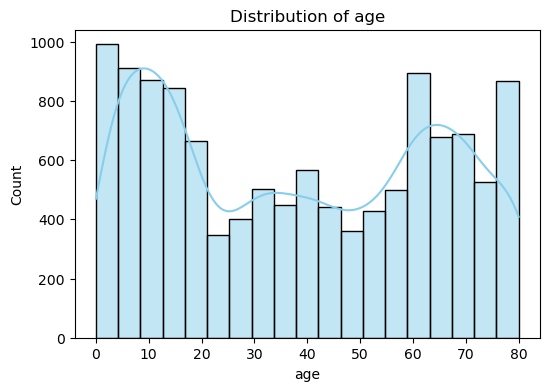

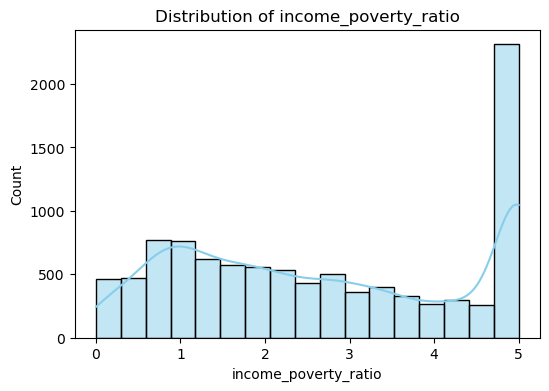

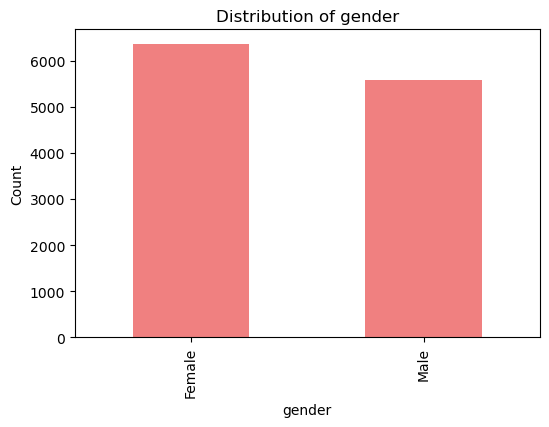

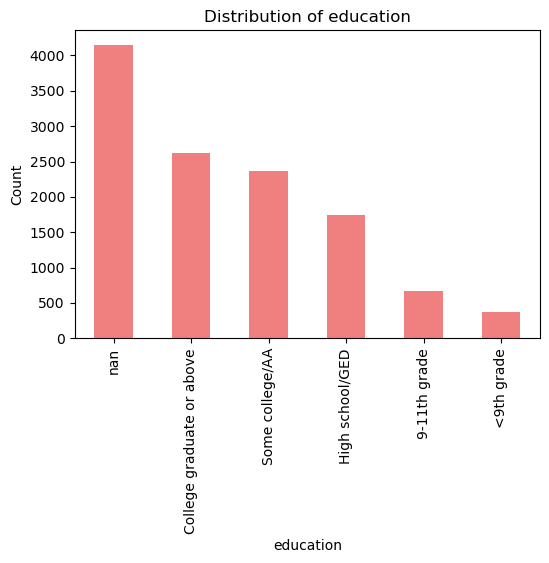

In [17]:
import matplotlib.pyplot as plt
import seaborn as sns

num_cols = ['age', 'income_poverty_ratio']

for col in num_cols:
    plt.figure(figsize=(6,4))
    sns.histplot(df[col], kde=True, color='skyblue')
    plt.title(f"Distribution of {col}")
    plt.show()

cat_cols = ['gender','education']

for col in cat_cols:
    plt.figure(figsize=(6,4))
    df[col].value_counts(dropna=False).plot(kind='bar', color='lightcoral')
    plt.title(f"Distribution of {col}")
    plt.xlabel(col)
    plt.ylabel("Count")
    plt.show()

**Age Distribution**

- The dataset includes participants across all age groups, with notable peaks in younger and older populations.

- This wide spread ensures that hypertension and insurance modeling captures diverse life stages.

**Income-Poverty Ratio Distribution**

- A large number of respondents fall between 0 and 1, indicating a substantial low-income and near-poverty population.
- As the ratio increases from 1 to about 4, the frequency gradually declines, reflecting a smaller middle-income group.
- There is a very sharp spike at exactly 5, which does not mean people’s true ratio is exactly 5, but rather that all respondents with income ≥ 5 times the poverty threshold are censored at this upper bound.

**Gender Distribution**

- Male and Female participants are approximately balanced.

- A well-balanced gender distribution reduces bias in model training.

**Education Level Distribution**

- Most participants fall into "College graduate or above" and "High school/GED" groups.

- Education, as a key SES indicator, may play a role in both health behaviors and insurance access.


## 3.2 Health indicators
This section examines three core physiological health indicators: BMI, SBP, and DBP, which together reflect the population’s cardiometabolic risk profile.

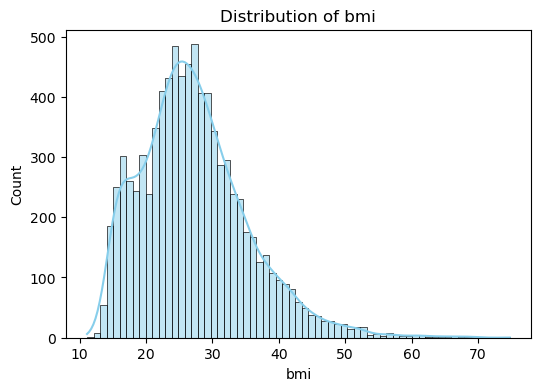

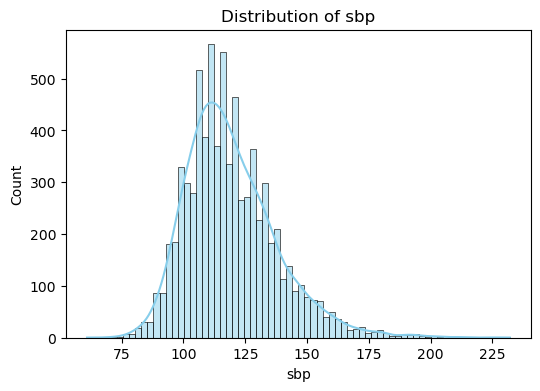

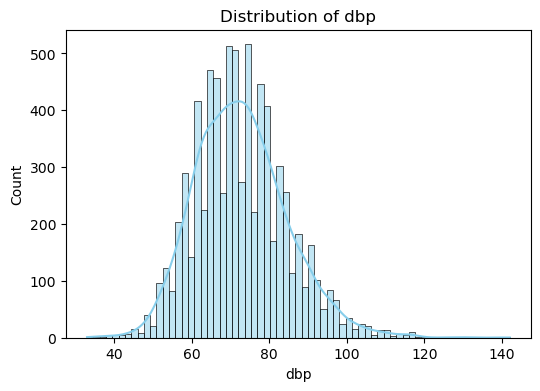

In [25]:
num_cols = ['bmi','sbp', 'dbp']

for col in num_cols:
    plt.figure(figsize=(6,4))
    sns.histplot(df[col], kde=True, color='skyblue')
    plt.title(f"Distribution of {col}")
    plt.show()

**BMI Distribution**

- BMI follows a right-skewed distribution with a strong concentration between 20–35.

- The long tail toward higher BMI suggests a subgroup with obesity-related risks.

- Since BMI is a known predictor of hypertension, this distribution supports later modeling.

**SBP(Systolic Blood Pressure)**

- SBP shows a moderately right-skewed pattern, with most readings between 110–140 mmHg.

- Readings above 140 indicate a segment already at hypertension Stage 2, important for classification tasks.

**DBP(Diastolic Blood Pressure)**

- DBP peaks around 70–85 mmHg.

- Outliers exceeding 100 mmHg reveal potential high-risk individuals.

## 3.3 Lifestyle
Lifestyle factors capture behavioral patterns that may influence both insurance status and health outcomes. These behavioral variables help us understand how daily habits contribute to the overall health profile of the population

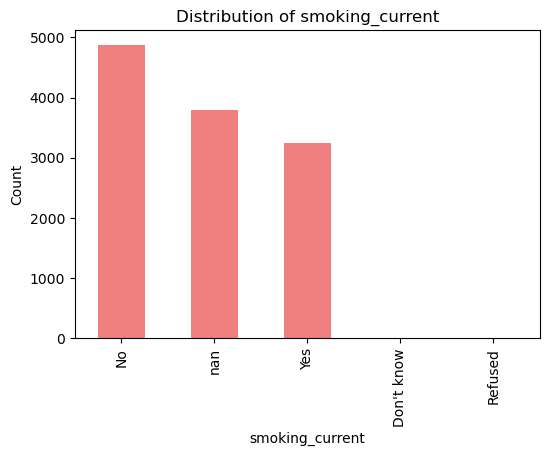

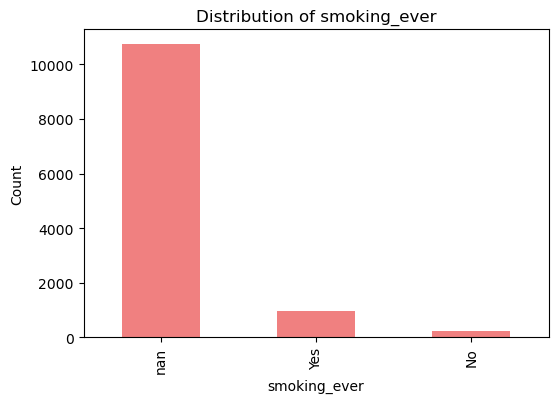

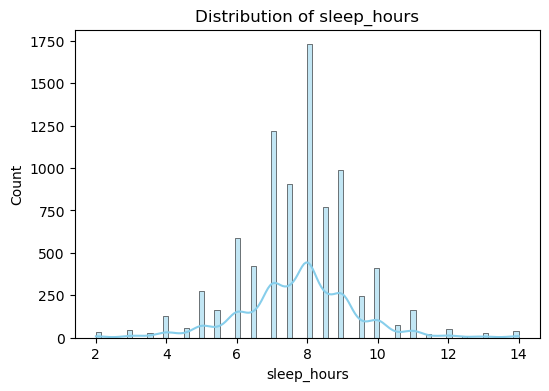

In [23]:
cat_cols = ['smoking_current', 'smoking_ever']

for col in cat_cols:
    plt.figure(figsize=(6,4))
    df[col].value_counts(dropna=False).plot(kind='bar', color='lightcoral')
    plt.title(f"Distribution of {col}")
    plt.xlabel(col)
    plt.ylabel("Count")
    plt.show()

num_cols = ['sleep_hours']

for col in num_cols:
    plt.figure(figsize=(6,4))
    sns.histplot(df[col], kde=True, color='skyblue')
    plt.title(f"Distribution of {col}")
    plt.show()


**Smoking Behavior**

**Current Smoking Status**

- Most participants are non-smokers, while a smaller but notable portion reports current smoking.

- Smoking is a major behavioral risk factor for hypertension and is therefore relevant to downstream models.

**Ever Smoked**

Many individuals report having smoked at some point, indicating long-term exposure to cardiovascular risk.


**Sleep Duration**

- Sleep hours are centered around 6–8 hours, with sparse outliers.

- Sleep shortage is often linked to hypertension, making this variable important for clustering.

## 3.4 Insurance status
Understanding insurance status is central to this project. This section visualizes both whether an individual has health insurance and their specific insurance type. To further explore potential disparities, we also plot SBP and DBP across insurance types in this part.

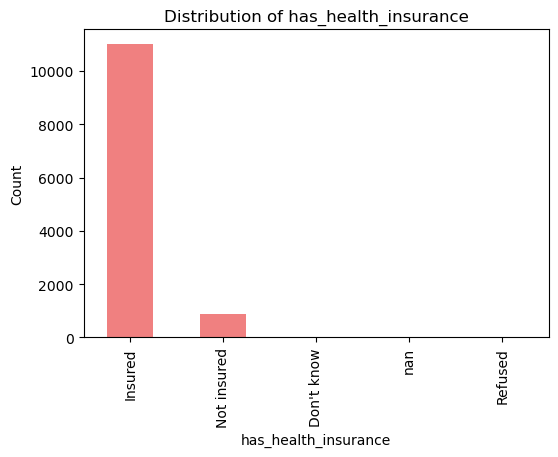

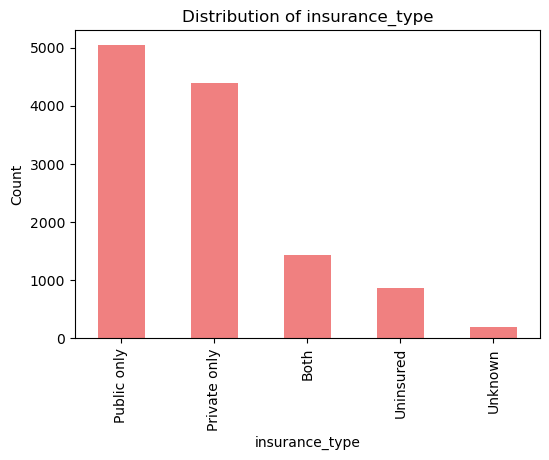

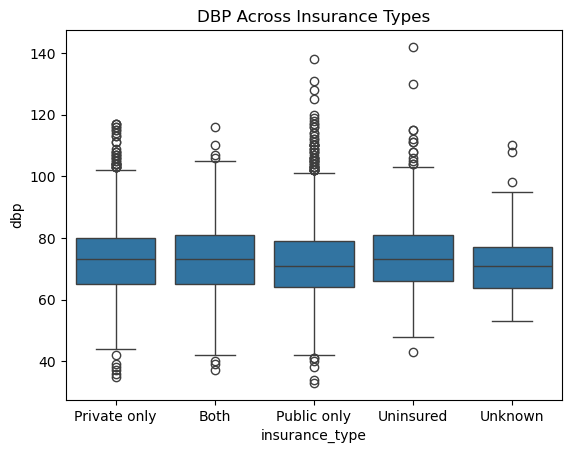

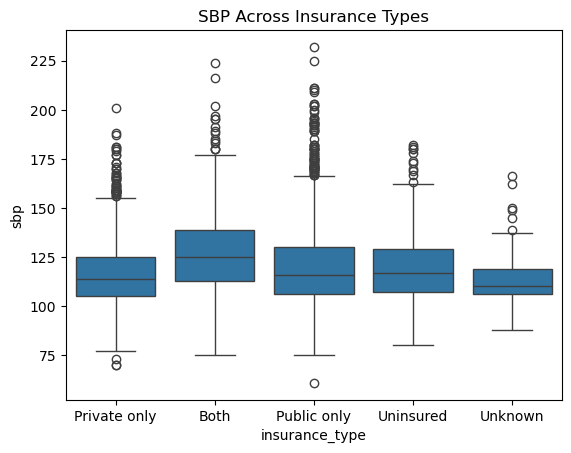

In [22]:
cat_cols = ['has_health_insurance', 'insurance_type']

for col in cat_cols:
    plt.figure(figsize=(6,4))
    df[col].value_counts(dropna=False).plot(kind='bar', color='lightcoral')
    plt.title(f"Distribution of {col}")
    plt.xlabel(col)
    plt.ylabel("Count")
    plt.show()
    
sns.boxplot(x='insurance_type', y='dbp', data=df)
plt.title("DBP Across Insurance Types")
plt.show()

sns.boxplot(x='insurance_type', y='sbp', data=df)
plt.title("SBP Across Insurance Types")
plt.show()

**Health Insurance Coverage**

- A large majority of the population is insured, but a non-trivial portion remains uninsured.

- This supports the project’s motivation to study SES-driven insurance gaps.

**Insurance Type Distribution**

- “Public only” and “Private only” are the two largest categories.

- The “Uninsured” group, while smaller, is essential for comparative analysis of health disparities.

**Blood Pressure Across Insurance Types**

**DBP Across Insurance Types**

- DBP shows visible variation between insurance categories.

- Publicly insured individuals tend to have slightly higher DBP medians, suggesting SES–health linkage.

**SBP Across Insurance Types**

- SBP variation is more pronounced, with uninsured and publicly insured groups showing higher variability.

- This pattern reinforces the hypothesis that insurance type reflects underlying health inequalities.

# 4. Association Rules

**Apriori** was selected given that **the dataset is not large in scale**, making its computational **cost manageable**, and **the algorithm is conceptually simple and highly transparent**. 
Compared with FP-Growth, Apriori provides **more interpretable intermediate results**, which makes it more suitable for reporting and presenting frequent itemsets and association rules.
## 4.1 Socioeconomic Patterns & Insurance Type
### 4.1.1 Frequent Itemsets

In [75]:
# Retain the samples aged 18 or above
import pandas as pd
import numpy as np

from mlxtend.preprocessing import TransactionEncoder
from mlxtend.frequent_patterns import apriori, association_rules

nhanes_clean = pd.read_csv("/Users/sherrywang/Desktop/Projects/Dataset/nhanes_clean.csv")
nhanes_clean_adult = nhanes_clean[nhanes_clean['age'] >= 18].copy()
nhanes_clean_adult.to_csv("nhanes_clean_adult.csv")
nhanes_clean_adult.to_pickle("nhanes_clean_adult.pkl")
print(nhanes_clean_adult.shape)

(8153, 21)


In [76]:
#Socio-economic → Insurance type

# Numeric data discretization

# Income poverty ratio discretization
nhanes_clean_adult['income_poverty_ratio_bin'] = pd.cut(
    nhanes_clean_adult['income_poverty_ratio'],
    bins = [0, 1, 2, 4, np.inf],
    labels = ['<=1 (Below poverty line)', '1-2', '2-4', '>4']
)

# Age discretization
nhanes_clean_adult['age_bin'] = pd.cut(
    nhanes_clean_adult['age'],
    bins= [18,30,45,60,80],
    labels= ['18-30', '31-45', '46-60', '61-80'],
    include_lowest=True
)
    
# Select categorical Socio-economic features
soci_cols = [
    'age_bin',
    'gender',
    'race',
    'education',
    'income_poverty_ratio_bin',
    'insurance_type'
]
nhanes_fp = nhanes_clean_adult[soci_cols].dropna().astype(str)

# Convert the dataframe to transaction format
transactions = (
    nhanes_fp
    .apply(lambda r: [f"{c}={r[c]}" for c in nhanes_fp.columns if pd.notna(r[c])], axis=1)
    .tolist()
)

te = TransactionEncoder()
te_ary = te.fit(transactions).transform(transactions)
nhanes_tf = pd.DataFrame(te_ary, columns = te.columns_)

In [46]:
# Run Apriori algorithm
freq_items = apriori(nhanes_tf, min_support = 0.05, use_colnames = True, max_len = 4)
freq_items.sort_values('support',ascending = False).head()
freq_items[freq_items['itemsets'].apply(lambda x: len(x) > 1)].sort_values('support', ascending=False).head(10)

,support,itemsets
92,0.320005,"(gender=Female, race=Non-Hispanic White)"
59,0.272906,"(age_bin=61-80, race=Non-Hispanic White)"
102,0.256961,"(race=Non-Hispanic White, gender=Male)"
108,0.232920,"(income_poverty_ratio_bin=2-4, race=Non-Hispanic White)"
116,0.232430,"(insurance_type=Private only, race=Non-Hispanic White)"
67,0.224580,"(education=College graduate or above, race=Non-Hispanic White)"
51,0.222495,"(gender=Female, age_bin=61-80)"
85,0.221391,"(gender=Female, income_poverty_ratio_bin=2-4)"
90,0.220164,"(gender=Female, insurance_type=Public only)"
114,0.207163,"(income_poverty_ratio_bin=>4, race=Non-Hispanic White)"


**Key observation:**

The most frequent itemsets combine **Non-Hispanic White race** with:
  - Female gender,
  - Older age (61–80),
  - Higher income-to-poverty ratio (2–4 or >4),
  - Private Insurance. :contentReference[oaicite:0]{index=0}  

This immediately shows that in our adult NHANES sample, **older, White, relatively better-off individuals are well covered**.

### 4.1.2 Rules with Insurance Type as Consequent

In [47]:
# Generate Association rule
rules = association_rules(freq_items, metric = 'lift', min_threshold = 1.0)

# KULC
rules['kulc'] = 0.5 * (
    rules['support'] / rules['antecedent support'] +
    rules['support'] / rules['consequent support']
)

# Imbalance Ratio (IR)
rules['ir'] = (
    (rules['antecedent support'] - rules['consequent support']).abs()
    / (rules['antecedent support'] + rules['consequent support'] - rules['support'])
)

# Filter insurance type as the consequent
rules_insurance = rules[rules['consequents'].astype(str).str.contains('insurance_type')]
rules_insurance = rules_insurance.sort_values('lift', ascending=False)

pd.set_option('display.max_colwidth', None)
rules_insurance[
    ['antecedents', 'consequents',
     'support', 'confidence', 'lift',
     'kulc', 'ir']
].head(10)


,antecedents,consequents,support,confidence,lift,kulc,ir
586,"(gender=Female, age_bin=61-80, race=Non-Hispanic White)",(insurance_type=Both),0.063903,0.423922,2.695971,0.415159,0.026633
593,"(age_bin=61-80, race=Non-Hispanic White)","(gender=Female, insurance_type=Both)",0.063903,0.234157,2.629593,0.475894,0.616872
316,"(age_bin=61-80, race=Non-Hispanic White)",(insurance_type=Both),0.110879,0.406292,2.583853,0.555720,0.362274
194,"(age_bin=61-80, education=College graduate or above)",(insurance_type=Both),0.052005,0.401135,2.551058,0.365934,0.117493
136,"(income_poverty_ratio_bin=>4, age_bin=31-45)",(insurance_type=Private only),0.052864,0.874239,2.440984,0.510921,0.813883
165,"(income_poverty_ratio_bin=>4, age_bin=46-60)",(insurance_type=Private only),0.059119,0.866906,2.420510,0.515987,0.789579
653,"(income_poverty_ratio_bin=>4, gender=Female)","(education=College graduate or above, insurance_type=Private only)",0.059978,0.418664,2.393668,0.380791,0.122565
724,(income_poverty_ratio_bin=>4),"(education=College graduate or above, insurance_type=Private only, race=Non-Hispanic White)",0.080216,0.286842,2.374237,0.475401,0.495979
589,"(gender=Female, age_bin=61-80)","(insurance_type=Both, race=Non-Hispanic White)",0.063903,0.287211,2.358135,0.405942,0.359143
112,"(age_bin=31-45, education=College graduate or above)",(insurance_type=Private only),0.068318,0.816716,2.280370,0.503734,0.734975


In [62]:
# Filter rules meet the criteria: support > 0.05, confidence > 0.4 and lift > 1.6
rules_insurance = rules[
    (rules['consequents'].astype(str).str.contains('insurance_type')) &
    (rules['support'] > 0.05) &
    ((rules['confidence'] > 0.4) & (rules['lift'] > 1.6)) &
     (rules['consequents'].apply(lambda s: all('insurance_type' in x for x in s)))
].sort_values('lift', ascending=False)

rules_insurance[
    ['antecedents', 'consequents',
     'support', 'confidence', 'lift',
     'kulc', 'ir']
].head(15)

,antecedents,consequents,support,confidence,lift,kulc,ir
586,"(gender=Female, age_bin=61-80, race=Non-Hispanic White)",(insurance_type=Both),0.063903,0.423922,2.695971,0.415159,0.026633
316,"(age_bin=61-80, race=Non-Hispanic White)",(insurance_type=Both),0.110879,0.406292,2.583853,0.555720,0.362274
194,"(age_bin=61-80, education=College graduate or above)",(insurance_type=Both),0.052005,0.401135,2.551058,0.365934,0.117493
136,"(income_poverty_ratio_bin=>4, age_bin=31-45)",(insurance_type=Private only),0.052864,0.874239,2.440984,0.510921,0.813883
165,"(income_poverty_ratio_bin=>4, age_bin=46-60)",(insurance_type=Private only),0.059119,0.866906,2.420510,0.515987,0.789579
112,"(age_bin=31-45, education=College graduate or above)",(insurance_type=Private only),0.068318,0.816716,2.280370,0.503734,0.734975
149,"(education=College graduate or above, age_bin=46-60)",(insurance_type=Private only),0.053968,0.791367,2.209594,0.471026,0.778656
143,"(age_bin=31-45, race=Non-Hispanic White)",(insurance_type=Private only),0.069668,0.664327,1.854884,0.429424,0.643904
650,"(income_poverty_ratio_bin=>4, gender=Female, education=College graduate or above)",(insurance_type=Private only),0.059978,0.655496,1.830226,0.411481,0.684293
178,"(race=Non-Hispanic White, age_bin=46-60)",(insurance_type=Private only),0.077885,0.647299,1.807338,0.432382,0.593693


**1. Rules leading to “Both” (dual coverage)**  
Rules such as 'age 61–80 & Non-Hispanic White → Both' show **lift ≈ 2.6–2.7** and moderate support.
**Insight**: Dual coverage (“Both”) is mainly concentrated among **older adults** who combine Medicare eligibility with private supplemental plans.  
Because **Medicare automatically covers individuals aged 65 and above**, older adults naturally exhibit higher rates of dual (public + private) coverage, creating a clear coverage advantage in this age group.  

**2. Rules leading to “Private only”**  
Strong rules like 'income > 4× poverty line & age 31–60 → Private only', 'college graduate & age 31–60 → Private only' have lift > 2.2 and confidence often > 0.8.  
**Insight**: **Middle-aged adults** who are **high-income or college-educated** overwhelmingly rely on private insurance.  
These groups benefit from **stable employment and employer-sponsored plans**, showing a clear socioeconomic gradient in private coverage access.

**3. Rules leading to “Public only”**    
Patterns like 'below poverty line & female → Public only' or 'below poverty line → Public only' show lift ≈ 1.6–1.7.    
**Insight**:**Low-income population** highly depend on **public insurance only**, and almost never appear in high-lift rules for private coverage.  
This highlights a **vulnerability** where **poverty** restrict access to private plans.   

## 4.2 Multi-Domain Determinants & Hypertension
### 4.2.1 Frequent Itemsets

In [30]:
# Hypertension Exploration
def hypertension_stage(row):
    sbp = row['sbp']
    dbp = row['dbp']

    # Normal（incl. Elevated）
    if sbp < 130 and dbp < 80:
        return "Normal"

    # Stage 1 Hypertension
    elif (130 <= sbp < 140) or (80 <= dbp < 90):
        return "Stage 1"

    # Stage 2 Hypertension
    elif sbp >= 140 or dbp >= 90:
        return "Stage 2"

    else:
        return "Undefined"
        
nhanes_clean_adult['htn_stage'] = nhanes_clean_adult.apply(hypertension_stage, axis=1)

# Numeric data discretization
# BMI discretization
nhanes_clean_adult['bmi_bin'] = pd.cut(
    nhanes_clean_adult['bmi'],       
    bins=[0, 25, 30, np.inf],
    labels=['Normal', 'Overweight', 'Obesity']
)

# Sleep (hours) discretization
nhanes_clean_adult['sleep_bin'] = pd.cut(
    nhanes_clean_adult['sleep_hours'],   
    bins=[0, 6, 8, np.inf],
    labels=['Short (<6h)', 'Normal (6-8h)', 'Long (>8h)']
)

# Select Multi-domain Determinants
determinant_features = [
    'age_bin',
    'gender',
    'race',
    'education',
    'income_poverty_ratio_bin',
    'insurance_type',
    'bmi_bin',
    'sleep_bin',
    'smoking_current',
    'htn_stage'
]
nhanes_health_fp = nhanes_clean_adult[determinant_features].dropna().astype(str)

# Convert the dataframe to transaction format
transactions = (
    nhanes_health_fp
    .apply(
        lambda r: [
            f"{c}={r[c]}" 
            for c in nhanes_health_fp.columns 
            if pd.notna(r[c])
        ],
        axis=1
    )
    .tolist()
)


te = TransactionEncoder()
te_ary = te.fit(transactions).transform(transactions)
nhanes_health_tf = pd.DataFrame(te_ary, columns = te.columns_)
nhanes_health_tf

# Run Apriori algorithm
freq_items = apriori(nhanes_health_tf, min_support = 0.05, use_colnames = True, max_len = 4)
freq_items.sort_values('support',ascending = False).head()
freq_items[freq_items['itemsets'].apply(lambda x: len(x) > 1)].sort_values('support', ascending=False).head(10)

,support,itemsets
250,0.418987,"(smoking_current=No, htn_stage=Normal)"
245,0.386851,"(race=Non-Hispanic White, htn_stage=Normal)"
201,0.384644,"(gender=Female, htn_stage=Normal)"
217,0.360849,"(gender=Female, smoking_current=No)"
248,0.352508,"(sleep_bin=Normal (6-8h), htn_stage=Normal)"
142,0.342083,"(bmi_bin=Overweight, htn_stage=Normal)"
317,0.324666,"(race=Non-Hispanic White, smoking_current=No)"
212,0.320005,"(gender=Female, race=Non-Hispanic White)"
322,0.318901,"(sleep_bin=Normal (6-8h), smoking_current=No)"
315,0.313995,"(sleep_bin=Normal (6-8h), race=Non-Hispanic White)"


The **most frequent itemsets** consistently combine "Normal blood pressure" with **healthier lifestyle** or **demographic traits**.
Specifically, the top itemsets pair Normal BP with:
- non-smoking status
- being female
- healthy sleep duration (6-8 hours)
- White race

This pattern shows that in our adult NHANES sample often share other healthy traits-such as not smoking, getting enough sleep, and belonging to generally advantaged demographic groups (female, Non-Hispanic White). 
These factors commonly appear together and form a cluster of low-risk health characteristics.

### 4.2.2 Rules for Hypertension Stages

In [31]:
# Generate Association rule
rules = association_rules(freq_items, metric = 'lift', min_threshold = 1.0)

# KULC
rules['kulc'] = 0.5 * (
    rules['support'] / rules['antecedent support'] +
    rules['support'] / rules['consequent support']
)

# Imbalance Ratio (IR)
rules['ir'] = (
    (rules['antecedent support'] - rules['consequent support']).abs()
    / (rules['antecedent support'] + rules['consequent support'] - rules['support'])
)

# Filter diabete risk as the consequent
rules_htn = rules[
    rules['consequents'].astype(str).str.contains('htn_stage')
].copy()
rules_htn = rules_htn.sort_values('lift', ascending=False)

pd.set_option('display.max_colwidth', None)
rules_htn[
    ['antecedents', 'consequents',
     'support', 'confidence', 'lift',
     'kulc', 'ir']
].head(10)

,antecedents,consequents,support,confidence,lift,kulc,ir
3742,"(age_bin=61-80, race=Non-Hispanic White)","(insurance_type=Both, htn_stage=Normal)",0.063903,0.234157,2.555669,0.465807,0.603019
2962,"(age_bin=31-45, education=College graduate or above)","(insurance_type=Private only, htn_stage=Normal)",0.053477,0.639296,2.493867,0.423954,0.602740
3745,(insurance_type=Both),"(age_bin=61-80, race=Non-Hispanic White, htn_stage=Normal)",0.063903,0.406396,2.493114,0.399210,0.022488
5579,"(education=College graduate or above, insurance_type=Private only)","(income_poverty_ratio_bin=>4, htn_stage=Normal)",0.079357,0.453717,2.451393,0.441239,0.036276
2970,(insurance_type=Private only),"(age_bin=31-45, education=College graduate or above, htn_stage=Normal)",0.053477,0.149315,2.318792,0.489896,0.795945
3746,(age_bin=61-80),"(insurance_type=Both, race=Non-Hispanic White, htn_stage=Normal)",0.063903,0.157164,2.209244,0.527720,0.810611
5582,(income_poverty_ratio_bin=>4),"(education=College graduate or above, insurance_type=Private only, htn_stage=Normal)",0.079357,0.283772,2.188829,0.447941,0.454647
3740,"(insurance_type=Both, race=Non-Hispanic White)","(age_bin=61-80, htn_stage=Normal)",0.063903,0.524673,2.186941,0.395516,0.396623
5623,(education=College graduate or above),"(income_poverty_ratio_bin=>4, smoking_current=No, htn_stage=Normal)",0.089415,0.277714,2.164632,0.487328,0.536710
4242,"(education=College graduate or above, bmi_bin=Overweight)","(income_poverty_ratio_bin=>4, htn_stage=Normal)",0.056421,0.398268,2.151811,0.351553,0.160617


In [32]:
# Filter rules meet the criteria: support > 0.03, confidence > 0.2 and lift > 1.3
rules_htn = rules[
    (rules['support'] > 0.03) &
    (rules['confidence'] > 0.2) &
    (rules['lift'] > 1.3) &
    (rules['consequents'].apply(lambda s: len(s) == 1)) &
    (rules['consequents'].apply(lambda s: list(s)[0].startswith('htn_stage')))
].sort_values('lift', ascending=False)

rules_htn[
    ['antecedents','consequents','support','confidence','lift','kulc','ir']
].head(10)

,antecedents,consequents,support,confidence,lift,kulc,ir
1402,"(bmi_bin=Obesity, race=Non-Hispanic White)",(htn_stage=Stage 1),0.063535,0.329098,1.463794,0.305847,0.089650
1412,"(bmi_bin=Obesity, smoking_current=No)",(htn_stage=Stage 1),0.062799,0.324051,1.441345,0.301687,0.087211
100,(bmi_bin=Obesity),(htn_stage=Stage 1),0.107200,0.323464,1.438736,0.400139,0.237367
1408,"(sleep_bin=Normal (6-8h), bmi_bin=Obesity)",(htn_stage=Stage 1),0.053845,0.318347,1.415974,0.278922,0.163722
2866,"(age_bin=18-30, bmi_bin=Overweight, smoking_current=No)",(htn_stage=Normal),0.052251,0.940397,1.386950,0.508730,0.913591
322,"(age_bin=18-30, bmi_bin=Overweight)",(htn_stage=Normal),0.067705,0.940375,1.386917,0.520115,0.888190
310,"(age_bin=18-30, bmi_bin=Normal)",(htn_stage=Normal),0.054336,0.911523,1.344364,0.495830,0.905044
332,"(age_bin=18-30, gender=Female)",(htn_stage=Normal),0.082056,0.910204,1.342419,0.515612,0.856811
2878,"(age_bin=18-30, gender=Female, smoking_current=No)",(htn_stage=Normal),0.071630,0.908243,1.339526,0.506943,0.874351
2930,"(age_bin=31-45, gender=Female, bmi_bin=Overweight)",(htn_stage=Normal),0.050902,0.908096,1.339311,0.491584,0.910413


In [33]:
htn = [
    'htn_stage=Stage 1',
    'htn_stage=Stage 2'
]

rules_htn = (
    rules[
        (rules['support'] > 0.03) &
        (rules['confidence'] > 0.1) &
        (rules['lift'] > 1.1) &
        (rules['consequents'].apply(lambda s: len(s) == 1)) &
        (rules['consequents'].apply(lambda s: list(s)[0] in htn))
    ]
    .sort_values('lift', ascending=False)
)

rules_htn[
    ['antecedents','consequents','support','confidence','lift','kulc','ir']
].head(10)

,antecedents,consequents,support,confidence,lift,kulc,ir
58,(age_bin=61-80),(htn_stage=Stage 2),0.059242,0.145701,1.499878,0.377775,0.696192
1402,"(bmi_bin=Obesity, race=Non-Hispanic White)",(htn_stage=Stage 1),0.063535,0.329098,1.463794,0.305847,0.089650
1412,"(bmi_bin=Obesity, smoking_current=No)",(htn_stage=Stage 1),0.062799,0.324051,1.441345,0.301687,0.087211
100,(bmi_bin=Obesity),(htn_stage=Stage 1),0.107200,0.323464,1.438736,0.400139,0.237367
1408,"(sleep_bin=Normal (6-8h), bmi_bin=Obesity)",(htn_stage=Stage 1),0.053845,0.318347,1.415974,0.278922,0.163722
1336,"(bmi_bin=Obesity, gender=Female)",(htn_stage=Stage 1),0.059119,0.291239,1.295400,0.277098,0.059215
38,(age_bin=46-60),(htn_stage=Stage 1),0.057770,0.271470,1.207470,0.264213,0.031644
984,"(age_bin=61-80, smoking_current=No)",(htn_stage=Stage 1),0.056789,0.268873,1.195922,0.260732,0.035899
974,"(age_bin=61-80, race=Non-Hispanic White)",(htn_stage=Stage 1),0.073347,0.268764,1.195435,0.297503,0.113295
2662,"(income_poverty_ratio_bin=>4, race=Non-Hispanic White)",(htn_stage=Stage 1),0.055562,0.268206,1.192954,0.257671,0.046921


**1. Risk-increasing patterns**  
Rules such as 'bmi_bin=Obesity & race=Non-Hispanic White → htn_stage=Stage 1' show lift ≈ 1.5.
**Obesity alone** already maps to **Stage 1** with confidence ≈ 0.32, making it one of the earliest detectable risk markers.  
**Insight**: **Obesity acts as a key entry point into hypertension**, elevating Stage 1 risk even before age becomes a major driver. This suggests that early **weight-management interventions** could substantially delay or prevent the transition from Normal BP to Stage 1.

**2. Age-driven patterns**  
- **Older age groups** (e.g., age_bin=61–80) appear in the strongest rules for **Stage 2**, showing the highest lift among all Stage-2 associations.
- **Young age groups** such as age_bin=18–30 who are overweight still overwhelmingly maintain normal blood pressure. With a confidence of ~94%, this is one of **the strongest protective patterns** in the dataset.  
**Insight**: The rules capture a clear physiological gradient: **young age protects, obesity pushes individuals into Stage 1, and aging ultimately drives progression to Stage 2**.

# 5. Classification

Three classification models—**Decision Tree**, **Random Forest**, and **XGBoost**—were selected to provide a balanced comparison between interpretability and predictive performance.  

**Decision Tree**  
- **High interpretability**: produces clear **if–then structures** that reveal explicit decision rules.
- **Rule-capturing ability**: effective for **datasets with strong hierarchical or threshold patterns** (e.g., age or BMI splits in hypertension).
- **Lightweight baseline**: fast to train, easy to visualize, and ideal as an initial **benchmark model**.

**Random Forest**  
- **Robust against overfitting**: **aggregates** multiple decorrelated decision trees via **bagging**, greatly **improving stability** **under noisy or imbalanced data**.
- **Strong generalization**: suited for **multi-class prediction** with many variables.
- **Nonlinear modeling ability**: automatically captures **interaction effects and complex nonlinear patterns** that a single tree may miss.

**XGBoost**  
- **High predictive power**: **optimized boosted tree ensembles** that excel on structured tabular data.
- **Captures complex interactions**: models **nonlinear effects** and deep feature interactions through **sequential boosting**.
- **Improved minority-class performance**: often enhances **recall and F1-scores** for **underrepresented classes**, which is valuable in multi-class health classification.

## 5.1 Classification for Insurance Type

### 5.1.1 Baseline Models: Decision Tree, Random Forest, XGBoost

In [3]:
import numpy as np
import pandas as pd
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from imblearn.over_sampling import SMOTE
from imblearn.pipeline import Pipeline
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    accuracy_score,
    recall_score,
    f1_score,
    make_scorer
)
from sklearn.model_selection import (
    train_test_split,
    StratifiedKFold,
    cross_validate,
    GridSearchCV
)
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, LabelEncoder

#The insurance classification model initially built using the baseline set of 14 features
nhanes_clean_adult_add = pd.read_csv("nhanes_clean_adult_add.csv")

ins_feature_cols_base = [
    "age",
    "gender",
    "race",
    "education",
    "income_poverty_ratio",
    "smoking_current",
    "diabetes_self_report",
    "bmi",
    "sbp",
    "dbp",
    "a1c",
    "sleep_hours",
]

target_ins = "insurance_type"

categorical_ins_base = [
    "gender", "race", "education",
    "smoking_current", "diabetes_self_report",
]

numeric_ins_base = [
    "age", "income_poverty_ratio",
    "bmi", "sbp", "dbp", "a1c", "sleep_hours",
]

preprocess_ins_base = ColumnTransformer(
    transformers=[
        ("cat", OneHotEncoder(handle_unknown="ignore", sparse_output=False), categorical_ins_base),
        ("num", "passthrough", numeric_ins_base),
    ]
)

X_ins_base = nhanes_clean_adult_add[ins_feature_cols_base].copy()
y_ins_base = nhanes_clean_adult_add[target_ins].copy()

data_ins_base = pd.concat([X_ins_base, y_ins_base], axis=1).dropna(
    subset=ins_feature_cols_base + [target_ins]
)
X_ins_base = data_ins_base[ins_feature_cols_base]
y_ins_base = data_ins_base[target_ins]

# y encode
le_ins_base = LabelEncoder()
y_ins_base_enc = le_ins_base.fit_transform(y_ins_base)

# Train/Test Split
X_ins_base_train, X_ins_base_test, y_ins_base_train, y_ins_base_test = train_test_split(
    X_ins_base,
    y_ins_base_enc,
    test_size=0.2,
    random_state=42,
    stratify=y_ins_base_enc,
)

# StratifiedKFold
cv_ins_base = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

models_ins = {
    "Decision_Tree": DecisionTreeClassifier(
        criterion="entropy", max_depth=5,
        min_samples_split=50, min_samples_leaf=10,
        random_state=42
    ),
    "Random_Forest": RandomForestClassifier(
        n_estimators=400, max_depth=None,
        min_samples_split=5, max_features="sqrt",
        class_weight="balanced", random_state=42, n_jobs=1
    ),
    "XGBoost": XGBClassifier(
        n_estimators=300, max_depth=5,
        learning_rate=0.05, subsample=0.8,
        colsample_bytree=0.8, objective="multi:softprob",
        eval_metric="mlogloss", random_state=42
    )
}

scoring_cv_base = {
    "accuracy": "accuracy",
    "recall_macro": "recall_macro",
    "recall_weighted": "recall_weighted",
    "f1_macro": "f1_macro",
}

for name, clf in models_ins.items():
    pipe_base = Pipeline([
        ("preprocess", preprocess_ins_base),
        ("smote", SMOTE(random_state=42)),
        ("clf", clf),
    ])

    cv_res_base = cross_validate(
        pipe_base,
        X_ins_base_train,
        y_ins_base_train,
        cv=cv_ins_base,
        scoring=scoring_cv_base,
        n_jobs=1,
        return_train_score=False,
    )

    print(f"\n=== Insurance {name} (baseline) ===")
    print("5-fold Accuracy per fold:", cv_res_base["test_accuracy"])
    print("5-fold Macro Recall per fold:", cv_res_base["test_recall_macro"])
    print("5-fold F1-macro per fold:", cv_res_base["test_f1_macro"])
    print("Mean Accuracy:", cv_res_base["test_accuracy"].mean())
    print("Mean Macro Recall:", cv_res_base["test_recall_macro"].mean())
    print("Mean F1-macro:", cv_res_base["test_f1_macro"].mean())


=== Insurance Decision_Tree (baseline) ===
5-fold Accuracy per fold: [0.52260536 0.52337165 0.53911043 0.49846626 0.52300613]
5-fold Macro Recall per fold: [0.49714417 0.55069747 0.50606466 0.49415156 0.49340032]
5-fold F1-macro per fold: [0.45164768 0.44772236 0.44418276 0.42343628 0.43357231]
Mean Accuracy: 0.5213119667160285
Mean Macro Recall: 0.5082916355636635
Mean F1-macro: 0.4401122771716165

=== Insurance Random_Forest (baseline) ===
5-fold Accuracy per fold: [0.61149425 0.61992337 0.62806748 0.61886503 0.62116564]
5-fold Macro Recall per fold: [0.46689334 0.49239247 0.45318512 0.43597733 0.42249779]
5-fold F1-macro per fold: [0.48452714 0.51582247 0.4623569  0.44524399 0.42519307]
Mean Accuracy: 0.619903156806055
Mean Macro Recall: 0.45418921110655575
Mean F1-macro: 0.4666287155512941

=== Insurance XGBoost (baseline) ===
5-fold Accuracy per fold: [0.61226054 0.6137931  0.62883436 0.6357362  0.60966258]
5-fold Macro Recall per fold: [0.46701043 0.48304579 0.43173658 0.4719938

### 5.1.2 Models with More Socioeconomic Features and Decision Tree, Random Forest, XGBoost

In [87]:
# To improve the model accurary, considering adding more soci-economic features
# marital_status (DMDMARTZ) from DEMO_L.xpt
# household_size (DMDHHSIZ) from DEMO_L.xpt
# is_employed (OCQ180) from OCQ_L.xpt

path = "/Users/sherrywang/Desktop/Data_Mining/Project/data-mining-project-starter/data/raw/"
demo = pd.read_sas(path + "DEMO_L.xpt")
ocq  = pd.read_sas(path + "OCQ_L.xpt")

demo_sub = demo[['SEQN', 'DMDMARTZ', 'DMDHHSIZ']].copy()

demo_sub = demo_sub.rename(columns={
    'DMDMARTZ': 'marital_status',
    'DMDHHSIZ': 'household_size'
})

# Marital_status Mapping
marital_map = {
    1: "Married / living with partner",
    2: "Widowed / divorced / separated",
    3: "Never married",
    77: None,
    99: None
}
demo_sub['marital_status'] = demo_sub['marital_status'].map(marital_map)

#Is_employed Mapping
ocq_sub = ocq[['SEQN', 'OCQ180']].copy()
ocq_sub = ocq_sub.rename(columns={'OCQ180': 'hours_worked_last_week'})
ocq_sub['hours_worked_last_week'] = ocq_sub['hours_worked_last_week'].replace(
    {77777: np.nan, 99999: np.nan}
)

# Simple employment indicator
ocq_sub['is_employed'] = ocq_sub['hours_worked_last_week'].apply(
    lambda x: "Yes" if pd.notna(x) and x > 0 else "No"
)

# Merge as the soci_raw

soci_raw = (
    demo_sub
    .merge(ocq_sub, on='SEQN', how='left')
)
soci_raw = soci_raw.rename(columns={'SEQN': 'id'})

soci_raw.head()

,id,marital_status,household_size,hours_worked_last_week,is_employed
0,130378.0,Married / living with partner,4.0,40.0,Yes
1,130379.0,Married / living with partner,2.0,32.0,Yes
2,130380.0,Married / living with partner,7.0,8.0,Yes
3,130381.0,NaN,2.0,NaN,NaN
4,130382.0,NaN,4.0,NaN,NaN


In [88]:
nhanes_clean_adult = pd.read_csv("nhanes_clean_adult.csv")

nhanes_clean_adult_add = nhanes_clean_adult.copy()
nhanes_clean_adult_add = nhanes_clean_adult_add.merge(soci_raw, on='id', how='left')
print('Missing Percentage by Variable')
print(nhanes_clean_adult_add[['marital_status', 'household_size', 'is_employed']].isna().mean().sort_values(ascending=False))

print('\nVariable Types (dtypes)')
print(nhanes_clean_adult_add[['marital_status', 'household_size', 'is_employed']].dtypes)

nhanes_clean_adult_add[['marital_status', 'household_size', 'is_employed']].describe(include='all').round(2)

Missing Percentage by Variable
marital_status    0.045382
household_size    0.000000
is_employed       0.000000
dtype: float64

Variable Types (dtypes)
marital_status     object
household_size    float64
is_employed        object
dtype: object


,marital_status,household_size,is_employed
count,7783,8153.00,8153
unique,3,NaN,2
top,Married / living with partner,NaN,Yes
freq,4136,NaN,4118
mean,NaN,2.62,NaN
std,NaN,1.49,NaN
min,NaN,1.00,NaN
25%,NaN,2.00,NaN
50%,NaN,2.00,NaN
75%,NaN,4.00,NaN


In [89]:
# Handling missing values
nhanes_clean_adult_add['marital_status'] = (
    nhanes_clean_adult_add['marital_status']
        .astype('string')
        .str.strip()
        .fillna("Unknown")
)
print('Missing Percentage by Variable')
print(nhanes_clean_adult_add[['marital_status', 'household_size', 'is_employed']].isna().mean().sort_values(ascending=False))
nhanes_clean_adult_add = nhanes_clean_adult_add.drop(columns=['hours_worked_last_week'], errors='ignore')
nhanes_clean_adult_add = nhanes_clean_adult_add.loc[:, ~nhanes_clean_adult_add.columns.str.contains('^Unnamed')]
nhanes_clean_adult_add.to_csv("nhanes_clean_adult_add.csv", index=False)

Missing Percentage by Variable
marital_status    0.0
household_size    0.0
is_employed       0.0
dtype: float64


In [5]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder
ins_feature_cols = [
    "age",
    "gender",
    "race",
    "education",
    "income_poverty_ratio",
    "marital_status",
    "household_size",
    "is_employed",
    "smoking_current",
    "diabetes_self_report",
    "bmi",
    "sbp",
    "dbp",
    "a1c",
    "sleep_hours"
]
target_ins = "insurance_type"

categorical_ins = [
    "gender", "race", "education", "marital_status",
    "is_employed", "smoking_current", "diabetes_self_report"
]
numeric_ins = [
    "age", "income_poverty_ratio", "household_size",
    "bmi", "sbp", "dbp", "a1c", "sleep_hours"
]

#ColumnTransformer + OneHot
preprocess_ins = ColumnTransformer(
    transformers=[
        ("cat", OneHotEncoder(handle_unknown="ignore", sparse_output=False), categorical_ins),
        ("num", "passthrough", numeric_ins),
    ]
)

In [6]:
# Train/Test Split
X_ins = nhanes_clean_adult_add[ins_feature_cols].copy()
y_ins = nhanes_clean_adult_add[target_ins].copy()


data_ins = pd.concat([X_ins, y_ins], axis=1).dropna(subset=ins_feature_cols + [target_ins])
X_ins = data_ins[ins_feature_cols]
y_ins = data_ins[target_ins]

# LabelEncoder transfer y from characters to integer 
le_ins = LabelEncoder()
y_ins_encoded = le_ins.fit_transform(y_ins)

X_ins_train, X_ins_test, y_ins_train, y_ins_test = train_test_split(
    X_ins,
    y_ins_encoded,
    test_size=0.2,
    random_state=42,
    stratify=y_ins_encoded,
)

#StratifiedKFold Cross Validation
cv_ins = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

In [6]:
# Baseline Model

models_ins = {
    "Decision_Tree": DecisionTreeClassifier(
        criterion="entropy", max_depth=5,
        min_samples_split=50, min_samples_leaf=10,
        random_state=42
    ),
    "Random_Forest": RandomForestClassifier(
        n_estimators=400, max_depth=None,
        min_samples_split=5, max_features="sqrt",
        class_weight="balanced", random_state=42, n_jobs=2
    ),
    "XGBoost": XGBClassifier(
        n_estimators=300, max_depth=5,
        learning_rate=0.05, subsample=0.8,
        colsample_bytree=0.8,
        objective="multi:softprob",
        eval_metric="mlogloss",
        random_state=42
    )
}

scoring_cv = {
    "accuracy": "accuracy",
    "recall_macro": "recall_macro",
    "recall_weighted": "recall_weighted",
    "f1_macro": "f1_macro",
}

print("BASELINE CV PERFORMANCE")
baseline_scores = {}

for name, clf in models_ins.items():
    pipe = Pipeline([
        ("preprocess", preprocess_ins),
        ("smote", SMOTE(random_state=42)),
        ("clf", clf),
    ])

    cv_res = cross_validate(
        pipe, X_ins_train, y_ins_train,
        cv=cv_ins, scoring=scoring_cv, n_jobs=2,
        return_train_score=False
    )

    acc_mean = cv_res["test_accuracy"].mean()
    rec_mean = cv_res["test_recall_macro"].mean()
    f1_mean  = cv_res["test_f1_macro"].mean()

    baseline_scores[name] = {
        "accuracy_cv": acc_mean,
        "recall_macro_cv": rec_mean,
        "f1_macro_cv": f1_mean,
    }

    print(f"\nInsurance {name} (baseline)")
    print("5-fold Accuracy per fold:", cv_res["test_accuracy"])
    print("5-fold Macro Recall per fold:", cv_res["test_recall_macro"])
    print("5-fold F1-macro per fold:", cv_res["test_f1_macro"])
    print("Mean Accuracy:", acc_mean)
    print("Mean Macro Recall:", rec_mean)
    print("Mean F1-macro:", f1_mean)



# GridSearchCV with F1-macro as main metric

param_grids = {
    "Decision_Tree": {
        "clf__criterion": ["gini", "entropy"],
        "clf__max_depth": [3, 5, 10, None],
        "clf__min_samples_leaf": [1, 5, 10],
    },
    "Random_Forest": {
        "clf__n_estimators": [200, 400],
        "clf__max_depth": [None, 10, 20],
        "clf__min_samples_split": [2, 5],
        "clf__max_features": ["sqrt", "log2"],
    },
    "XGBoost": {
        "clf__n_estimators": [200, 300],
        "clf__max_depth": [3, 5],
        "clf__learning_rate": [0.05, 0.1],
        "clf__subsample": [0.8, 1.0],
        "clf__colsample_bytree": [0.8, 1.0],
    }
}

f1_macro_scorer = make_scorer(f1_score, average="macro")

scoring_multi = {
    "f1_macro": f1_macro_scorer,
    "accuracy": "accuracy",
    "recall_macro": "recall_macro",
}

best_models_ins = {}
tuned_scores = {}

print("\n\n GRIDSEARCH WITH F1-MACRO ")

for name in ["Decision_Tree", "Random_Forest", "XGBoost"]:
    print(f"\n----- GridSearch for {name} on insurance_type (F1-macro as main metric) -----")

    base_clf = models_ins[name]

    pipe = Pipeline([
        ("preprocess", preprocess_ins),
        ("smote", SMOTE(random_state=42)),
        ("clf", base_clf),
    ])

    grid = param_grids[name]

    gs = GridSearchCV(
        estimator=pipe,
        param_grid=grid,
        cv=cv_ins,
        scoring=scoring_multi,
        refit="f1_macro",
        n_jobs=2,
    )

    gs.fit(X_ins_train, y_ins_train)

    best_models_ins[name] = gs.best_estimator_

    cv_results = gs.cv_results_
    best_idx = gs.best_index_

    best_f1 = cv_results["mean_test_f1_macro"][best_idx]
    best_acc = cv_results["mean_test_accuracy"][best_idx]
    best_rec = cv_results["mean_test_recall_macro"][best_idx]

    tuned_scores[name] = {
        "f1_macro_cv": best_f1,
        "accuracy_cv": best_acc,
        "recall_macro_cv": best_rec,
        "best_params": gs.best_params_,
    }

    print("Best params:", gs.best_params_)
    print(f"Best CV Accuracy:    {best_acc:.4f}")
    print(f"Best CV MacroRecall: {best_rec:.4f}")
    print(f"Best CV F1-macro:    {best_f1:.4f}")

print("\n\nSUMMARY: TUNED MODELS (CV)")
for name, metrics in tuned_scores.items():
    print(f"\n>>> {name}")
    print(f"  Accuracy (CV, tuned):   {metrics['accuracy_cv']:.4f}")
    print(f"  Macro Recall (CV, tuned): {metrics['recall_macro_cv']:.4f}")
    print(f"  F1-macro (CV, tuned):   {metrics['f1_macro_cv']:.4f}")
    print(f"  Best Params: {metrics['best_params']}")

# Best Model based F1-macro performance
best_model_name = max(
    tuned_scores,
    key=lambda m: tuned_scores[m]["f1_macro_cv"]
)
print(f"\n***** Best model by CV F1-macro: {best_model_name} *****")
print("With scores:", tuned_scores[best_model_name])

BASELINE CV PERFORMANCE

Insurance Decision_Tree (baseline)
5-fold Accuracy per fold: [0.51417625 0.47586207 0.50920245 0.51226994 0.4708589 ]
5-fold Macro Recall per fold: [0.51245609 0.52582224 0.51512254 0.50273657 0.46341485]
5-fold F1-macro per fold: [0.44106556 0.39148143 0.41215391 0.42288974 0.40039715]
Mean Accuracy: 0.4964739205039607
Mean Macro Recall: 0.5039104589963702
Mean F1-macro: 0.4135975566775708

Insurance Random_Forest (baseline)
5-fold Accuracy per fold: [0.63831418 0.64750958 0.6541411  0.65567485 0.6196319 ]
5-fold Macro Recall per fold: [0.48073772 0.50220554 0.45863272 0.47166672 0.42995352]
5-fold F1-macro per fold: [0.50725956 0.52095247 0.46962937 0.49219592 0.43938735]
Mean Accuracy: 0.6430543215100017
Mean Macro Recall: 0.46863924267011237
Mean F1-macro: 0.4858849354954115


/opt/anaconda3/envs/ml310/lib/python3.10/site-packages/joblib/externals/loky/process_executor.py:782: UserWarning: A worker stopped while some jobs were given to the executor. This can be caused by a too short worker timeout or by a memory leak.
  warnings.warn(



Insurance XGBoost (baseline)
5-fold Accuracy per fold: [0.63678161 0.63678161 0.64647239 0.64263804 0.625     ]
5-fold Macro Recall per fold: [0.48078257 0.50804915 0.45618995 0.47918446 0.42729473]
5-fold F1-macro per fold: [0.49689291 0.53639758 0.46463981 0.49846704 0.430318  ]
Mean Accuracy: 0.6375347295677314
Mean Macro Recall: 0.4703001713226371
Mean F1-macro: 0.4853430685306329


 GRIDSEARCH WITH F1-MACRO 

----- GridSearch for Decision_Tree on insurance_type (F1-macro as main metric) -----
Best params: {'clf__criterion': 'entropy', 'clf__max_depth': 10, 'clf__min_samples_leaf': 10}
Best CV Accuracy:    0.5802
Best CV MacroRecall: 0.4601
Best CV F1-macro:    0.4426

----- GridSearch for Random_Forest on insurance_type (F1-macro as main metric) -----


/opt/anaconda3/envs/ml310/lib/python3.10/site-packages/joblib/externals/loky/process_executor.py:782: UserWarning: A worker stopped while some jobs were given to the executor. This can be caused by a too short worker timeout or by a memory leak.
  warnings.warn(


Best params: {'clf__max_depth': 10, 'clf__max_features': 'sqrt', 'clf__min_samples_split': 5, 'clf__n_estimators': 200}
Best CV Accuracy:    0.6285
Best CV MacroRecall: 0.5034
Best CV F1-macro:    0.4940

----- GridSearch for XGBoost on insurance_type (F1-macro as main metric) -----


/opt/anaconda3/envs/ml310/lib/python3.10/site-packages/joblib/externals/loky/process_executor.py:782: UserWarning: A worker stopped while some jobs were given to the executor. This can be caused by a too short worker timeout or by a memory leak.
  warnings.warn(


Best params: {'clf__colsample_bytree': 0.8, 'clf__learning_rate': 0.05, 'clf__max_depth': 3, 'clf__n_estimators': 200, 'clf__subsample': 0.8}
Best CV Accuracy:    0.6300
Best CV MacroRecall: 0.4991
Best CV F1-macro:    0.4906


SUMMARY: TUNED MODELS (CV)

>>> Decision_Tree
  Accuracy (CV, tuned):   0.5802
  Macro Recall (CV, tuned): 0.4601
  F1-macro (CV, tuned):   0.4426
  Best Params: {'clf__criterion': 'entropy', 'clf__max_depth': 10, 'clf__min_samples_leaf': 10}

>>> Random_Forest
  Accuracy (CV, tuned):   0.6285
  Macro Recall (CV, tuned): 0.5034
  F1-macro (CV, tuned):   0.4940
  Best Params: {'clf__max_depth': 10, 'clf__max_features': 'sqrt', 'clf__min_samples_split': 5, 'clf__n_estimators': 200}

>>> XGBoost
  Accuracy (CV, tuned):   0.6300
  Macro Recall (CV, tuned): 0.4991
  F1-macro (CV, tuned):   0.4906
  Best Params: {'clf__colsample_bytree': 0.8, 'clf__learning_rate': 0.05, 'clf__max_depth': 3, 'clf__n_estimators': 200, 'clf__subsample': 0.8}

***** Best model by CV F1-ma

### 5.1.3 Model Comparison, Selection and Final Model Evaluation

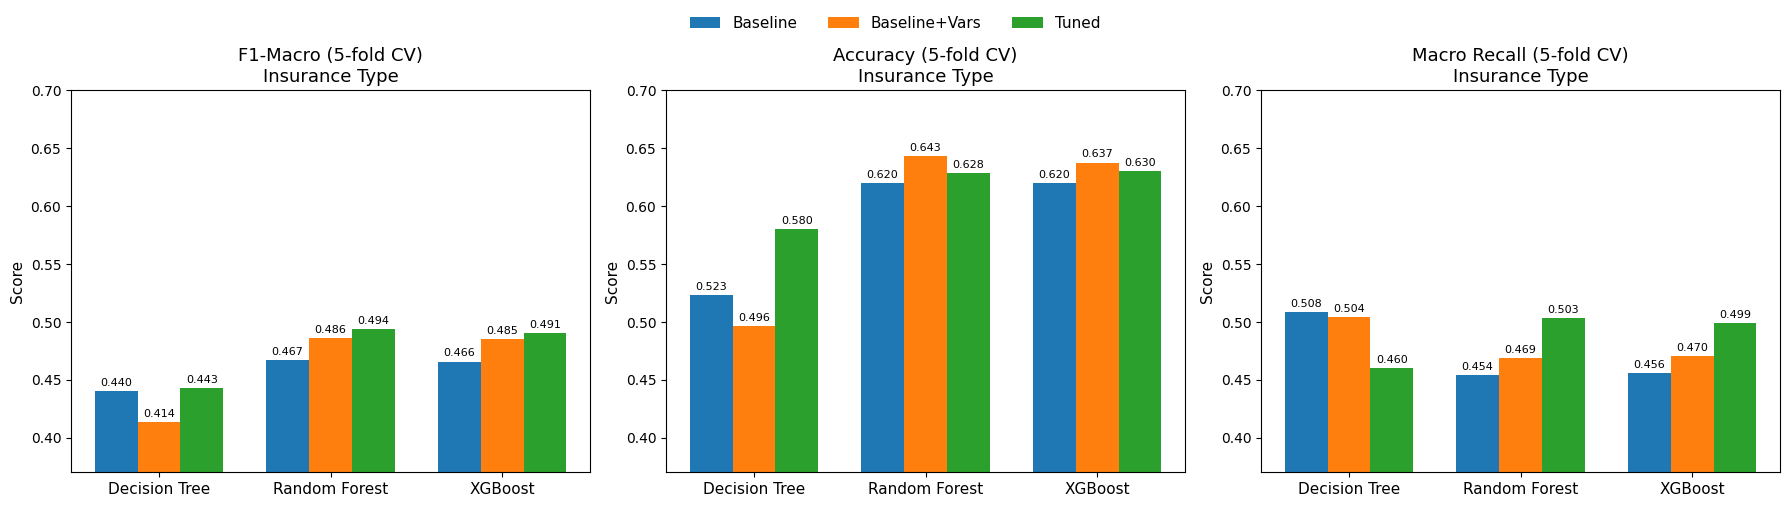

In [8]:
#Model Optimization and Comparison
import numpy as np
import matplotlib.pyplot as plt

models = ["Decision Tree", "Random Forest", "XGBoost"]
stages = ["Baseline", "Baseline+Vars", "Tuned"]

# F1-macro
f1 = np.array([
    [0.4401, 0.4136, 0.4426],
    [0.4666, 0.4859, 0.4940],
    [0.4656, 0.4853, 0.4906],
])

# Accuracy
acc = np.array([
    [0.5231, 0.4965, 0.5802],
    [0.6199, 0.6431, 0.6285],
    [0.6201, 0.6375, 0.6300],
])

# Macro Recall
rec = np.array([
    [0.5083, 0.5039, 0.4601],
    [0.4542, 0.4686, 0.5034],
    [0.4556, 0.4703, 0.4991],
])

def plot_grouped_subplot(ax, values, title, ylabel):
    x = np.arange(len(models))
    width = 0.25

    bars_all = []
    for i in range(3):
        bars = ax.bar(
            x + (i - 1) * width,
            values[:, i],
            width,
            label=stages[i]
        )
        bars_all.append(bars)

    ax.set_title(title + "\nInsurance Type", fontsize=13)
    ax.set_xticks(x)
    ax.set_xticklabels(models, fontsize=11)
    ax.set_ylabel(ylabel, fontsize=11)

    ax.set_ylim(0.37, 0.70)

    for bars in bars_all:
        for bar in bars:
            height = bar.get_height()
            ax.text(
                bar.get_x() + bar.get_width() / 2,
                height + 0.003,
                f"{height:.3f}",
                ha="center",
                va="bottom",
                fontsize=8
            )

    return bars_all

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

bars_f1 = plot_grouped_subplot(axes[0], f1, "F1-Macro (5-fold CV)", "Score")
bars_acc = plot_grouped_subplot(axes[1], acc, "Accuracy (5-fold CV)", "Score")
bars_rec = plot_grouped_subplot(axes[2], rec, "Macro Recall (5-fold CV)", "Score")

handles = [b[0] for b in bars_f1]
labels = stages

fig.legend(
    handles, labels,
    loc="upper center",
    ncol=3,
    frameon=False,
    fontsize=11,
    bbox_to_anchor=(0.5, 1.02)
)

plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.show()


**Model Performance Summary (Insurance Type Classification)**  

- **F1-Macro** was selected as **the primary metric** for **insurance type tuning**, as it **balances precision and recall** across all classes.
- Adding new features have significant improvements on model performance for Random Forest and XGBoost.
- Across all three evaluation metrics, **Random Forest and XGBoost** consistently outperform the Decision Tree baseline. **Random Forest achieves the highest overall F1-macro** and shows **strong improvements in macro recall** when additional engineered variables are included. **XGBoost delivers similarly competitive performance** with stable gains after hyperparameter tuning, particularly in recall-oriented metrics, indicating better handling of class imbalance. **Decision Trees**, while interpretable, **lag behind in predictive performance** across all metrics.

- Overall, the results suggest that **ensemble methods (esp. Random Forest) provide a more robust and generalizable solution** for the **multi-class insurance prediction task**.


FINAL MODEL PERFORMANCE ON TEST SET (insurance_type)
              precision    recall  f1-score   support

        Both       0.52      0.66      0.58       257
Private only       0.73      0.84      0.78       584
 Public only       0.66      0.49      0.56       625
   Uninsured       0.38      0.40      0.39       141
     Unknown       0.33      0.29      0.31        24

    accuracy                           0.63      1631
   macro avg       0.52      0.54      0.53      1631
weighted avg       0.63      0.63      0.63      1631



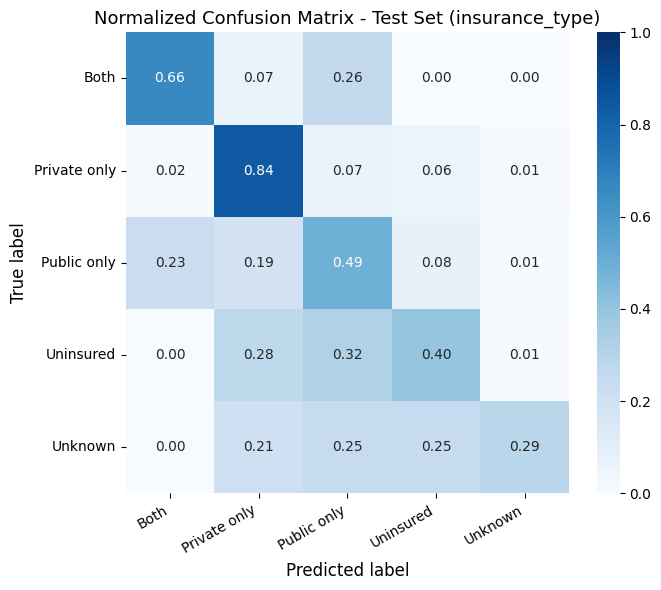

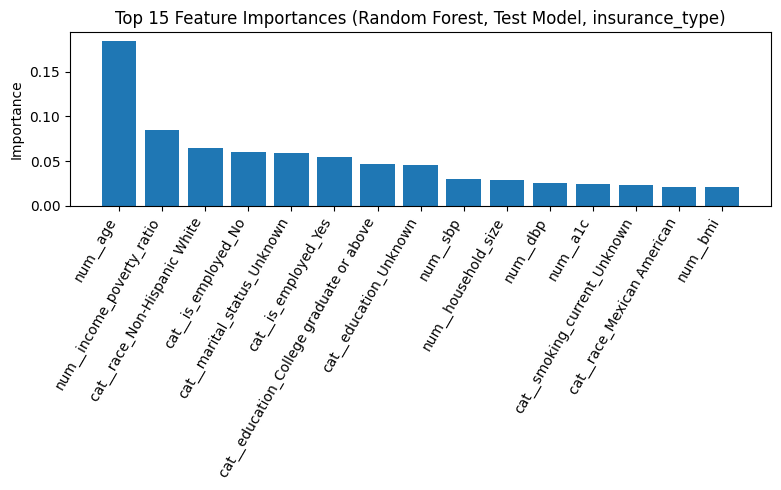

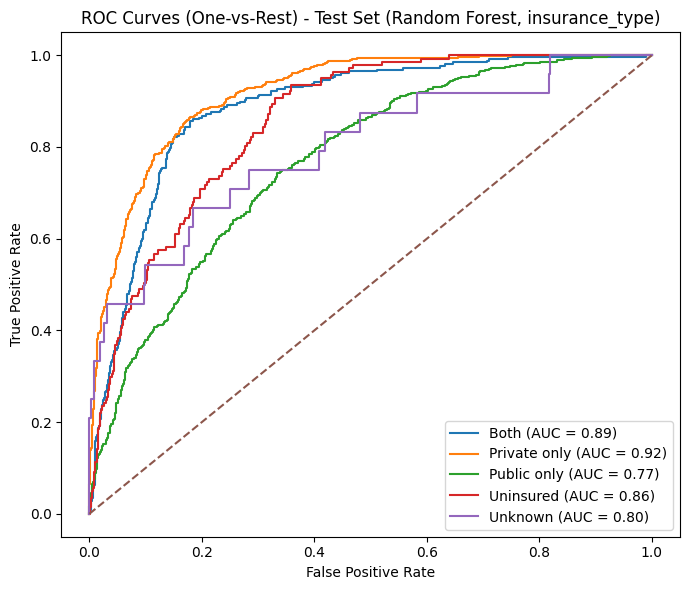

In [14]:
# Evaluate the model performance on test set
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
    roc_curve,
    auc,
)
import seaborn as sns
from sklearn.preprocessing import label_binarize

final_model_ins = best_models_ins[best_model_name]

# Final model prediction (numbers)
y_ins_pred_test = final_model_ins.predict(X_ins_test)

# Convert back to original category names using LabelEncoder
y_test_named = le_ins.inverse_transform(y_ins_test)
y_pred_named = le_ins.inverse_transform(y_ins_pred_test)

# Final model prediction (numbers)
y_ins_pred_test = final_model_ins.predict(X_ins_test)

# Convert back to original category names using LabelEncoder
y_test_named = le_ins.inverse_transform(y_ins_test)
y_pred_named = le_ins.inverse_transform(y_ins_pred_test)

print("\nFINAL MODEL PERFORMANCE ON TEST SET (insurance_type)")
print(classification_report(y_test_named, y_pred_named))

# Confusion Matrix
cm_norm = confusion_matrix(
    y_ins_test,
    y_ins_pred_test,
    normalize="true"
)

plt.figure(figsize=(7, 6))
sns.heatmap(
    cm_norm,
    annot=True,            # show numbers inside cells
    fmt=".2f",             # keep two decimals
    cmap="Blues",
    xticklabels=class_names,
    yticklabels=class_names,
    vmin=0.0,
    vmax=1.0
)
plt.title("Normalized Confusion Matrix - Test Set (insurance_type)", fontsize=13)
plt.xlabel("Predicted label", fontsize=12)
plt.ylabel("True label", fontsize=12)
plt.xticks(rotation=30, ha="right", fontsize=10)
plt.yticks(rotation=0, fontsize=10)
plt.tight_layout()
plt.savefig("confusion_matrix_insurance_type.png", dpi=300, bbox_inches="tight")
plt.show()


# Feature Importance

preprocessor = final_model_ins.named_steps["preprocess"]
rf_clf = final_model_ins.named_steps["clf"]
feature_names = preprocessor.get_feature_names_out()

importances = rf_clf.feature_importances_

top_k = 15 # Top15 key features
indices = np.argsort(importances)[::-1][:top_k]

plt.figure(figsize=(8, 5))
plt.bar(range(top_k), importances[indices])
plt.xticks(range(top_k), feature_names[indices], rotation=60, ha="right")
plt.ylabel("Importance")
plt.title("Top 15 Feature Importances (Random Forest, Test Model, insurance_type)")
plt.tight_layout()
plt.show()


# 3. ROC Curves（One-vs-Rest for multiple categories）

n_classes = len(le_ins.classes_)

y_test_bin = label_binarize(y_ins_test, classes=np.arange(n_classes))

# shape: [n_samples, n_classes]
y_score = final_model_ins.predict_proba(X_ins_test)

fpr = {}
tpr = {}
roc_auc = {}

for i in range(n_classes):
    fpr[i], tpr[i], _ = roc_curve(y_test_bin[:, i], y_score[:, i])
    roc_auc[i] = auc(fpr[i], tpr[i])

plt.figure(figsize=(7, 6))
for i in range(n_classes):
    plt.plot(
        fpr[i],
        tpr[i],
        label=f"{le_ins.classes_[i]} (AUC = {roc_auc[i]:.2f})"
    )

plt.plot([0, 1], [0, 1], "--")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curves (One-vs-Rest) - Test Set (Random Forest, insurance_type)")
plt.legend()
plt.tight_layout()
plt.show()

**1. Test Set Classification Report（precision/recall/F1）**

**Private-only is the best-predicted class** (F1 = 0.78), driven by clear employment and income signals.  
**Both (dual coverage) achieves moderate performance (F1 = 0.58)**, benefiting from distinguishable patterns among older groups but still **showing overlap with Public-only**.  
**Public-only is moderately predicted (F1 = 0.56)**, reflecting overlapping socioeconomic profiles with other groups.  
**Uninsured remains challenging (F1 = 0.39–0.31)**, indicating limited and noisy signal for these minority categories.  

**2. Confusion Matrix (Normalized)**

The model correctly **identifies the majority of Private-only (84%) and Both (66%) cases**, showing strong separation for insurance groups with distinct socioeconomic patterns.
**Most confusion occurs between Public-only vs. Both and Uninsured vs. Public-only**, reflecting real-world overlap in demographics and financial eligibility criteria.

**3. Feature Importance**

**Age and income–poverty ratio dominate prediction**, confirming **strong socioeconomic gradients** behind insurance type.  
**Race, employment, and education** collectively form **the next tier** of influential predictors, while **clinical measures (BP, A1C)** play a **smaller role**—highlighting that insurance coverage is driven much more by demographics than physiological health status.

**4. ROC Curves (One-vs-Rest AUC)**

**AUC scores are high for Private-only (0.92) and Both (0.89)**, showing excellent discriminative ability for the largest and most distinct groups.
**Lower AUC for Public-only (0.77)** reflects overlapping socioeconomic characteristics across public program users.
**Uninsured also performs well (AUC = 0.86)**.

## 5.2 Classification for Hypertension Risk Prediction
We define `hypertension_stage` from SBP/DBP into **Normal / Stage 1 / Stage 2**.

### 5.2.1 Baseline Models: Decision Tree, Random Forest, XGBoost

In [4]:
#Define Hypertension labels via the sbp and dbp
def classify_hypertension_stage(row):
    """
    Classify hypertension stage based on SBP/DBP.

    Returns:
        "Stage 2", "Stage 1", or "Normal"
        If sbp / dbp is missing, return None.
    """
    sbp = row["sbp"]
    dbp = row["dbp"]

    if pd.isna(sbp) or pd.isna(dbp):
        return None

    # Stage 2
    if sbp >= 140 or dbp >= 90:
        return "Stage 2"
    # Stage 1
    elif 130 <= sbp < 140 or 80 <= dbp < 90:
        return "Stage 1"
    # Normal + High-normal
    else:
        return "Normal"

# Create target column: hypertension_stage
nhanes_clean_adult_add["hypertension_stage"] = nhanes_clean_adult_add.apply(
    classify_hypertension_stage,
    axis=1
)

In [5]:
#ColumnTransformer + OnehotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder

# Feature & target for hypertension
hyp_feature_cols = [
    "age",
    "gender",
    "race",
    "education",
    "income_poverty_ratio",
    "marital_status",
    "household_size",
    "is_employed",
    "smoking_current",
    "diabetes_self_report",
    "bmi",
    "a1c",
    "sleep_hours",
    "insurance_type",
]

target_hyp = "hypertension_stage"

categorical_hyp = [
    "gender", "race", "education", "marital_status",
    "is_employed", "smoking_current", "diabetes_self_report", "insurance_type",
]

numeric_hyp = [
    "age", "income_poverty_ratio", "household_size",
    "bmi", "a1c", "sleep_hours",
]

# ColumnTransformer + OneHot
preprocess_hyp = ColumnTransformer(
    transformers=[
        ("cat", OneHotEncoder(handle_unknown="ignore", sparse_output=False), categorical_hyp),
        ("num", "passthrough", numeric_hyp),
    ]
)


In [6]:
#Train/Test Split + StratifiedKFold

from sklearn.model_selection import train_test_split, StratifiedKFold
from sklearn.preprocessing import LabelEncoder

# Build X, y and drop rows with missing features / target
X_hyp = nhanes_clean_adult_add[hyp_feature_cols].copy()
y_hyp = nhanes_clean_adult_add[target_hyp].copy()

data_hyp = (
    pd.concat([X_hyp, y_hyp], axis=1)
    .dropna(subset=hyp_feature_cols + [target_hyp])
)

X_hyp = data_hyp[hyp_feature_cols]
y_hyp = data_hyp[target_hyp]

# LabelEncode target: string → integer
le_hyp = LabelEncoder()
y_hyp_encoded = le_hyp.fit_transform(y_hyp)

# IDs of Stage 1 & Stage 2 after label encoding
stage_labels = le_hyp.transform(["Stage 1", "Stage 2"])

# Train/Test split
X_hyp_train, X_hyp_test, y_hyp_train, y_hyp_test = train_test_split(
    X_hyp,
    y_hyp_encoded,
    test_size=0.2,
    random_state=42,
    stratify=y_hyp_encoded,
)

# Stratified K-Fold (CV)
cv_hyp = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)


In [7]:
# Baseline models for hypertension and GridSearchCV for hypertension optimization
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier

from imblearn.over_sampling import SMOTE
from imblearn.pipeline import Pipeline
from sklearn.model_selection import cross_validate, GridSearchCV
from sklearn.metrics import make_scorer, recall_score

stage_labels = le_hyp.transform(["Stage 1", "Stage 2"])

def stage12_recall(y_true, y_pred):
    """
    Custom metric:
    average recall over Stage 1 and Stage 2 (ignore 'Normal').
    """
    recs = recall_score(
        y_true,
        y_pred,
        labels=stage_labels,   # only Stage 1 & Stage 2
        average=None,
        zero_division=0,
    )
    return recs.mean()

stage12_recall_scorer = make_scorer(stage12_recall)

#Baselin CV scoring
scoring_cv_hyp = {
    "accuracy": "accuracy",
    "recall_macro": "recall_macro",
    "recall_weighted": "recall_weighted",
    "f1_macro": "f1_macro",
    "stage12_recall": stage12_recall_scorer,  # NEW: focus on Stage 1 & 2
}

models_hyp = {
    "Decision_Tree": DecisionTreeClassifier(
        criterion="entropy",
        max_depth=5,
        min_samples_split=50,
        min_samples_leaf=10,
        random_state=42,
    ),
    "Random_Forest": RandomForestClassifier(
        n_estimators=400,
        max_depth=None,
        min_samples_split=5,
        max_features="sqrt",
        class_weight="balanced",
        random_state=42,
        n_jobs=2,
    ),
    "XGBoost": XGBClassifier(
        n_estimators=300,
        max_depth=5,
        learning_rate=0.05,
        subsample=0.8,
        colsample_bytree=0.8,
        objective="multi:softprob",
        eval_metric="mlogloss",
        random_state=42,
    ),
}

print("BASELINE CV PERFORMANCE (hypertension_stage)")
baseline_scores_hyp = {}

for name, clf in models_hyp.items():
    pipe = Pipeline([
        ("preprocess", preprocess_hyp),
        ("smote", SMOTE(random_state=42)),
        ("clf", clf),
    ])

    cv_res = cross_validate(
        pipe,
        X_hyp_train,
        y_hyp_train,
        cv=cv_hyp,
        scoring=scoring_cv_hyp,
        n_jobs=2,
        return_train_score=False,
    )

    acc_mean   = cv_res["test_accuracy"].mean()
    rec_mean   = cv_res["test_recall_macro"].mean()
    f1_mean    = cv_res["test_f1_macro"].mean()
    st12_mean  = cv_res["test_stage12_recall"].mean()  # NEW

    baseline_scores_hyp[name] = {
        "accuracy_cv": acc_mean,
        "recall_macro_cv": rec_mean,
        "f1_macro_cv": f1_mean,
        "stage12_recall_cv": st12_mean,   # NEW
    }

    print(f"\nHypertension {name} (baseline, all vars)")
    print("5-fold Accuracy per fold:", cv_res["test_accuracy"])
    print("5-fold Macro Recall per fold:", cv_res["test_recall_macro"])
    print("5-fold F1-macro per fold:", cv_res["test_f1_macro"])
    print("5-fold Stage1+2 Recall per fold:", cv_res["test_stage12_recall"])  # NEW
    print("Mean Accuracy:", acc_mean)
    print("Mean Macro Recall:", rec_mean)
    print("Mean F1-macro:", f1_mean)
    print("Mean Stage1+2 Recall:", st12_mean)

# GridSearch with Stage1+2 Recall as main metric
param_grids_hyp = {
    "Decision_Tree": {
        "clf__criterion": ["gini", "entropy"],
        "clf__max_depth": [3, 5, 10, None],
        "clf__min_samples_leaf": [1, 5, 10],
    },
    "Random_Forest": {
        "clf__n_estimators": [200, 400],
        "clf__max_depth": [None, 10, 20],
        "clf__min_samples_split": [2, 5],
        "clf__max_features": ["sqrt", "log2"],
    },
    "XGBoost": {
        "clf__n_estimators": [200, 300],
        "clf__max_depth": [3, 5],
        "clf__learning_rate": [0.05, 0.1],
        "clf__subsample": [0.8, 1.0],
        "clf__colsample_bytree": [0.8, 1.0],
    },
}

scoring_multi_hyp = {
    "stage12_recall": stage12_recall_scorer,  # MAIN metric
    "recall_macro": "recall_macro",
    "f1_macro": "f1_macro",
    "accuracy": "accuracy",
}

best_models_hyp = {}
tuned_scores_hyp = {}

print("\n\nGRIDSEARCH WITH STAGE1+2 RECALL (hypertension_stage)")

for name in ["Decision_Tree", "Random_Forest", "XGBoost"]:
    print(f"\n----- GridSearch for {name} on hypertension_stage (Stage1+2 Recall as main metric) -----")

    base_clf = models_hyp[name]

    pipe = Pipeline([
        ("preprocess", preprocess_hyp),
        ("smote", SMOTE(random_state=42)),
        ("clf", base_clf),
    ])

    grid = param_grids_hyp[name]

    gs = GridSearchCV(
        estimator=pipe,
        param_grid=grid,
        cv=cv_hyp,
        scoring=scoring_multi_hyp,
        refit="stage12_recall",   # <<< use Stage1+2 Recall to refit best model
        n_jobs=2,
    )

    gs.fit(X_hyp_train, y_hyp_train)

    best_models_hyp[name] = gs.best_estimator_

    cv_results = gs.cv_results_
    best_idx = gs.best_index_

    best_stage12 = cv_results["mean_test_stage12_recall"][best_idx]
    best_rec     = cv_results["mean_test_recall_macro"][best_idx]
    best_f1      = cv_results["mean_test_f1_macro"][best_idx]
    best_acc     = cv_results["mean_test_accuracy"][best_idx]

    tuned_scores_hyp[name] = {
        "stage12_recall_cv": best_stage12,
        "recall_macro_cv": best_rec,
        "f1_macro_cv": best_f1,
        "accuracy_cv": best_acc,
        "best_params": gs.best_params_,
    }

    print("Best params:", gs.best_params_)
    print(f"Best CV Stage1+2 Recall: {best_stage12:.4f}  (main metric)")
    print(f"Best CV Macro Recall:    {best_rec:.4f}")
    print(f"Best CV F1-macro:        {best_f1:.4f}")
    print(f"Best CV Accuracy:        {best_acc:.4f}")

print("\n\nSUMMARY: TUNED MODELS (CV, hypertension_stage)")
for name, metrics in tuned_scores_hyp.items():
    print(f"\n>>> {name}")
    print(f"  Accuracy (CV, tuned):        {metrics['accuracy_cv']:.4f}")
    print(f"  Macro Recall (CV, tuned):    {metrics['recall_macro_cv']:.4f}")
    print(f"  F1-macro (CV, tuned):        {metrics['f1_macro_cv']:.4f}")
    print(f"  Stage1+2 Recall (CV, tuned): {metrics['stage12_recall_cv']:.4f}")
    print(f"  Best Params: {metrics['best_params']}")

best_model_name_hyp = max(
    tuned_scores_hyp,
    key=lambda m: tuned_scores_hyp[m]["stage12_recall_cv"],
)

print(f"\n***** Best model by CV Stage1+2 Recall (hypertension_stage): {best_model_name_hyp} *****")
print("With scores:", tuned_scores_hyp[best_model_name_hyp])

final_model_hyp = best_models_hyp[best_model_name_hyp]


BASELINE CV PERFORMANCE (hypertension_stage)

Hypertension Decision_Tree (baseline, all vars)
5-fold Accuracy per fold: [0.548659   0.5394636  0.54754601 0.54064417 0.56211656]
5-fold Macro Recall per fold: [0.49253969 0.44969832 0.44942685 0.49580191 0.48925088]
5-fold F1-macro per fold: [0.44664869 0.39117773 0.42600758 0.45511193 0.44862064]
5-fold Stage1+2 Recall per fold: [0.43428975 0.35646839 0.35230769 0.45128205 0.41487179]
Mean Accuracy: 0.5476858707660484
Mean Macro Recall: 0.47534352927670903
Mean F1-macro: 0.4335133156161036
Mean Stage1+2 Recall: 0.4018439361933569

Hypertension Random_Forest (baseline, all vars)
5-fold Accuracy per fold: [0.65210728 0.65747126 0.66411043 0.66717791 0.66794479]
5-fold Macro Recall per fold: [0.36908089 0.38110838 0.37466734 0.39011228 0.38626445]
5-fold F1-macro per fold: [0.35858036 0.37587179 0.36041859 0.3858979  0.38124309]
5-fold Stage1+2 Recall per fold: [0.09542925 0.11347049 0.09367521 0.12136752 0.11333333]
Mean Accuracy: 0.661762

/opt/anaconda3/envs/ml310/lib/python3.10/site-packages/joblib/externals/loky/process_executor.py:782: UserWarning: A worker stopped while some jobs were given to the executor. This can be caused by a too short worker timeout or by a memory leak.
  warnings.warn(


Best params: {'clf__max_depth': 10, 'clf__max_features': 'sqrt', 'clf__min_samples_split': 5, 'clf__n_estimators': 200}
Best CV Stage1+2 Recall: 0.1454  (main metric)
Best CV Macro Recall:    0.3978
Best CV F1-macro:        0.3960
Best CV Accuracy:        0.6578

----- GridSearch for XGBoost on hypertension_stage (Stage1+2 Recall as main metric) -----
Best params: {'clf__colsample_bytree': 0.8, 'clf__learning_rate': 0.1, 'clf__max_depth': 5, 'clf__n_estimators': 300, 'clf__subsample': 1.0}
Best CV Stage1+2 Recall: 0.1583  (main metric)
Best CV Macro Recall:    0.4014
Best CV F1-macro:        0.4034
Best CV Accuracy:        0.6523


SUMMARY: TUNED MODELS (CV, hypertension_stage)

>>> Decision_Tree
  Accuracy (CV, tuned):        0.5638
  Macro Recall (CV, tuned):    0.5044
  F1-macro (CV, tuned):        0.4681
  Stage1+2 Recall (CV, tuned): 0.4465
  Best Params: {'clf__criterion': 'gini', 'clf__max_depth': 5, 'clf__min_samples_leaf': 10}

>>> Random_Forest
  Accuracy (CV, tuned):        

### 5.2.2 Model Comparison, Selection and Final Model Evaluation

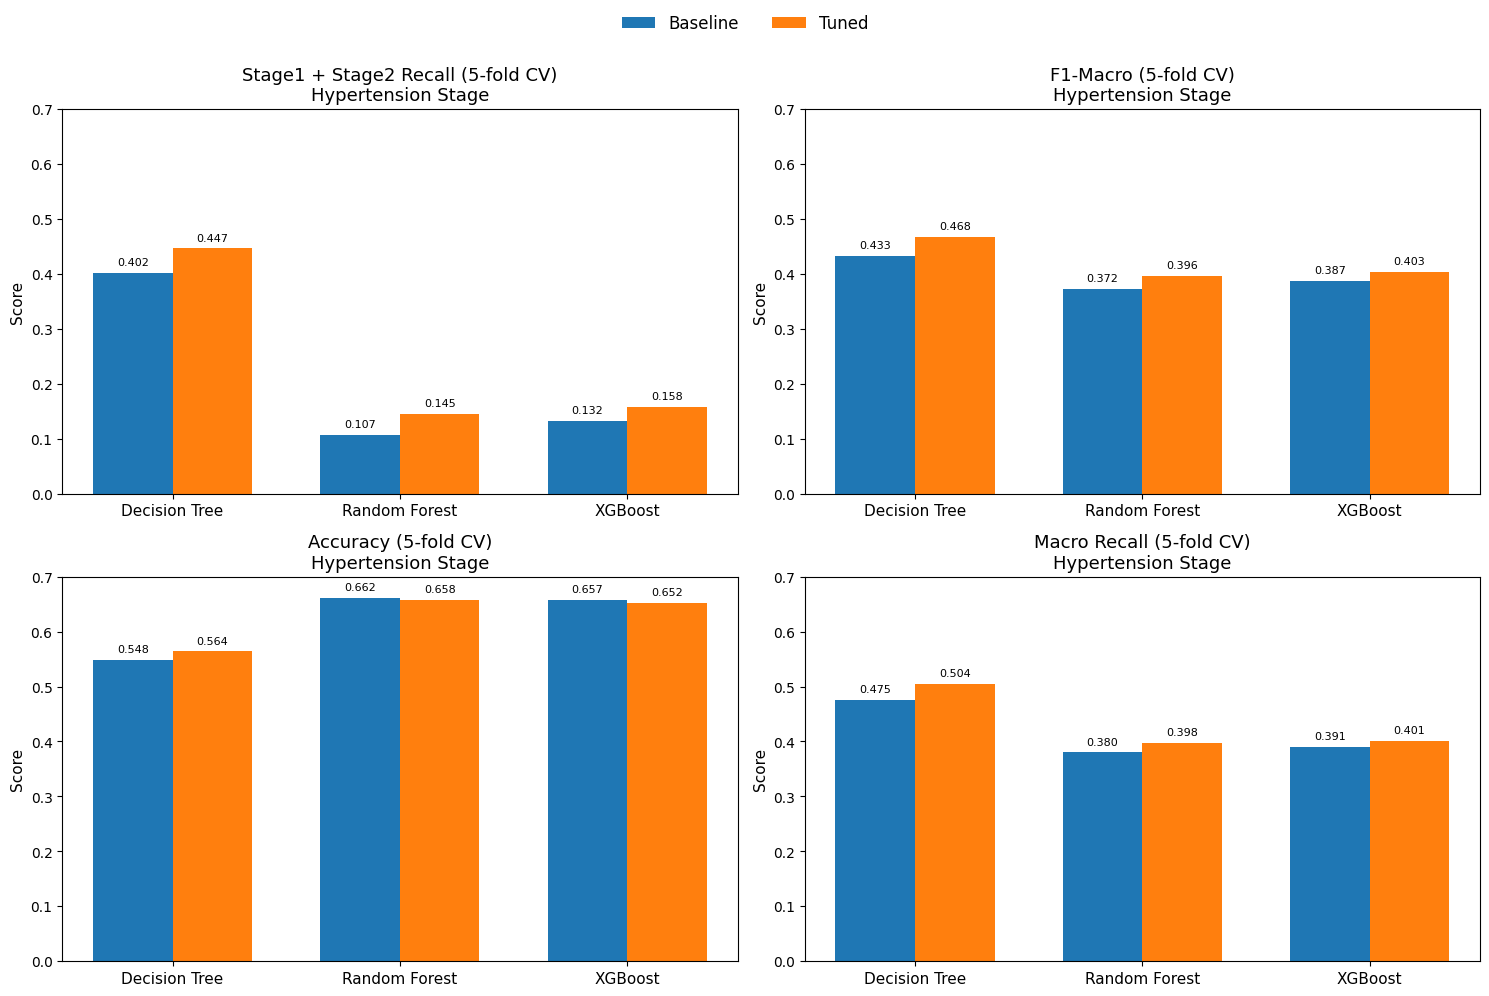

In [12]:
#Model Optimization and Comparison
import numpy as np
import matplotlib.pyplot as plt

models = ["Decision Tree", "Random Forest", "XGBoost"]
stages = ["Baseline", "Tuned"]


# Stage1 + Stage2 Recall (最重要)
rec12 = np.array([
    [0.4018, 0.4465],   # Decision Tree
    [0.1075, 0.1454],   # Random Forest
    [0.1321, 0.1583],   # XGBoost
])

# F1-macro
f1 = np.array([
    [0.4335, 0.4681],   # Decision Tree
    [0.3724, 0.3960],   # Random Forest
    [0.3868, 0.4034],   # XGBoost
])

# Accuracy
acc = np.array([
    [0.5477, 0.5638],   # Decision Tree
    [0.6618, 0.6578],   # Random Forest
    [0.6570, 0.6523],   # XGBoost
])

# Macro Recall
rec = np.array([
    [0.4753, 0.5044],   # Decision Tree
    [0.3802, 0.3978],   # Random Forest
    [0.3906, 0.4014],   # XGBoost
])


def plot_metric(ax, values, title):
    """
    ax:      matplotlib Axes
    values:  shape = (3 models, 2 stages)
    title:   subplot title
    """
    x = np.arange(len(models))
    width = 0.35   # two bars per group

    # bars
    for i in range(2):   # 0: Baseline, 1: Tuned
        ax.bar(
            x + (i - 0.5) * width,
            values[:, i],
            width,
            label=stages[i]
        )

    # title & axes
    ax.set_title(title + "\nHypertension Stage", fontsize=13)
    ax.set_xticks(x)
    ax.set_xticklabels(models, fontsize=11)
    ax.set_ylabel("Score", fontsize=11)

    # y-axis range
    ax.set_ylim(0.0, 0.7)

    # value labels
    for i in range(2):
        for j in range(len(models)):
            h = values[j, i]
            ax.text(
                x[j] + (i - 0.5) * width,
                h + 0.01,
                f"{h:.3f}",
                ha="center",
                va="bottom",
                fontsize=8
            )



fig, axes = plt.subplots(2, 2, figsize=(15, 10))

# Stage1+2 Recall, F1-macro
plot_metric(axes[0, 0], rec12, "Stage1 + Stage2 Recall (5-fold CV)")
plot_metric(axes[0, 1], f1, "F1-Macro (5-fold CV)")

# Accuracy, Macro Recall
plot_metric(axes[1, 0], acc, "Accuracy (5-fold CV)")
plot_metric(axes[1, 1], rec, "Macro Recall (5-fold CV)")

fig.legend(
    stages,
    loc="upper center",
    ncol=2,
    frameon=False,
    fontsize=12
)

plt.tight_layout(rect=[0, 0, 1, 0.95])
fig.savefig("model_comparison_hypertension.png", dpi=300, bbox_inches="tight")
plt.show()



**Model Comparison Summary (Hypertension Stage Classification)**

**Detecting Stage1 and Stage2 is our No.1 priority**. Based on this, a new metric - **Stage1 + Stage 2 Average Recall is defined as the primary metric for hyperparameter tuning**for hypetension stage prediction.  
Across all four evaluation metrics, **tuned models consistently outperform or match the baseline**, though the magnitude of improvement varies by algorithm and metric.  
**Stage 1 + Stage 2 Recall**: Tuning yields **the most noticeable gains** here.Tuning helps the models better **capture hypertensive individuals**, reducing false negatives.  
**F1-Macro**: All models show moderate improvements after tuning. **Balanced gains in precision and recall across classes**.  
**Accuracy**: Accuracy remains **relatively stable**. Overall correctness is already high; **tuning mainly affects minority class performance** rather than total accuracy.
**Macro Recall**: Tuning provides consistent but **modest improvements**. Better recovery of underrepresented classes after tuning.

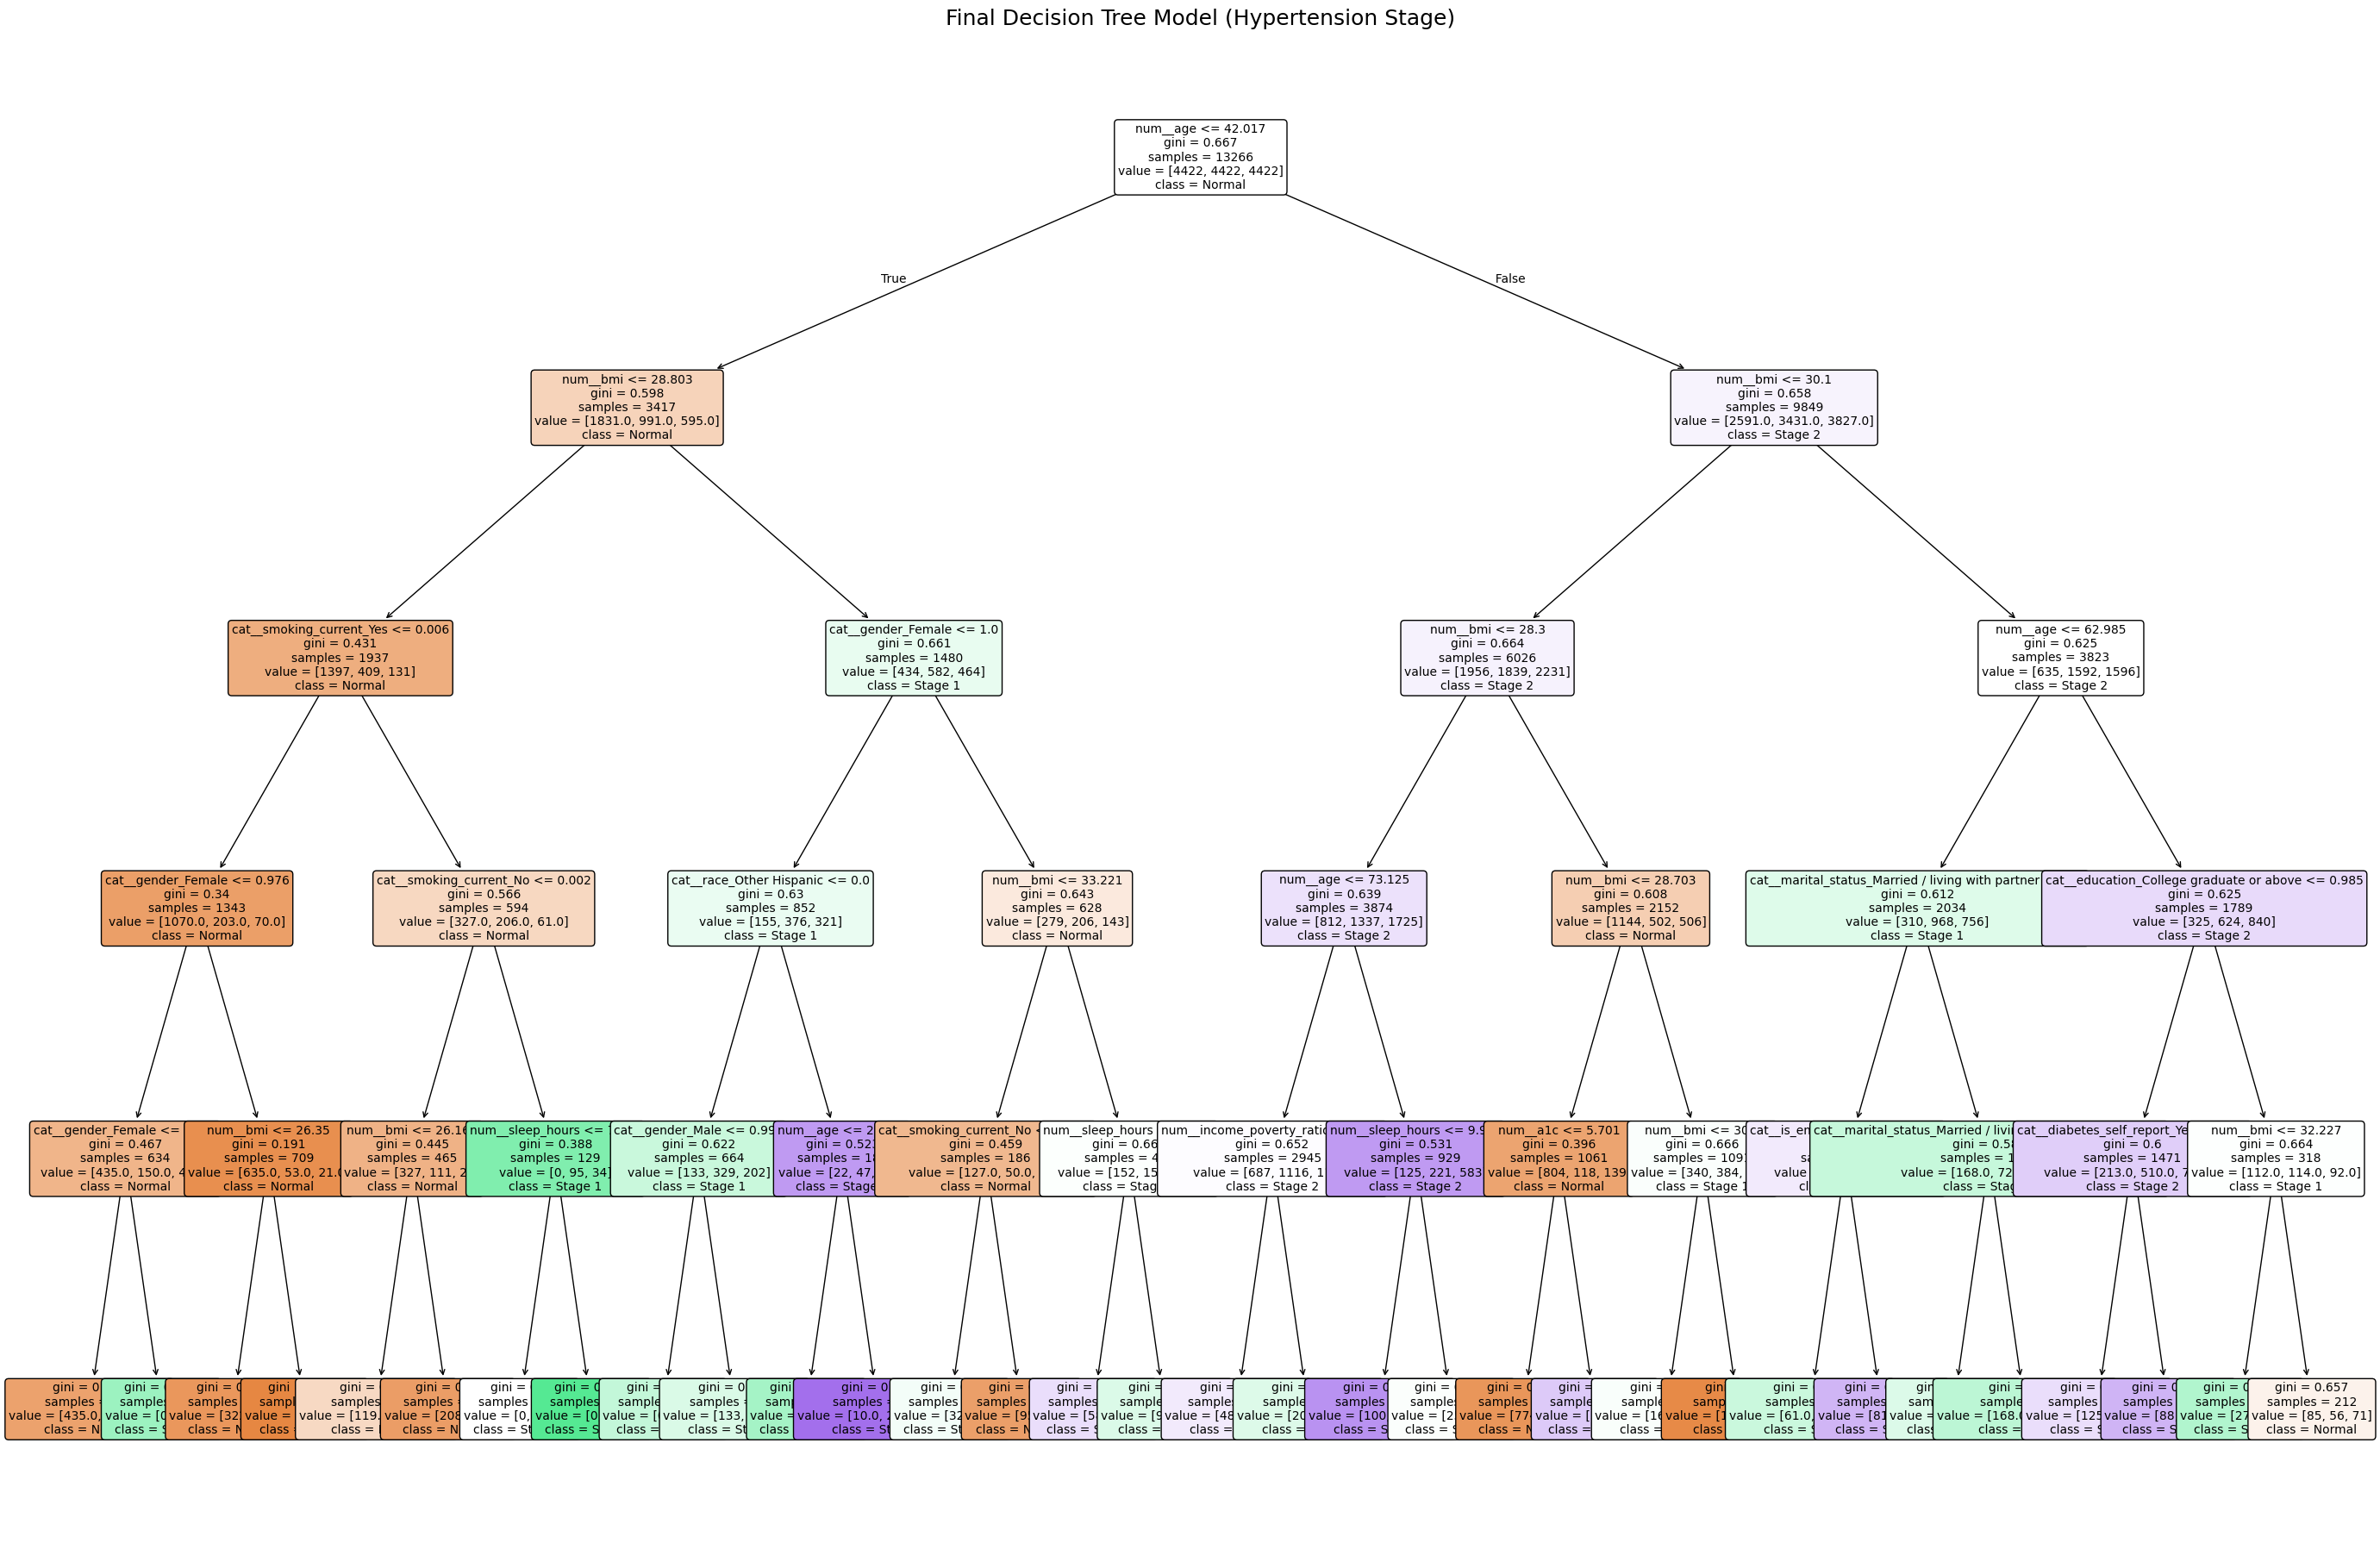

In [8]:
#Decision Tree visualization

from sklearn.tree import plot_tree
import matplotlib.pyplot as plt

best_tree = final_model_hyp.named_steps["clf"]

plt.figure(figsize=(28, 18))
plot_tree(
    best_tree,
    feature_names=final_model_hyp.named_steps["preprocess"]
                    .get_feature_names_out(),
    class_names=le_hyp.classes_,
    filled=True,
    rounded=True,
    fontsize=10
)

plt.title("Final Decision Tree Model (Hypertension Stage)", fontsize=18)
plt.tight_layout()
plt.savefig("Final Decision Tree Model (Hypertension Stage).png", dpi=300, bbox_inches="tight")
plt.show()

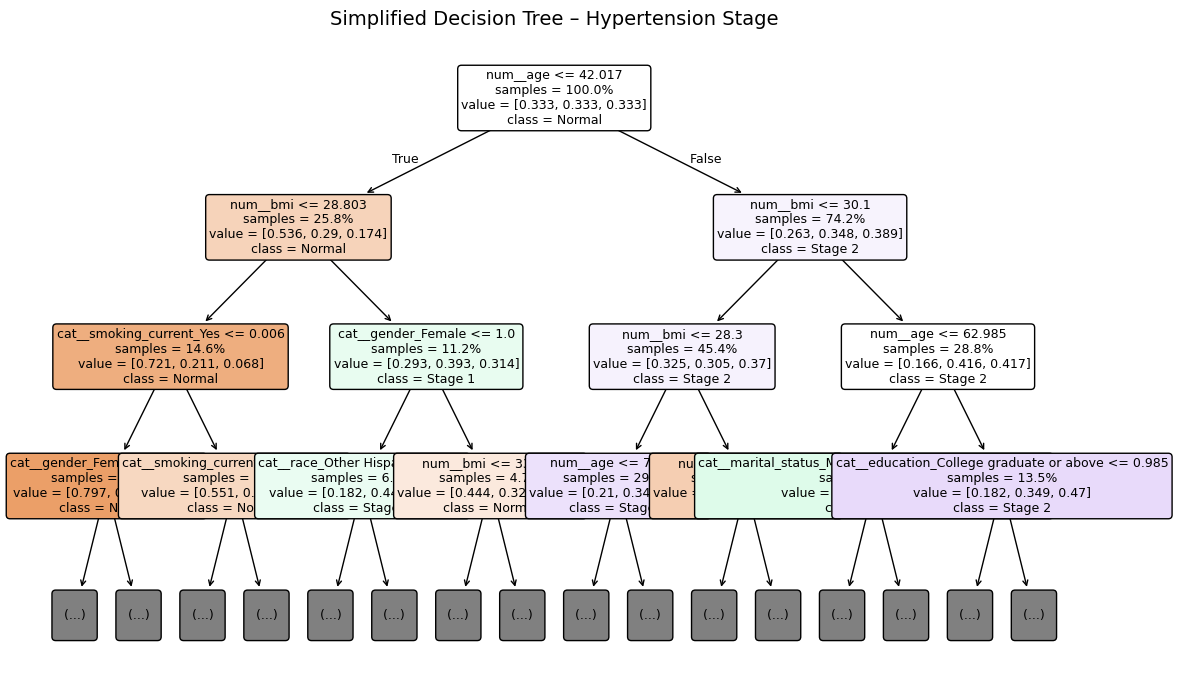

In [21]:
# Simplified Decision Tree Visualization for Presentation (max_depth=3)
from sklearn.tree import plot_tree
import matplotlib.pyplot as plt

tree_clf = final_model_hyp.named_steps["clf"]

feature_names = final_model_hyp.named_steps["preprocess"].get_feature_names_out()

class_names = le_hyp.classes_

plt.figure(figsize=(12, 7))

plot_tree(
    tree_clf,
    feature_names=feature_names,
    class_names=class_names,
    filled=True,          
    rounded=True,         
    max_depth=3,          
    impurity=False,       
    proportion=True,      
    fontsize=9
)

plt.title("Simplified Decision Tree – Hypertension Stage", fontsize=14)
plt.tight_layout()
plt.savefig("decision_tree_hyp_simplified.png", dpi=300, bbox_inches="tight")
plt.show()



FINAL MODEL PERFORMANCE ON TEST SET (hypertension_stage)
              precision    recall  f1-score   support

      Normal       0.88      0.54      0.67      1106
     Stage 1       0.25      0.38      0.30       282
     Stage 2       0.26      0.57      0.36       243

    accuracy                           0.52      1631
   macro avg       0.47      0.50      0.44      1631
weighted avg       0.68      0.52      0.56      1631



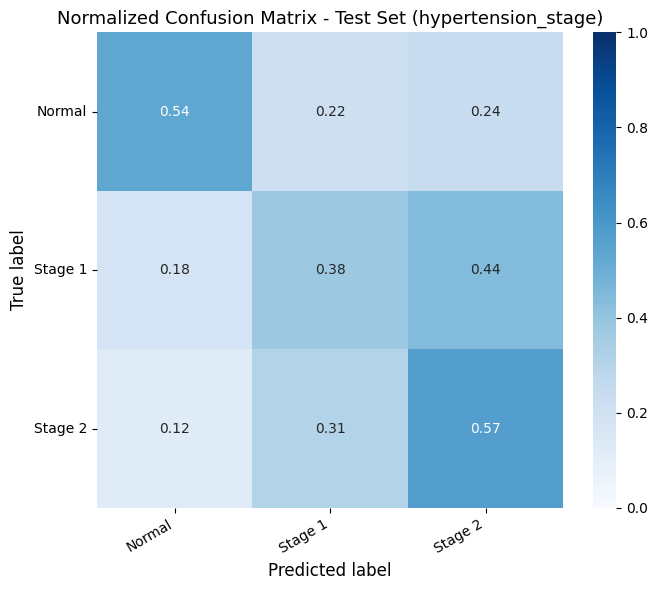

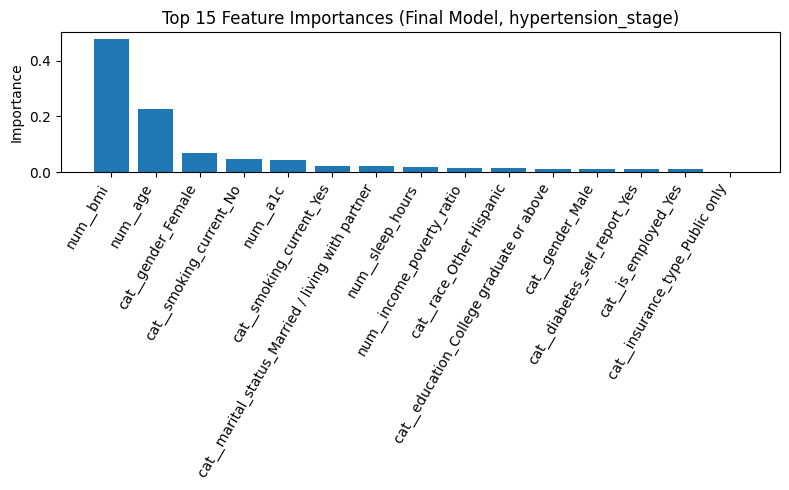

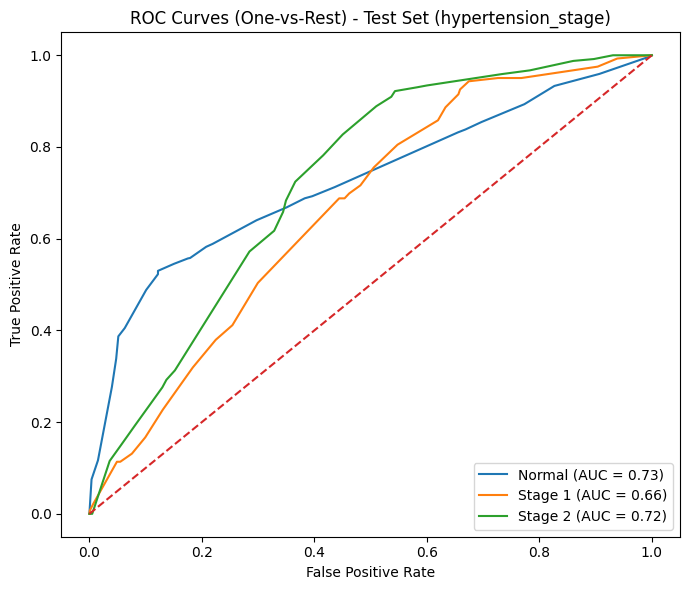

In [55]:
# Evaluate final hypertension moddel on test set

from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
    roc_curve,
    auc,
)
import seaborn as sns
from sklearn.preprocessing import label_binarize

# Final model
final_model_hyp = best_models_hyp[best_model_name_hyp]

#Test prediction
y_hyp_pred_test = final_model_hyp.predict(X_hyp_test)

y_test_named_hyp = le_hyp.inverse_transform(y_hyp_test)
y_pred_named_hyp = le_hyp.inverse_transform(y_hyp_pred_test)

print("\nFINAL MODEL PERFORMANCE ON TEST SET (hypertension_stage)")
print(classification_report(y_test_named_hyp, y_pred_named_hyp))

# Confusion Matrix
cm_norm_hyp = confusion_matrix(
    y_hyp_test,
    y_hyp_pred_test,
    normalize="true"
)

class_names_hyp = le_hyp.classes_   # ["Normal", "Stage 1", "Stage 2"]

plt.figure(figsize=(7, 6))
sns.heatmap(
    cm_norm_hyp,
    annot=True,
    fmt=".2f",
    cmap="Blues",
    xticklabels=class_names_hyp,
    yticklabels=class_names_hyp,
    vmin=0.0,
    vmax=1.0
)
plt.title("Normalized Confusion Matrix - Test Set (hypertension_stage)", fontsize=13)
plt.xlabel("Predicted label", fontsize=12)
plt.ylabel("True label", fontsize=12)
plt.xticks(rotation=30, ha="right", fontsize=10)
plt.yticks(rotation=0, fontsize=10)
plt.tight_layout()
plt.savefig("confusion_matrix_hypertension_stage.png", dpi=300, bbox_inches="tight")
plt.show()


# Feature Importance (Top 15)
preprocessor_hyp = final_model_hyp.named_steps["preprocess"]
clf_hyp = final_model_hyp.named_steps["clf"]

feature_names_hyp = preprocessor_hyp.get_feature_names_out()
importances_hyp = clf_hyp.feature_importances_

top_k = 15
indices_hyp = np.argsort(importances_hyp)[::-1][:top_k]

plt.figure(figsize=(8, 5))
plt.bar(range(top_k), importances_hyp[indices_hyp])
plt.xticks(range(top_k), feature_names_hyp[indices_hyp], rotation=60, ha="right")
plt.ylabel("Importance")
plt.title("Top 15 Feature Importances (Final Model, hypertension_stage)")
plt.tight_layout()
plt.savefig("feature_importance_hypertension_stage.png", dpi=300, bbox_inches="tight")
plt.show()


# ROC Curves（One-vs-Rest，Multiple categories）
n_classes_hyp = len(le_hyp.classes_)

y_test_bin_hyp = label_binarize(y_hyp_test, classes=np.arange(n_classes_hyp))

y_score_hyp = final_model_hyp.predict_proba(X_hyp_test)

fpr_hyp = {}
tpr_hyp = {}
roc_auc_hyp = {}

for i in range(n_classes_hyp):
    fpr_hyp[i], tpr_hyp[i], _ = roc_curve(y_test_bin_hyp[:, i], y_score_hyp[:, i])
    roc_auc_hyp[i] = auc(fpr_hyp[i], tpr_hyp[i])

plt.figure(figsize=(7, 6))
for i in range(n_classes_hyp):
    plt.plot(
        fpr_hyp[i],
        tpr_hyp[i],
        label=f"{le_hyp.classes_[i]} (AUC = {roc_auc_hyp[i]:.2f})"
    )

plt.plot([0, 1], [0, 1], "--")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curves (One-vs-Rest) - Test Set (hypertension_stage)")
plt.legend(
    loc="lower right",
    fontsize=10,
    frameon=True
)
plt.tight_layout()
plt.savefig("roc_curves_hypertension_stage.png", dpi=300, bbox_inches="tight")
plt.show()

**1. Test Set Classification Report (precision / recall / F1**  

Because hypertension prediction is **a clinical risk-screening task**, **recall is the key evaluation metric**, as failing to **identify hypertensive individuals (false negatives)** is more harmful than flagging borderline cases.  
**Stage 2** achieves the highest recall (0.57), indicating that the model is comparatively effective at **detecting severe hypertension**, which aligns with clearer **physiological patterns** (older age, higher BMI).  
**Stage 1**, however, has substantially lower recall (0.38), reflecting its **clinical ambiguity—Stage 1 individuals overlap strongly with Normal and Stage 2 groups** in BMI, age, and lifestyle factors, making them **the most difficult class to recover**.    
**The Normal class** achieves moderate recall (0.54) but benefits from **its large representation** in the dataset, which stabilizes its classification performance.    

**2. Confusion Matrix (Normalized)**

The model correctly identifies **54% of Normal cases**, but also **misclassifies 22% as Stage 1 and 24% as Stage 2**.
**Stage 2 is recovered relatively well (57% recall)**, showing the model captures the more severe hypertension patterns.
**Stage 1 exhibits the most confusion**:
- **38% correctly predicted**,
- 18% misclassified as Normal,
- **44% predicted as Stage 2**.
This pattern reflects early-stage hypertension is harder to separate from Normal and Stage 2 groups based on current variables.

**3. Top Feature Importances**

**BMI and Age overwhelmingly dominate prediction**, confirming strong epidemiological associations with hypertension risk.  
**Behavioral and metabolic factors** such as **current smoking, A1C, and sleep hours** contribute **additional predictive signal**.  
**Socioeconomic variables (education, income-poverty ratio, employment)** appear but play a **secondary role** compared to direct physiological indicators.  
Insurance type alone contributes minimally, showing that hypertension status is **primarily clinically driven**, **not demographically driven**.  

**4. ROC Curves (One-vs-Rest AUC)**

The model demonstrates relatively **strong discriminative ability for Normal (AUC = 0.73) and Stage 2 (AUC = 0.72)**.  
**Stage 1 has a lower AUC (0.66)**, consistent with **its intermediate nature and overlap with both adjacent classes**.  
This pattern reflects **real-world difficulty**: **mild hypertension is the hardest to clinically identify**, whereas severe hypertension exhibits clearer physiological separation.  

# 6. Clustering

## 6.1 Study Objective

The goal of this clustering analysis is to identify meaningful population subgroups with distinct
**hypertension risk profiles**, **lifestyle behaviors**, and **health insurance coverage patterns**.

We use **SBP (systolic blood pressure)** and **DBP (diastolic blood pressure)** to define hypertension levels,
and aim to uncover subpopulations such as:

- High-risk hypertensive adults with poor insurance access  
- Low-risk young adults with higher uninsured rates  
- Moderate-risk groups with identifiable lifestyle characteristics  

These insights can inform targeted public health interventions and identify high-risk populations
who may benefit from improved healthcare access.

In [50]:
import pandas as pd

df = pd.read_csv("/Users/wmhjoy/Data_Mining_Project/data/processed/nhanes_clean_adult_add.csv")

df.shape
df.head()

,id,age,gender,race,education,income_poverty_ratio,weight_kg,height_cm,bmi,sbp,...,smoking_ever,physical_activity_freq,sleep_hours,diabetes_self_report,has_health_insurance,doctor_visit_12m,insurance_type,marital_status,household_size,is_employed
0,130378.0,43.0,Male,Non-Hispanic Asian,College graduate or above,5.00,86.9,179.5,27.0,135.0,...,Unknown,45.0,9.5,No,Insured,Yes,Private only,Married / living with partner,4.0,Yes
1,130379.0,66.0,Male,Non-Hispanic White,College graduate or above,5.00,101.8,174.2,33.5,121.0,...,Unknown,45.0,9.0,No,Insured,Unknown,Both,Married / living with partner,2.0,Yes
2,130380.0,44.0,Female,Other Hispanic,High school/GED,1.41,69.4,152.9,29.7,111.0,...,Unknown,30.0,8.0,Yes,Insured,Unknown,Public only,Married / living with partner,7.0,Yes
3,130384.0,43.0,Male,Mexican American,9-11th grade,0.63,87.5,176.0,28.3,120.0,...,Unknown,60.0,7.5,No,Not insured,Unknown,Uninsured,Never married,2.0,Yes
4,130385.0,65.0,Female,Non-Hispanic White,High school/GED,5.00,72.7,159.2,28.7,127.0,...,Unknown,60.0,8.0,No,Insured,No,Public only,Married / living with partner,2.0,No


## 6.2 Feature Selection and Preprocessing

We selected a combination of:

**(1) Physiological Health Indicators**
- SBP(Systolic Blood Pressure)  
- DBP(Diastolic Blood Pressure)  
- BMI(Body Mass Index)  
- A1C (Glycemic biomarker) 

**(2) Behavioral Health & Lifestyle Factors**
- Sleep hours (behavioral-health determinant)
- Smoking status (smoking_current) 

**(3) Demographic**
- Age  
- Gender  
- Race
  
**(4) Socioeconomic Variables (SES)**
- Education 
- Employment  
- Household size
- Income-to-poverty ratio
- Marital status  

**(5) Insurance Coverage**
Used for profiling *BUT NOT* included in clustering input.

**Justification:**
To prevent outcome-driven or access-driven clusters, we intentionally exclude:
- **Insurance type**– reflects healthcare access, not underlying health or behavior
- **Hypertension stage(derived from SBP/DBP)**– an outcome variable directly computed from SBP/DBP, which are already included in the model
- **diabetes_self_report**– a disease outcome that could dominate clustering

These variables are later used for *cluster interpretation*, allowing us to evaluate how clinically relevant outcomes differ after clusters are formed, rather than letting these outcomes determine the clusters themselves.

In [51]:
numeric_features = [
    "age",
    "income_poverty_ratio",
    "bmi",
    "sbp",
    "dbp",
    "a1c",
    "sleep_hours",
    "household_size"
]
categorical_features = [
    "gender",
    "race",
    "education",
    "marital_status",
    "is_employed",
    "smoking_current"
]
clustering_features = numeric_features + categorical_features

df_cluster = df[clustering_features].copy()
df_cluster.head()

,age,income_poverty_ratio,bmi,sbp,dbp,a1c,sleep_hours,household_size,gender,race,education,marital_status,is_employed,smoking_current
0,43.0,5.00,27.0,135.0,98.0,5.6,9.5,4.0,Male,Non-Hispanic Asian,College graduate or above,Married / living with partner,Yes,Yes
1,66.0,5.00,33.5,121.0,84.0,5.6,9.0,2.0,Male,Non-Hispanic White,College graduate or above,Married / living with partner,Yes,Yes
2,44.0,1.41,29.7,111.0,79.0,6.2,8.0,7.0,Female,Other Hispanic,High school/GED,Married / living with partner,Yes,No
3,43.0,0.63,28.3,120.0,77.0,5.4,7.5,2.0,Male,Mexican American,9-11th grade,Never married,Yes,No
4,65.0,5.00,28.7,127.0,74.0,5.7,8.0,2.0,Female,Non-Hispanic White,High school/GED,Married / living with partner,No,No


In [52]:
from sklearn.preprocessing import StandardScaler

df_processed = df_cluster.copy()

for col in categorical_features:
    df_processed[col] = df_processed[col].astype(str)

scaler = StandardScaler()
df_processed[numeric_features] = scaler.fit_transform(df_processed[numeric_features])

df_processed.head()

,age,income_poverty_ratio,bmi,sbp,dbp,a1c,sleep_hours,household_size,gender,race,education,marital_status,is_employed,smoking_current
0,-0.492907,1.407966,-0.355640,0.792494,2.324926,-0.098965,1.092785,0.927300,Male,Non-Hispanic Asian,College graduate or above,Married / living with partner,Yes,Yes
1,0.746857,1.407966,0.640394,-0.057776,0.926581,-0.098965,0.781830,-0.419023,Male,Non-Hispanic White,College graduate or above,Married / living with partner,Yes,Yes
2,-0.439004,-0.945190,0.058097,-0.665112,0.427172,0.529187,0.159921,2.946786,Female,Other Hispanic,High school/GED,Married / living with partner,Yes,No
3,-0.492907,-1.456461,-0.156433,-0.118510,0.227408,-0.308349,-0.151034,-0.419023,Male,Mexican American,9-11th grade,Never married,Yes,No
4,0.692954,1.407966,-0.095139,0.306625,-0.072238,0.005727,0.159921,-0.419023,Female,Non-Hispanic White,High school/GED,Married / living with partner,No,No


## 6.3 Clustering Model: K-Prototypes

We apply **K-Prototypes** because the dataset contains both:

- Numerical variables (SBP, DBP, BMI, Age)
- Categorical variables (Smoking, Education, Employment)

K-Prototypes simultaneously minimizes:
- Euclidean distance for numeric features
- Matching dissimilarity for categorical features

We select **k = 4** based on:
- Medical interpretability (HTN severity)
- Elbow method results
- Cluster size stability

In [53]:
from kmodes.kprototypes import KPrototypes
import numpy as np

data_matrix = df_processed.to_numpy()

cost = []
K_range = [3, 4, 5]

for k in K_range:
    kproto = KPrototypes(n_clusters=k, init='Cao', n_init=5, verbose=0, random_state=42)
    clusters = kproto.fit_predict(data_matrix, categorical=[df_processed.columns.get_loc(c) for c in categorical_features])
    cost.append(kproto.cost_)

cost

[60476.64544585903, 56258.98218366698, 52183.574581189736]

In [54]:
best_k = 4

kproto_final = KPrototypes(
    n_clusters=best_k,
    init='Cao',
    n_init=5,
    verbose=0,
    random_state=42
)

clusters = kproto_final.fit_predict(
    data_matrix,
    categorical=[df_processed.columns.get_loc(c) for c in categorical_features]
)

df_processed['cluster'] = clusters

df_processed.groupby('cluster')[numeric_features].mean()

for col in categorical_features:
    print(col)
    print(df_processed.groupby('cluster')[col].value_counts(normalize=True))
    print("------")

gender
cluster  gender
0        Female    0.582833
         Male      0.417167
1        Female    0.638411
         Male      0.361589
2        Male      0.554516
         Female    0.445484
3        Female    0.547902
         Male      0.452098
Name: proportion, dtype: float64
------
race
cluster  race              
0        Non-Hispanic White    0.624827
         Non-Hispanic Black    0.127365
         Other Hispanic        0.085833
         Other Race / Multi    0.075681
         Mexican American      0.046608
         Non-Hispanic Asian    0.039686
1        Non-Hispanic White    0.425166
         Other Hispanic        0.157174
         Non-Hispanic Black    0.147020
         Mexican American      0.135982
         Other Race / Multi    0.076821
         Non-Hispanic Asian    0.057837
2        Non-Hispanic White    0.702604
         Non-Hispanic Black    0.076485
         Non-Hispanic Asian    0.068755
         Other Hispanic        0.065500
         Other Race / Multi    0.046786


In [55]:
df_processed.columns

Index(['age', 'income_poverty_ratio', 'bmi', 'sbp', 'dbp', 'a1c',
       'sleep_hours', 'household_size', 'gender', 'race', 'education',
       'marital_status', 'is_employed', 'smoking_current', 'cluster'],
      dtype='object')

In [56]:
df_raw = pd.read_csv("/Users/wmhjoy/Data_Mining_Project/data/processed/nhanes_clean_adult_add.csv")
df_raw.columns

Index(['id', 'age', 'gender', 'race', 'education', 'income_poverty_ratio',
       'weight_kg', 'height_cm', 'bmi', 'sbp', 'dbp', 'a1c', 'glucose',
       'smoking_current', 'smoking_ever', 'physical_activity_freq',
       'sleep_hours', 'diabetes_self_report', 'has_health_insurance',
       'doctor_visit_12m', 'insurance_type', 'marital_status',
       'household_size', 'is_employed'],
      dtype='object')

In [57]:
print(len(df_raw), len(df_processed))

df_raw['cluster'] = df_processed['cluster'].values

8153 8153


## 6.4 Clustering Results

Each individual in the dataset was assigned to one of four clusters.
We mapped each cluster to an interpretable label using hypertension severity
(SBP/DBP distribution) and insurance coverage characteristics.


In [58]:
cluster_labels = {
    0: "Moderate HTN, mostly public insured",
    1: "Low-risk, mixed public/private & more uninsured",
    2: "Mild HTN, mainly privately insured",
    3: "Severe HTN, mixed insurance coverage"
}

df_raw["cluster_label"] = df_raw["cluster"].map(cluster_labels)

df_raw[["cluster", "cluster_label"]].head()

,cluster,cluster_label
0,3,"Severe HTN, mixed insurance coverage"
1,2,"Mild HTN, mainly privately insured"
2,1,"Low-risk, mixed public/private & more uninsured"
3,1,"Low-risk, mixed public/private & more uninsured"
4,2,"Mild HTN, mainly privately insured"


## 6.5 Cluster Summary Table

The table below lists each of the four clusters and their corresponding descriptive labels.
These labels were derived based on hypertension severity (SBP/DBP levels), socioeconomic
patterns, and insurance coverage profiles observed in each cluster.

This summary serves as a reference point for all subsequent analyses.


In [59]:
summary_table = (
    df_raw[["cluster", "cluster_label"]]
    .drop_duplicates()
    .sort_values("cluster")
    .reset_index(drop=True)
)

summary_table

,cluster,cluster_label
0,0,"Moderate HTN, mostly public insured"
1,1,"Low-risk, mixed public/private & more uninsured"
2,2,"Mild HTN, mainly privately insured"
3,3,"Severe HTN, mixed insurance coverage"


## 6.6 Cluster Size Distribution

The bar chart below shows how many individuals fall into each cluster.  
Examining cluster size is crucial because:

- It reveals whether certain hypertension–lifestyle patterns dominate the population.
- It ensures clusters are reasonably balanced.
- It avoids over-interpreting very small clusters.

A balanced distribution increases the reliability of downstream interpretation.


8153 8153


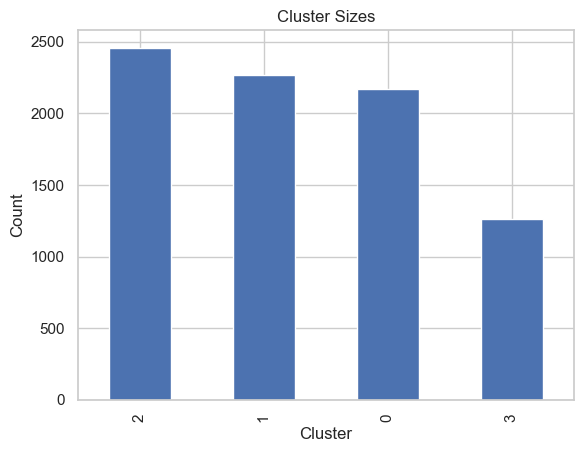

In [60]:
import matplotlib.pyplot as plt

print(len(df_raw), len(df_processed))

df_raw['cluster'] = df_processed['cluster'].values

df_raw['cluster'].value_counts().plot(kind='bar')
plt.title("Cluster Sizes")
plt.xlabel("Cluster")
plt.ylabel("Count")
plt.show()

## 6.7 Cluster Validity and Model Quality
Evaluating the quality and stability of clustering results is essential for ensuring that the identified groups are meaningful and interpretable.

Given the mixed data types in this dataset, the clustering analysis was performed using K-Prototypes and evaluated using **Gower distance–based silhouette scores**, **Intra-cluster variance**, and **cluster centroids**.

### 6.7.1 Silhouette Score
We computed the Silhouette Score using the Gower distance matrix, which is appropriate for **mixed numerical–categorical data**.

In [61]:
import gower
from sklearn.metrics import silhouette_score

gower_dist = gower.gower_matrix(df_processed.drop(columns=['cluster']))

sil_score = silhouette_score(gower_dist, df_processed['cluster'],
                             metric='precomputed')
print("Silhouette Score:", sil_score)

Silhouette Score: 0.075912684


**Silhouette Score Interpretation**

The silhouette score for the 4-cluster K-Prototypes model is **0.076**, which is close to zero.
This indicates that **clusters overlap substantially**, and the separation between groups is not strong.

This pattern is expected because:

- Health metrics (SBP, DBP, BMI, A1C) naturally overlap across individuals

- Socioeconomic variables (education, income, employment) vary gradually rather than being clearly separated

- Insurance types do not form distinct natural clusters in the population

- Mixed-type distance metrics (Gower) typically yield lower silhouette scores

Therefore, the clustering should be interpreted as identifying meaningful subpopulation patterns, rather than discovering naturally well-separated groups.

### 6.7.2 Intra-cluster Variance
To assess the internal consistency of each cluster, we compute the within-cluster variance for all numerical attributes. Lower variance indicates tighter grouping and higher internal similarity, while higher variance reflects more heterogeneous populations.

In [80]:
intra_var = df_processed.groupby("cluster")[numeric_features].var()
print("Intra-cluster variance:")
print(intra_var)

Intra-cluster variance:
              age  income_poverty_ratio       bmi       sbp       dbp  \
cluster                                                                 
0        0.294453              0.517300  0.594065  0.638280  0.582088   
1        0.426346              0.601847  0.900614  0.346528  0.537153   
2        0.680614              0.293532  0.587659  0.468653  0.549163   
3        0.534743              0.904916  1.900174  1.349725  1.069494   

              a1c  sleep_hours  household_size  
cluster                                         
0        0.817507     3.088440        0.396888  
1        0.185859     2.549380        1.084883  
2        0.240372     1.630379        0.445144  
3        3.215593     3.094341        0.841527  


**Intra-Cluster Variance Summary**
- Cluster 1 shows the **lowest variance**, consistent with a young, low-risk, and behaviorally homogeneous group.

- Cluster 3 has the **highest variance**, aligning with its older population and broad range of hypertension severity.

- Clusters 0 and 2 show **moderate variance**, reflecting mixed SES and mixed insurance groups.


### 6.7.3 Cluster Centroids
The K-Prototypes algorithm outputs centroids that summarize both numerical means and categorical modal values, providing an interpretable representation of each cluster’s socioeconomic, behavioral, and health profile.

In [81]:
prototypes = kproto_final.cluster_centroids_
print("Cluster centroids:")
print(prototypes)

Cluster centroids:
[['0.8730199986532764' '-0.5121074944034377' '-0.08736015493669068'
  '0.14443545578544234' '-0.3121015096052984' '0.20646308518700207'
  '0.2665377527818011' '-0.5407949408788704' 'Female'
  'Non-Hispanic White' 'High school/GED' 'Widowed / divorced / separated'
  'No' 'Yes']
 ['-1.030339790388816' '-0.5380371393951842' '-0.19446126240629147'
  '-0.6544936197366779' '-0.3991135936507207' '-0.3914089901206005'
  '0.021810082373742684' '0.8934193653737671' 'Female'
  'Non-Hispanic White' 'Some college/AA' 'Married / living with partner'
  'Yes' 'No']
 ['0.004674348171580075' '1.020025062916693' '-0.15822847016890818'
  '-0.17704431015047875' '-0.06463878920603505' '-0.2188196959070291'
  '-0.21074542005157487' '-0.3075598577650335' 'Male'
  'Non-Hispanic White' 'College graduate or above'
  'Married / living with partner' 'Yes' 'No']
 ['0.34077255767480047' '-0.1415918792927733' '0.8065635746422932'
  '1.2704761127208193' '1.3770375334932605' '0.7735508072544757'
  '-

**Cluster Centroid Summary**
- Cluster 0: High smoking prevalence, lower SES, predominantly public insurance.

- Cluster 1: Young, low hypertension, higher uninsured proportion.

- Cluster 2: Higher income/education, private insurance, mild hypertension.

- Cluster 3: Older adults, high SBP/DBP, high Stage 2 HTN proportion, mixed insurance.

## 6.8 Cluster Profiles

To understand the characteristics of each cluster, we summarize the major dimensions along which clusters differ:

- Socioeconomic Structure
(income, age, sleep, household size — the strongest drivers of segmentation)

- Physiological Health Risk
(SBP, DBP, BMI — capturing the hypertension gradient across clusters)

- Behavioral & Social Structure
(smoking, employment, education — shaping lifestyle risk)

- Insurance Access & Hypertension Stage
(the policy-relevant outcomes that motivate our analysis)

Together, these visualizations form a coherent body of evidence that characterizes each cluster across socioeconomic, behavioral, and physiological dimensions.


### 6.8.1 Feature Importance: Identifying Key Drivers of the Clustering Structure

Although K-Prototypes is an unsupervised algorithm and does not intrinsically generate feature importance scores, we estimate variable contributions using a **permutation-based stability method**.
For each variable, we randomly permute its values and measure the resulting change in cluster assignments. Features that cause larger disruptions are considered more influential in determining the cluster structure.

The results provide a **data-driven foundation** for selecting which variables to visualize in subsequent subsections.
This ensures that our analysis is **coherent**, **focused**, and **statistically justified**, rather than a collection of unrelated plots.

In [63]:
import numpy as np
import pandas as pd
from kmodes.kprototypes import KPrototypes
from sklearn.metrics import adjusted_rand_score
import matplotlib.pyplot as plt

original_labels = df_processed['cluster'].values

all_features = numeric_features + categorical_features

feature_importance = {}

for feat in all_features:
    df_temp = df_processed.copy()
    
    df_temp[feat] = np.random.permutation(df_temp[feat].values)
    
    temp_matrix = df_temp.drop(columns=['cluster']).to_numpy()
    
    kproto_tmp = KPrototypes(
        n_clusters=best_k,
        init='Cao',
        n_init=1,
        verbose=0,
        random_state=42
    )
    tmp_labels = kproto_tmp.fit_predict(
        temp_matrix,
        categorical=[df_temp.columns.get_loc(c) for c in categorical_features]
    )
    
    ari = adjusted_rand_score(original_labels, tmp_labels)
    importance = 1 - ari   
    feature_importance[feat] = importance

importance_df = (
    pd.DataFrame.from_dict(feature_importance, orient="index", columns=["importance"])
    .sort_values("importance", ascending=False)
)

importance_df

,importance
age,0.586697
income_poverty_ratio,0.561133
sleep_hours,0.417963
household_size,0.407856
dbp,0.319300
sbp,0.307460
bmi,0.245882
smoking_current,0.215977
is_employed,0.215659
education,0.204760


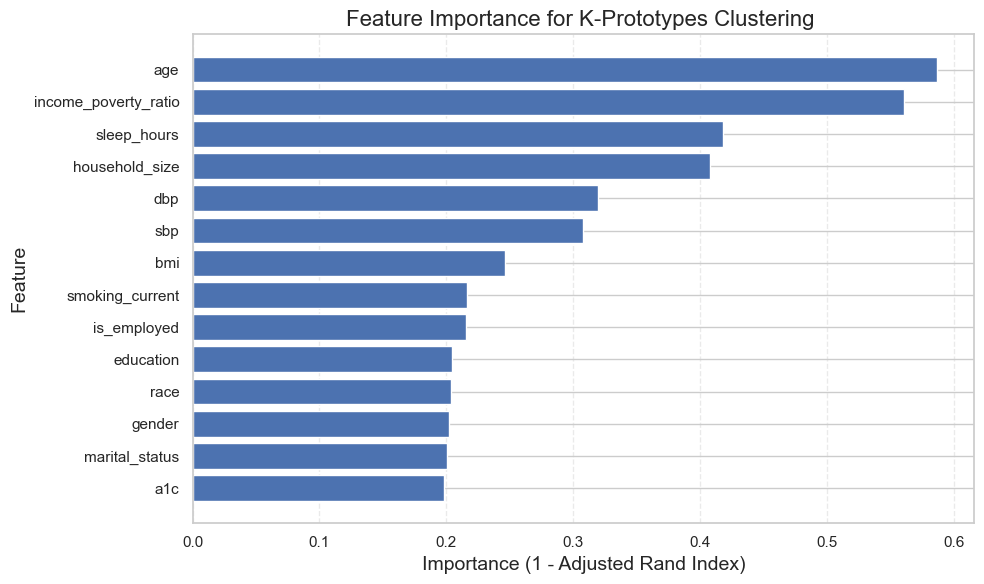

In [64]:
plt.figure(figsize=(10, 6))
plt.barh(
    importance_df.index,
    importance_df['importance'],
    color="#4C72B0"
)
plt.gca().invert_yaxis()

plt.title("Feature Importance for K-Prototypes Clustering ", 
          fontsize=16)
plt.xlabel("Importance (1 - Adjusted Rand Index)", fontsize=14)
plt.ylabel("Feature", fontsize=14)

plt.grid(axis='x', linestyle='--', alpha=0.4)
plt.tight_layout()
plt.show()

To guide our subsequent visualization and interpretation, we group the features into three importance tiers:

- **Tier 1 — Main contextual drivers**

These variables (**income-to-poverty ratio, household size, age**) define the structural axes along which clusters separate. They show the highest permutation importance and therefore represent the backbone of the cluster structure.

- **Tier 2 — Physiological risk indicators**

Variables such as **blood pressure (SBP/DBP) and BMI** capture underlying cardiometabolic health risk. Their importance is moderate: they refine cluster separation but do not dominate it.

- **Tier 3 — Behavioral & social refinements**

**Employment status, smoking, education, marital status, gender, and race** further distinguish clusters through lifestyle and demographic nuances. They show lower importance and function as secondary refinements rather than core drivers.

This section motivates the following analyses by showing that we will focus on **the most influential variables** when characterizing cluster profiles.

### 6.8.2 Contextual Drivers: Socioeconomic & Demographic Structure
This section focuses on the **structural background variables (Tier-1 importance)** that anchor the interpretation of the four clusters. These features describe fundamental demographic and socioeconomic conditions shaping each group’s health context.

We examine three core variables:

- **Income-to-poverty ratio** (primary SES indicator)

- **Household size** (family/structural context)

- **Age** (population demographic structure)

These variables provide the foundation for understanding differences in socioeconomic resources, family structure, and demographic risk across clusters.

/var/folders/f2/ms2jwb5x6ml5ggd3pv6bzx2m0000gn/T/ipykernel_1434/2754196297.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(
/var/folders/f2/ms2jwb5x6ml5ggd3pv6bzx2m0000gn/T/ipykernel_1434/2754196297.py:22: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(
/var/folders/f2/ms2jwb5x6ml5ggd3pv6bzx2m0000gn/T/ipykernel_1434/2754196297.py:33: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


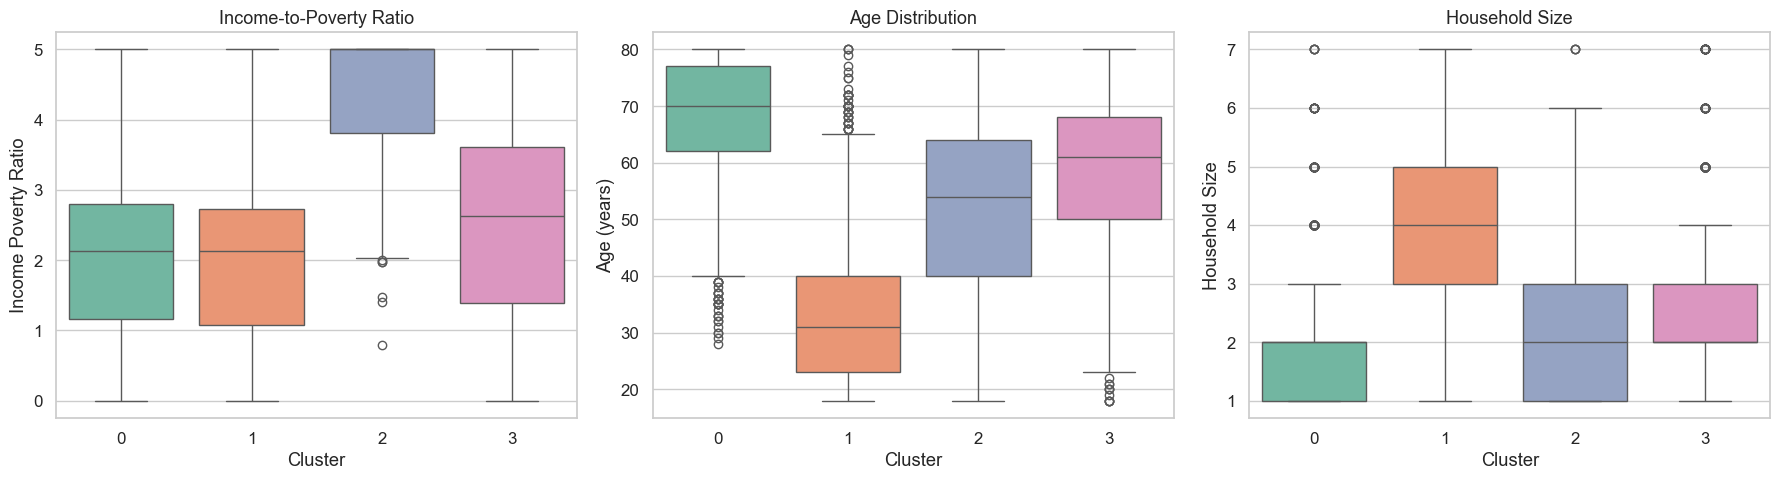

In [65]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.set(style="whitegrid", palette="Set2", font_scale=1.1)

df_plot = df_raw.copy()
df_plot["cluster"] = df_processed["cluster"]

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

sns.boxplot(
    x="cluster",
    y="income_poverty_ratio",
    data=df_plot,
    palette="Set2",
    ax=axes[0]
)
axes[0].set_title("Income-to-Poverty Ratio", fontsize=13)
axes[0].set_xlabel("Cluster")
axes[0].set_ylabel("Income Poverty Ratio")

sns.boxplot(
    x="cluster",
    y="age",
    data=df_plot,
    palette="Set2",
    ax=axes[1]
)
axes[1].set_title("Age Distribution", fontsize=13)
axes[1].set_xlabel("Cluster")
axes[1].set_ylabel("Age (years)")

sns.boxplot(
    x="cluster",
    y="household_size",
    data=df_plot,
    palette="Set2",
    ax=axes[2]
)
axes[2].set_title("Household Size", fontsize=13)
axes[2].set_xlabel("Cluster")
axes[2].set_ylabel("Household Size")

plt.tight_layout()
plt.show()

### 6.8.3 Physiological Health Risk Profile

To understand how physiological risk factors differentiate the clusters, we examine four Tier-2 variables that capture cardiometabolic health:

- **SBP (systolic blood pressure)**  
- **DBP (diastolic blood pressure)**  
- **BMI (body mass index)**  

These features show moderate importance in the permutation analysis, suggesting that physiological differences refine, but do not dominate, cluster separation.


/var/folders/f2/ms2jwb5x6ml5ggd3pv6bzx2m0000gn/T/ipykernel_1434/3722372441.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(
/var/folders/f2/ms2jwb5x6ml5ggd3pv6bzx2m0000gn/T/ipykernel_1434/3722372441.py:24: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(
/var/folders/f2/ms2jwb5x6ml5ggd3pv6bzx2m0000gn/T/ipykernel_1434/3722372441.py:37: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(


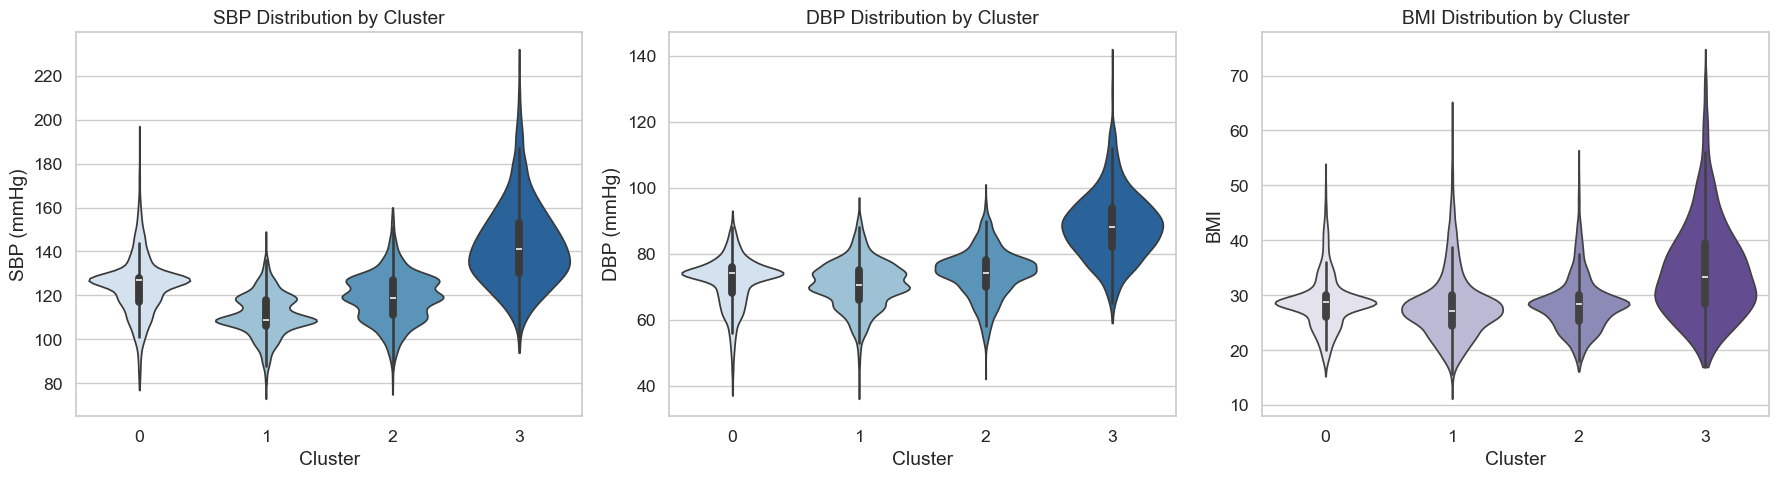

In [66]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.set(style="whitegrid", palette="Set2", font_scale=1.15)

df_plot = df_raw.copy()
df_plot["cluster"] = df_processed["cluster"]

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

sns.violinplot(
    data=df_plot,
    x="cluster",
    y="sbp",
    ax=axes[0],
    palette="Blues",
    inner="box",   
    cut=0
)
axes[0].set_title("SBP Distribution by Cluster")
axes[0].set_xlabel("Cluster")
axes[0].set_ylabel("SBP (mmHg)")

sns.violinplot(
    data=df_plot,
    x="cluster",
    y="dbp",
    ax=axes[1],
    palette="Blues",
    inner="box",
    cut=0
)
axes[1].set_title("DBP Distribution by Cluster")
axes[1].set_xlabel("Cluster")
axes[1].set_ylabel("DBP (mmHg)")

sns.violinplot(
    data=df_plot,
    x="cluster",
    y="bmi",
    ax=axes[2],
    palette="Purples",
    inner="box",
    cut=0
)
axes[2].set_title("BMI Distribution by Cluster")
axes[2].set_xlabel("Cluster")
axes[2].set_ylabel("BMI")

plt.tight_layout()
plt.show()

The physiological profiles across clusters show consistent and clinically meaningful differences:

- Cluster 3 is the only cluster with systematically elevated SBP, DBP, and BMI, indicating the highest cardiometabolic risk.

- Cluster 1 exhibits the healthiest overall profile, with the lowest blood pressure and BMI.

- Cluster 0 falls into a borderline-normal range, reflecting low-to-moderate risk.

- Cluster 2 is an intermediate and heterogeneous group, neither clearly healthy nor high-risk.

### 6.8.4 Behavioral & Social Patterns

To complement the physiological comparison in Section 8.3, this section examines
key behavioral and social-role indicators (Tier-3 variables). These variables do not
primarily determine the cluster assignments, but they provide important context on
lifestyle and social positioning, helping us understand why some clusters remain more
vulnerable despite similar physiological profiles.

**Variables Included**
- **sleep_hours** (core lifestyle behavior)
- **smoking_current** (health-risk behavior)
- **is_employed** (economic stability & social participation)
- **education** (social capital & health literacy)

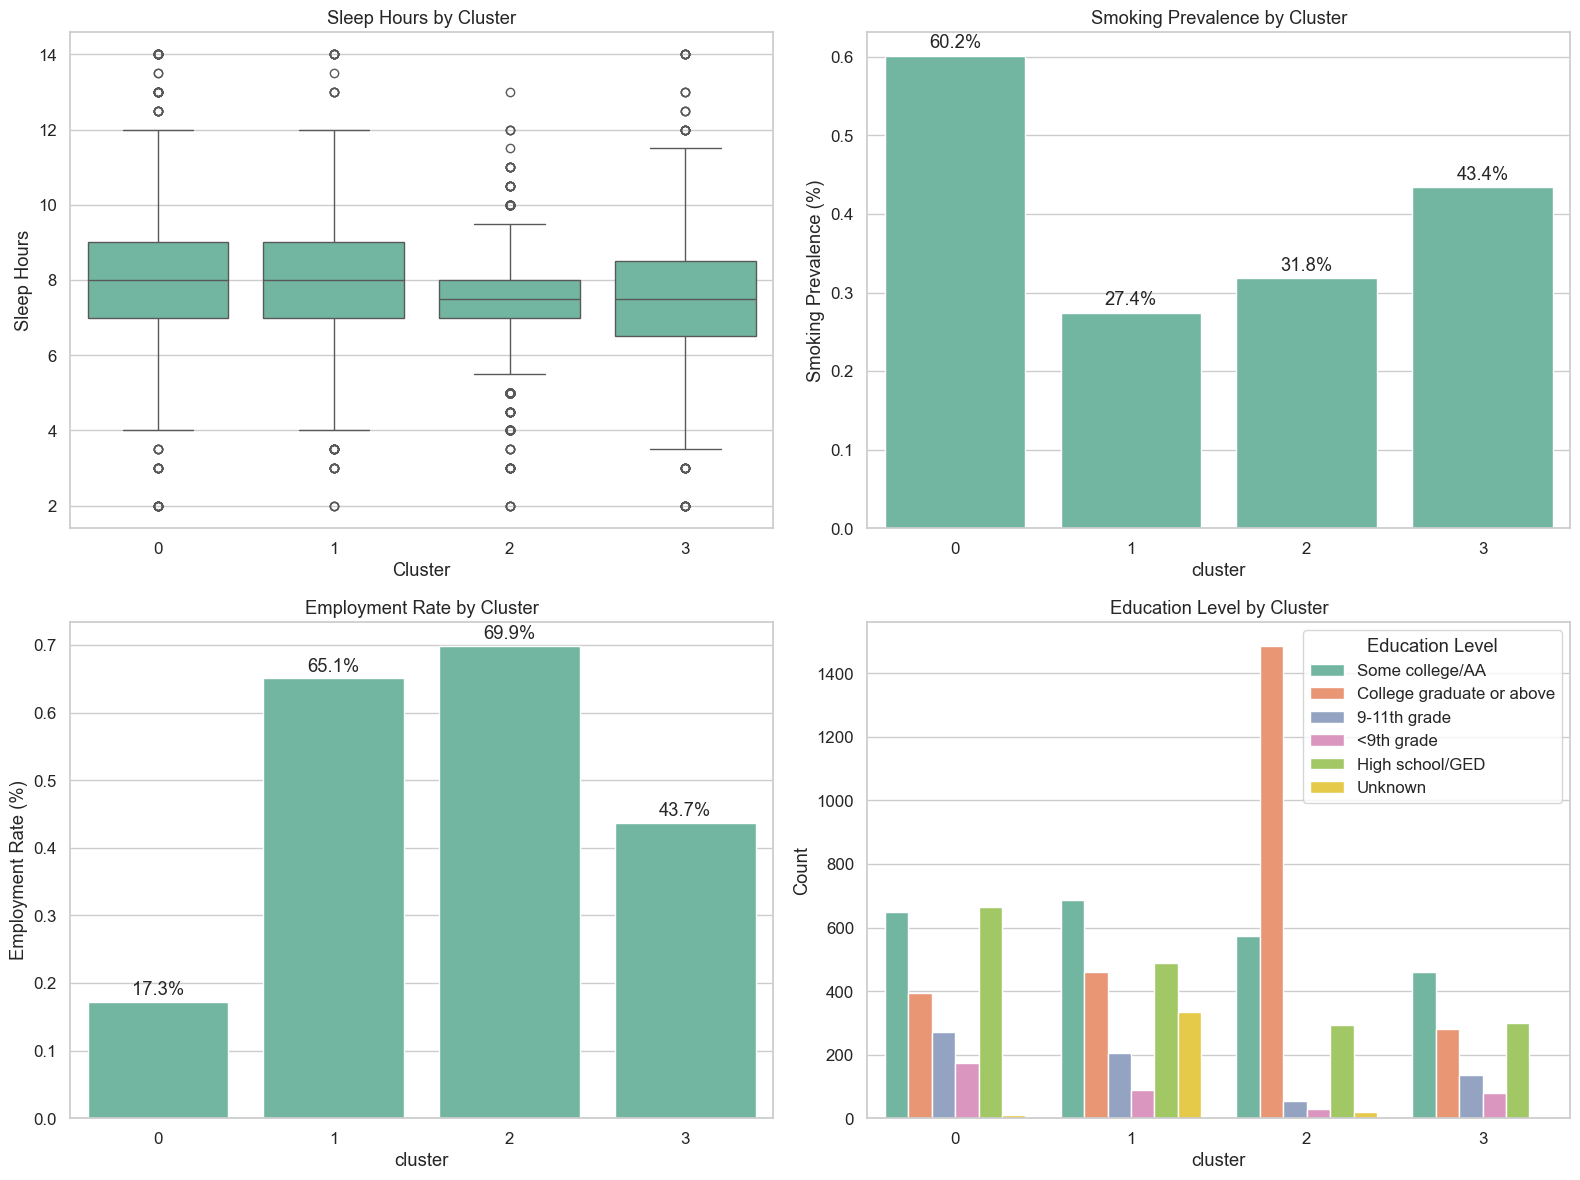

In [67]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

sns.set(style="whitegrid", palette="Set2", font_scale=1.1)

df_raw = pd.read_csv("/Users/wmhjoy/Data_Mining_Project/data/processed/nhanes_clean_adult_add.csv")

df_processed["smoking_current"] = df_raw["smoking_current"].map({"Yes": 1, "No": 0})
df_processed["is_employed"] = df_raw["is_employed"].map({"Yes": 1, "No": 0})

df_processed["sleep_hours"] = pd.to_numeric(df_raw["sleep_hours"], errors="coerce")

fig, axes = plt.subplots(2, 2, figsize=(16, 12))

sns.boxplot(
    data=df_processed,
    x="cluster",
    y="sleep_hours",
    ax=axes[0, 0]
)
axes[0, 0].set_title("Sleep Hours by Cluster")
axes[0, 0].set_xlabel("Cluster")
axes[0, 0].set_ylabel("Sleep Hours")

smoke_rate = (
    df_processed.groupby("cluster")["smoking_current"]
    .mean()
    .reset_index()
)

sns.barplot(
    data=smoke_rate,
    x="cluster",
    y="smoking_current",
    ax=axes[0, 1]
)

axes[0, 1].set_title("Smoking Prevalence by Cluster")
axes[0, 1].set_ylabel("Smoking Prevalence (%)")

for i, row in smoke_rate.iterrows():
    axes[0, 1].text(i, row["smoking_current"] + 0.01, f"{row['smoking_current']*100:.1f}%", ha="center")

employ_rate = (
    df_processed.groupby("cluster")["is_employed"]
    .mean()
    .reset_index()
)

sns.barplot(
    data=employ_rate,
    x="cluster",
    y="is_employed",
    ax=axes[1, 0]
)

axes[1, 0].set_title("Employment Rate by Cluster")
axes[1, 0].set_ylabel("Employment Rate (%)")

for i, row in employ_rate.iterrows():
    axes[1, 0].text(i, row["is_employed"] + 0.01, f"{row['is_employed']*100:.1f}%", ha="center")

sns.countplot(
    data=df_processed,
    x="cluster",
    hue="education",
    ax=axes[1, 1]
)
axes[1, 1].set_title("Education Level by Cluster")
axes[1, 1].set_ylabel("Count")
axes[1, 1].legend(title="Education Level")

plt.tight_layout()
plt.show()

### 6.8.5 Insurance Type & Hypertension Stage Distribution
Finally, because the primary goal of our project is to identify population subgroups with high hypertension risk and limited insurance coverage, we analyze each cluster’s:

- **Insurance type distribution**
- **Hypertension stages**

These outcome-focused visualizations directly support the interpretation in Section 9 and help identify vulnerable population groups who may require targeted health interventions or policy support.

In [74]:
df_processed["insurance_type"] = df_raw["insurance_type"]
insurance_type = df_processed.groupby(["cluster", "insurance_type"]).size().reset_index(name="count")
insurance_type["proportion"] = insurance_type.groupby("cluster")["count"].transform(lambda x: x / x.sum())

insurance_wide = insurance_type.pivot(index="cluster", 
                                      columns="insurance_type", 
                                      values="proportion").fillna(0)
insurance_wide

insurance_type,Both,Private only,Public only,Uninsured,Unknown
cluster,,,,,
0,0.285648,0.077527,0.572220,0.055838,0.008768
1,0.024283,0.377483,0.401325,0.162472,0.034437
2,0.155004,0.620830,0.175346,0.041904,0.006916
3,0.179731,0.293745,0.429137,0.091053,0.006334


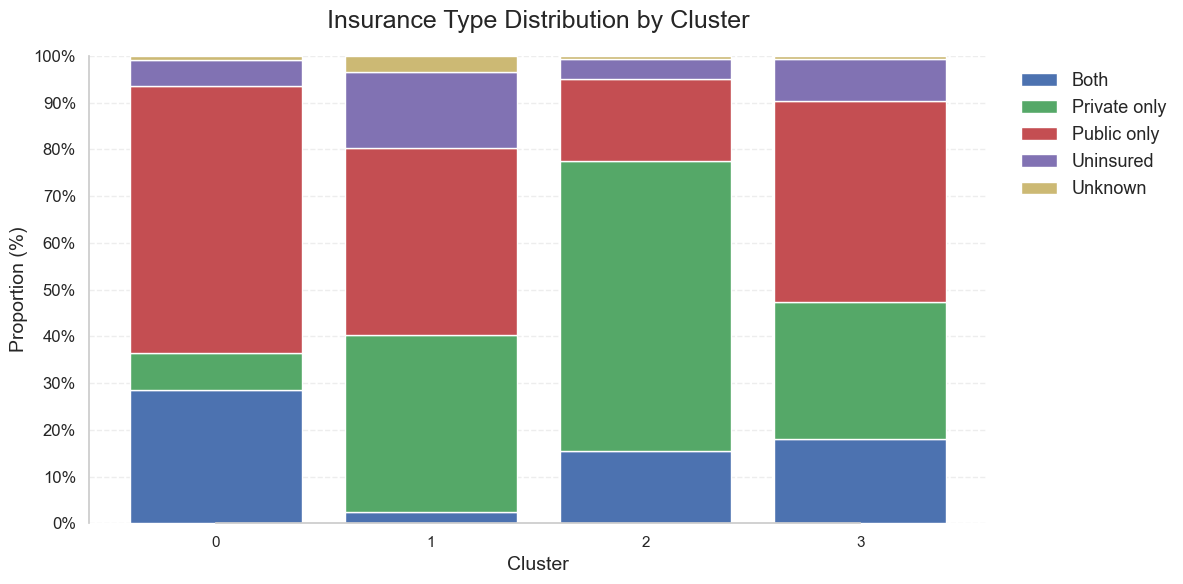

In [75]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

nature_insurance_colors = {
    "Both":         "#4C72B0",  
    "Private only": "#55A868",  
    "Public only":  "#C44E52",  
    "Uninsured":    "#8172B3",  
    "Unknown":      "#CCB974",  
}

sns.set_theme(style="whitegrid")

df_plot = insurance_wide.copy()*100
clusters = df_plot.index.astype(str)

bottom = np.zeros(len(df_plot))

fig, ax = plt.subplots(figsize=(12, 6))

for col in df_plot.columns:
    values = df_plot[col]
    ax.bar(
        clusters,
        values,
        bottom=bottom,
        label=col,
        color=nature_insurance_colors[col],
        edgecolor="white"
    )
    bottom += values

ax.set_ylabel("Proportion (%)", fontsize=14)
ax.set_xlabel("Cluster", fontsize=14)
plt.title("Insurance Type Distribution by Cluster", fontsize=18, pad=20)

ax.set_ylim(0, 100)
ax.set_yticks(np.arange(0, 101, 10))
ax.set_yticklabels([f"{i}%" for i in range(0, 101, 10)], fontsize=12)

ax.grid(True, axis='y', linestyle='--', alpha=0.35)
ax.grid(False, axis='x')

plt.legend(frameon=False, fontsize=13, bbox_to_anchor=(1.02, 1), loc="upper left")

sns.despine(trim=True)

plt.tight_layout()
plt.show()

In [76]:
def classify_hypertension_stage(row):
    sbp = row['sbp']
    dbp = row['dbp']

    if pd.isna(sbp) or pd.isna(dbp):
        return None  

    if sbp >= 140 or dbp >= 90:
        return "Stage 2"
    elif sbp >= 130 or dbp >= 80:
        return "Stage 1"
    else:
        return "Normal"

Hypertension Wide Table (%):
htn_stage     Normal    Stage 1    Stage 2
cluster                                   
0          72.219659  17.628057  10.152284
1          89.403974   9.624724   0.971302
2          74.694874  20.260374   5.044752
3           8.076010  24.623911  67.300079


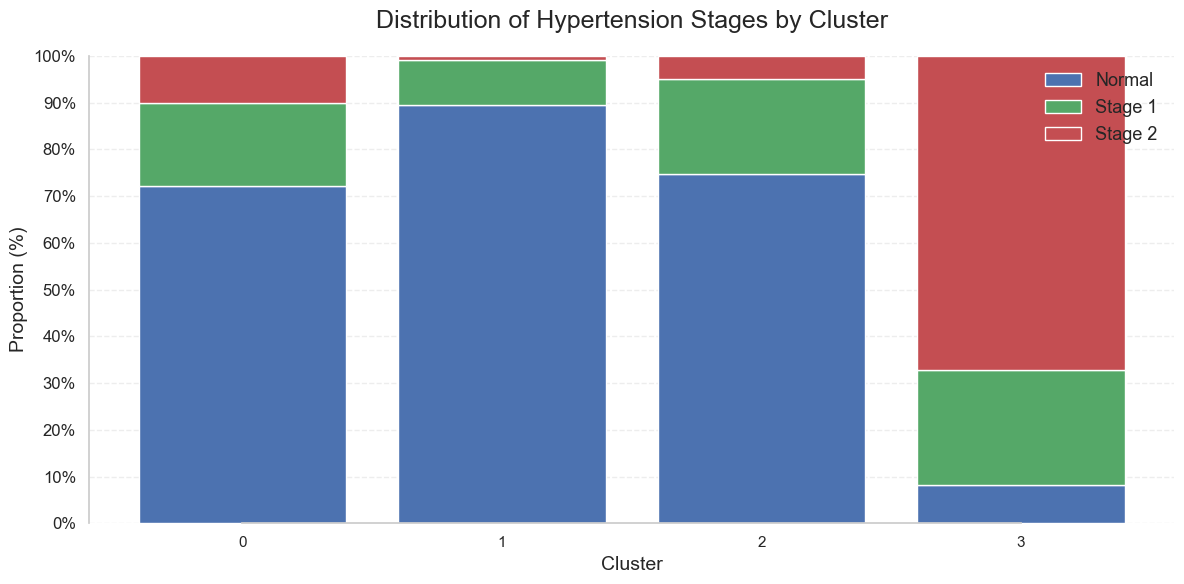

In [78]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
df_raw['htn_stage'] = df_raw.apply(classify_hypertension_stage, axis=1)

mapping = {"Normal": 0, "Stage 1": 1, "Stage 2": 2}
df_raw["htn_stage_num"] = df_raw["htn_stage"].map(mapping)
df_processed["htn_stage"] = df_raw["htn_stage"]

htn_table = (
    df_processed.groupby(["cluster", "htn_stage"])
    .size()
    .reset_index(name="count")
)

htn_table["proportion"] = (
    htn_table.groupby("cluster")["count"].transform(lambda x: x / x.sum())
)

htn_wide = htn_table.pivot(
    index="cluster",
    columns="htn_stage",
    values="proportion"
).fillna(0)

desired_cols = ["Normal", "Stage 1", "Stage 2"]
htn_wide = htn_wide.reindex(columns=desired_cols, fill_value=0)

print("Hypertension Wide Table (%):")
print(htn_wide * 100)

sns.set_theme(style="whitegrid")

fig, ax = plt.subplots(figsize=(12, 6))

clusters = htn_wide.index.astype(str)

normal_pct = htn_wide["Normal"] * 100
stage1_pct = htn_wide["Stage 1"] * 100
stage2_pct = htn_wide["Stage 2"] * 100

colors = {
    "Normal": "#4C72B0",
    "Stage 1": "#55A868",
    "Stage 2": "#C44E52",
}

ax.bar(clusters, normal_pct, color=colors["Normal"], label="Normal")
ax.bar(clusters, stage1_pct, bottom=normal_pct, color=colors["Stage 1"], label="Stage 1")
ax.bar(clusters, stage2_pct, bottom=normal_pct + stage1_pct,
       color=colors["Stage 2"], label="Stage 2")

ax.set_ylabel("Proportion (%)", fontsize=14)
ax.set_xlabel("Cluster", fontsize=14)
plt.title("Distribution of Hypertension Stages by Cluster",
          fontsize=18, pad=20)

ax.set_ylim(0, 100)
ax.set_yticks(range(0, 101, 10))
ax.set_yticklabels([f"{i}%" for i in range(0, 101, 10)], fontsize=12)

ax.grid(True, axis="y", linestyle="--", alpha=0.35)
ax.grid(False, axis="x")

plt.legend(frameon=False, fontsize=13, loc="upper right")

sns.despine(trim=True)
plt.tight_layout()
plt.show()

## 6.9 Cluster Interpretation

### 6.9.1 Cluster 0 — Low-Income Lifestyle-Risk Group: Moderate HTN, mostly public insured
**Key Evidence**

- Income-to-poverty ratio lowest → clear low-SES pattern

- Age is oldest on average (≈ 65–80 yrs)

- Smoking prevalence highest (≈ 60%)

- Employment rate lowest (≈ 17%)

- HTN distribution:
  - Normal: 72%

  - Stage 1: 18%

  - Stage 2: 10%

- Insurance mainly **public** (Medicaid/Medicare)

**Interpretation**

Cluster 0 represents an older, low-income population with high behavioral risks and moderate hypertension. Limited resources and high dependency on public insurance suggest barriers to preventive care. This group would benefit the most from community health outreach and chronic disease management support.

### 6.9.2 Cluster 1 — Young, Healthy, but Uninsured: Low-risk, mixed public/private & more uninsured
**Key Evidence**

- Youngest group (≈ 25–40 yrs)

- Highest proportion of Normal BP (≈ 89%)

- Lowest Stage 2 HTN (≈ 1%)

- Employment high (≈ 65%)

- Uninsured rate noticeably higher than other groups

- SES moderately low but stable

**Interpretation**

This is the healthiest and youngest cluster. Despite good physiological indicators and lower hypertension risk, the higher uninsured rate suggests possible gaps in preventive care access. They are low-risk now, but lack of insurance may delay early detection of future health issues.

### 6.9.3 Cluster 2 — Well-Resourced, Protected, Low-Risk Group: Mild HTN, mainly privately insured
**Key Evidence**

- Highest income-to-poverty ratio → highest SES

- Education level highest

- Employment highest (≈ 70%)

- Private insurance dominates

- HTN distribution:

  - Normal: 75%

  - Stage 1: 20%

  - Stage 2: 5%

- Low BMI  → lifestyle relatively healthy

**Interpretation**

Cluster 2 represents a stable, high-SES group with strong access to healthcare and insurance protection. Mild hypertension appears but remains manageable. High resources and consistent care access likely protect this group from progressing to more severe cardiovascular risks.

### 6.9.4 Cluster 3 — Older, High-Risk Hypertension Group: Severe HTN, mixed insurance coverage
**Key Evidence**

- Age second-highest (≈ 50–70 yrs)

- Stage 2 hypertension extremely high (≈ 67%)

- BMI highest of all clusters

- Smoking high (≈ 43%)

- Insurance type mixed (public + private + uninsured)

- Employment moderate

**Interpretation**

Cluster 3 is the most clinically concerning group. Physiological measurements show signs of advanced cardiovascular risk and high BMI, combined with inconsistent insurance coverage. This group urgently needs targeted hypertension management, lifestyle intervention, and stable healthcare access.


# 7. Conclusion
This project set out to examine how socioeconomic conditions, lifestyle behaviors, and physiological health indicators collectively shape health insurance coverage and hypertension risk in the United States. Using NHANES 2021–2023 data and a full data mining pipeline, including exploratory analysis, association rule mining, classification modeling, and clustering, we aimed to uncover interpretable patterns and derive meaningful insights relevant to public health decision-making.


## 7.1 Key Findings

Across all analytic methods, socioeconomic inequality emerged as the strongest driver of both insurance type and hypertension severity.

**Insurance-related findings**

- High-income, college-educated adults overwhelmingly hold private insurance.

- Low-income individuals—especially women—largely rely on public-only insurance.

- Older adults frequently exhibit dual coverage, driven by Medicare eligibility.

**Hypertension-related findings**

- Obesity is an early and consistent predictor of Stage 1 hypertension.

- Age is the strongest determinant of Stage 2 hypertension.

- Young adults (18–30), even when overweight, remain predominantly in Normal BP.

**Population segments (clusters) reveal structural patterns**

- Cluster 0: Low-income, older adults with high smoking and public insurance → moderate HTN risk.

- Cluster 1: Young, healthy, but uninsured → low risk today but vulnerable to future gaps in care.

- Cluster 2: High-SES, privately insured, healthiest lifestyle → mild manageable HTN.

- Cluster 3: Severe HTN + highest BMI + mixed/unstable insurance → highest clinical urgency.

These findings consistently show that HTN and healthcare access are tied to SES, lifestyle, and insurance stability.

## 7.2 Model Performance & Predictive Insights
**Insurance Classification**

- Best performance: Private-only (F1 = 0.78), driven by strong SES signals.

- Moderate: Both and Public-only (F1 ≈ 0.56–0.58), reflecting overlapping socioeconomic profiles.

- Hardest: Uninsured (F1 = 0.31–0.39), due to heterogeneity and small sample size.

- **Top predictors**: age, income–poverty ratio, education, and employment.
→ Insurance status is primarily **socioeconomic**, not physiological.

**Hypertension Classification**

- Best recall for Stage 2 (0.57), reflecting clear physiological patterns (age, BMI, SBP).

- Stage 1 hardest to predict (recall = 0.38), consistent with clinical ambiguity and overlap.

- **Top predictors**: BMI, age, smoking, A1C, sleep.
→ Hypertension is primarily **clinically-driven** rather than SES-driven.

These results confirm that insurance classification is socioeconomic, while hypertension classification is physiological—two fundamentally different mechanisms.

## 7.3 Public Health Implications
**1. Socioeconomic disadvantage shapes long-term exposure to hypertension risk**

Clusters with lower income and education did not directly determine blood pressure levels, but they consistently exhibited risk-accumulating environments, including:

- higher smoking rates,

- higher BMI,

- older age distributions,

- consequently higher hypertension stages.

These findings reflect an indirect but powerful mechanism:
SES influences lifestyle behaviors, stress exposure, and access to preventive care, which over time lead to physiological changes that the classification models identify as the strongest predictors of hypertension (e.g., BMI, age, SBP/DBP).

**Implication**:
Public health interventions targeting low-SES populations should focus on reducing long-term risk accumulation—including accessible preventive screening, smoking cessation support, nutrition and weight-management programs, and improved continuity of care.

**2. Publicly insured older adults experience unmet preventive care needs**

Clusters dominated by public insurance (Medicaid/Medicare) showed:

- older age,

- elevated BP,

- worse lifestyle risk factors.

**Implication**:
Strengthening preventive services within public insurance, regular BP monitoring, lifestyle counseling, and chronic disease follow-up, is essential.

**3. Young uninsured adults are healthy now but at long-term risk**

Despite being the healthiest group, the young uninsured cluster showed the highest uninsured rate, which may delay early detection of hypertension.

**Implication**:
Young adults need low-cost insurance options, targeted preventive outreach, and education to avoid future, undiagnosed hypertension progression.

**4. Severe hypertension in older high-BMI individuals with mixed insurance suggests fragmented care**

The most clinically concerning cluster (older, severe HTN, highest BMI, mixed coverage) indicates:

- unstable access to care,

- inconsistent follow-up,

- higher chronic disease burden.

**Implication**:
This group needs integrated care, stable insurance continuity, weight management programs, and aggressive hypertension control.

## 7.4 Limitations
Several limitations should be acknowledged.
NHANES is cross-sectional, limiting the ability to infer causal relationships between SES, insurance, and hypertension. Some lifestyle variables are self-reported and subject to measurement error. Insurance categories are imbalanced, and important behavioral determinants (diet quality, stress, physical activity intensity) are not fully captured in the available dataset. Clustering results may also be sensitive to initialization and variable scaling.

## 7.5 Future Directions

Future extensions of this project may pursue several directions to strengthen analytical depth and policy relevance.

### 7.5.1 Linking NHANES With External Cost Data

A key next step is to integrate NHANES with external datasets containing medical expenditure or insurance cost information (e.g., MEPS).
Because NHANES is anonymized and lacks person-level identifiers, direct merging is infeasible.
Future work can apply **probabilistic or synthetic matching** to align individuals based on shared demographic and health attributes.
This would allow analyses to move from identifying **who is at risk** to estimating **how costly those risks are** for the healthcare system.

### 7.5.2 Incorporating Nutrition Data via Representation Learning

NHANES nutrition records exist in long format and cannot be directly joined as tabular variables.
Representation learning approaches, such as **dietary embeddings** constructed using lightweight transformer or embedding models, could summarize individuals' dietary patterns into compact vectors.
Integrating these embeddings may substantially enhance predictive accuracy and enable richer analysis of lifestyle–health interactions.

### 7.5.3 Longitudinal and Causal Modeling of Risk Trajectories

Future work could incorporate longitudinal or multi-wave datasets to examine how insurance stability, socioeconomic changes, and lifestyle patterns influence **hypertension development over time**. Methods such as **causal inference, trajectory modeling, or cluster-specific intervention simulations** could provide more robust insight into the long-term effects of insurance continuity and preventive care access.

Overall, this project demonstrates the value of combining socioeconomic, lifestyle, and physiological data to uncover patterns of cardiovascular risk and insurance inequality. Through a multi-method data mining approach, we highlight critical population segments that would benefit from tailored preventive care, improved insurance continuity, and targeted hypertension management. These findings contribute to a broader understanding of how structural factors shape health outcomes and offer actionable insights for public health planning.